# NewsAPI vs Factiva

This Jupyter Notebook compares query results for Mashreq countries of NewsAPI (https://newsapi.ai/) and Factiva. 


Author: Dominik Wielath (dominik.wielath@gmail.com)

DIME Artificial Intelligence (DIME AI) - World Bank Group

Date: 2024-07-10

In [2]:
import os
import re

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.dates as mdates

import geopandas as gpd

from eventregistry import *
from datetime import datetime

from utilities import *

In [3]:
# Specify the list of regions
#mashreq_countries = ["Bahrain", "Egypt", "Iraq", "Israel", "Jordan", "Kuwait", "Lebanon", "Libya", "Oman", "Qatar", "Saudi Arabia", "Sudan", "Palestine", "Syria", "United Arab Emirates", "Yemen"]
mashreq_countries = ["Iraq", "Jordan", "Lebanon", "Palestine", "Syria"]

In [4]:
# Specify required data paths
data_path = "../../data/"
data_path_newsapi = "../../data/newsapi/"
data_path_newsapi_sources = "../../data/newsapi/sources/"
data_path_newsapi_articles = "../../data/newsapi/articles/"
data_path_newsapi_daily = "../../data/newsapi/articles-daily/"

data_path_ratings = "../../data/news-ratings/"

data_path_factiva = "../../data/factiva/"
data_path_factiva_sources = "../../data/factiva/sources-metadata/"
data_path_factiva_sources_raw = "../../data/factiva/sources-metadata/raw/"
data_path_factiva_sources_clean = "../../data/factiva/sources-metadata/clean/"
data_path_factiva_headlines = "../../data/factiva/headlines/"

plot_path = "../../plots/"
shapefiles_path = "../../data/shapefiles/"


In [5]:
# Set start and end dates
start_date_string = "06/16/2024"
end_date_string = "06/30/2024"

date_format = "%m/%d/%Y"
start_date = datetime.strptime(start_date_string, date_format)
end_date = datetime.strptime(end_date_string, date_format)

# Create date format for queries as required by News API
query_date_format = "%Y-%m-%d"
start_date_query_format = start_date.strftime(query_date_format)
end_date_query_format = end_date.strftime(query_date_format)

# Create date format for filenames
filename_date_format = "%m%d%Y"
start_date_filename_format = start_date.strftime(filename_date_format)
end_date_filename_format = end_date.strftime(filename_date_format)

In [6]:
# Set language for articles in query
language = "eng"
#language = "ara"

In [7]:
# Setting the API key for Event Registry
News_API_key_dominik = '7ce3fa46-3bab-4460-a552-e3046d565492'
News_API_key_philipp = '9200e557-062b-411a-8b58-0592c0fac183'
News_API_key_dominik_wb = '34b2eba6-04d7-4ad0-9aad-06a4bb50fae6'
News_API_key = News_API_key_dominik_wb

er = EventRegistry(apiKey = News_API_key)

Adding admin level 0

In [7]:
# Creating the dataframe with the concept and location URIs
mashreq_countries_df = pd.DataFrame(mashreq_countries, columns = ["country"])
mashreq_countries_df["uri"] = [er.getLocationUri(country) for country in mashreq_countries_df["country"].values]

mashreq_countries_df.loc[mashreq_countries_df["country"] == "Palestine", "uri"] = "https://en.wikipedia.org/wiki/State_of_Palestine"

mashreq_countries_df["location_name_ara"] = ""
mashreq_countries_df.loc[mashreq_countries_df["country"] == "Iraq","location_name_ara"] = "العراق"
mashreq_countries_df.loc[mashreq_countries_df["country"] == "Jordan","location_name_ara"] = "الأردن"
mashreq_countries_df.loc[mashreq_countries_df["country"] == "Lebanon","location_name_ara"] = "لبنان"
mashreq_countries_df.loc[mashreq_countries_df["country"] == "Palestine","location_name_ara"] = "فلسطين"
mashreq_countries_df.loc[mashreq_countries_df["country"] == "Syria","location_name_ara"] = "سوريا"

mashreq_countries_df.rename(columns = {"country": "location_name"}, inplace = True)
mashreq_countries_df["country"] = mashreq_countries_df["location_name"]
mashreq_countries_df["adm"] = 0

In [8]:
palestine_df = mashreq_countries_df.iloc[[3]].copy().reset_index(drop = True)
palestine_df = pd.concat([palestine_df, palestine_df, palestine_df, palestine_df, palestine_df]).reset_index(drop = True)

palestine_df.loc[palestine_df.index == 1, "uri"] = "https://en.wikipedia.org/wiki/Palestine"
palestine_df.loc[palestine_df.index == 2, "uri"] = "https://en.wikipedia.org/wiki/Palestine_(region)"
palestine_df.loc[palestine_df.index == 3, "uri"] = "https://en.wikipedia.org/wiki/Palestinian_territories"
palestine_df.loc[palestine_df.index == 4, "uri"] = "https://en.wikipedia.org/wiki/Palestinian_Authority"

In [9]:
mashreq_countries_df = mashreq_countries_df.loc[mashreq_countries_df["location_name"] != "Palestine"].reset_index(drop = True)
mashreq_countries_df = pd.concat([mashreq_countries_df, palestine_df]).reset_index(drop = True)

Adding admin level 1

In [32]:
iraq_districts_shp_name = shapefiles_path + "administrative-boundaries/iraq/irq_admbnda_adm2_cso_20190603.shp"
jordan_districts_shp_name = shapefiles_path + "administrative-boundaries/jordan/jordan_clean.shp"
lebanon_districts_shp_name = shapefiles_path + "administrative-boundaries/lebanon/lbn_admbnda_adm2_cdr_20200810.shp"
palestine_districts_shp_name = shapefiles_path + "administrative-boundaries/palestine/palestine_clean.shp"
syria_districts_shp_name = shapefiles_path + "administrative-boundaries/syria/syr_admin2.shp"

In [33]:
iraq_districts_shp = gpd.read_file(iraq_districts_shp_name)
jordan_districts_shp = gpd.read_file(jordan_districts_shp_name)
lebanon_districts_shp = gpd.read_file(lebanon_districts_shp_name)
palestine_districts_shp = gpd.read_file(palestine_districts_shp_name)
syria_districts_shp = gpd.read_file(syria_districts_shp_name)

In [12]:
# English location names
iraq_provinces_shp_names = iraq_districts_shp[["ADM1_EN_cl", "ADM1_AR"]].drop_duplicates().reset_index(drop=True)
lebanon_provinces_shp_names = lebanon_districts_shp[["admin1Na_1", "ADM1_EN_cl"]].drop_duplicates().reset_index(drop=True)
syria_provinces_shp_names = syria_districts_shp[["ADM1_AR", "ADM1_EN_cl"]].drop_duplicates().reset_index(drop=True)
jordan_provinces = ["irbid", "ajloun", "jerash", "mafraq", "balqa", "amman", "zarqa", "madaba", "karak", "tafilah", "ma'an", "aqaba"]
jordan_provinces_ara = ["إربد", "عجلون", "جرش", "المفرق", "البلقاء", "عمان", "الزرقاء", "مادبا", "الكرك", "الطفيلة", "معان", "العقبة"]
palestine_provinces = palestine_districts_shp["ADM1_EN_cl"].unique()

In [13]:
# Iraq
iraq_provinces_df = pd.DataFrame(data={"location_name": iraq_provinces_shp_names["ADM1_EN_cl"].values, "uri" : [er.getLocationUri(country) for country in iraq_provinces_shp_names["ADM1_EN_cl"].values],"location_name_ara":iraq_provinces_shp_names["ADM1_AR"].values, "adm" : 1, "country":"Iraq"})

iraq_provinces_df.loc[iraq_provinces_df["location_name"] == "baghdad", "uri"] = "https://en.wikipedia.org/wiki/Baghdad_Governorate"
iraq_provinces_df.loc[iraq_provinces_df["location_name"] == "basra", "uri"] = "https://en.wikipedia.org/wiki/Basra_Governorate"
iraq_provinces_df.loc[iraq_provinces_df["location_name"] == "duhok", "uri"] = "https://en.wikipedia.org/wiki/Duhok_Governorate"
iraq_provinces_df.loc[iraq_provinces_df["location_name"] == "kerbala", "uri"] = "https://en.wikipedia.org/wiki/Karbala_Governorate"
iraq_provinces_df.loc[iraq_provinces_df["location_name"] == "ninewa", "uri"] = "https://en.wikipedia.org/wiki/Nineveh_Governorate"
iraq_provinces_df.loc[iraq_provinces_df["location_name"] == "qadissiya", "uri"] = "https://en.wikipedia.org/wiki/Al-Q%C4%81disiyyah_Governorate"
iraq_provinces_df.loc[iraq_provinces_df["location_name"] == "salah al-din", "uri"] = "https://en.wikipedia.org/wiki/Saladin_Governorate"
iraq_provinces_df.loc[iraq_provinces_df["location_name"] == "thi qar", "uri"] = "https://en.wikipedia.org/wiki/Dhi_Qar_Governorate"
iraq_provinces_df.loc[iraq_provinces_df["location_name"] == "wassit", "uri"] = "https://en.wikipedia.org/wiki/Wasit_Governorate"

In [ ]:
# Jordan
jordan_provinces_df = pd.DataFrame(data={"location_name": jordan_provinces, "uri" : [er.getLocationUri(country) for country in jordan_provinces],"location_name_ara":jordan_provinces_ara, "adm" : 1, "country":"Jordan"})

jordan_provinces_df.loc[jordan_provinces_df["location_name"] == "ajloun", "uri"] = "https://en.wikipedia.org/wiki/Ajloun_Governorate"
jordan_provinces_df.loc[jordan_provinces_df["location_name"] == "jerash", "uri"] = "https://en.wikipedia.org/wiki/Jerash_Governorate"
jordan_provinces_df.loc[jordan_provinces_df["location_name"] == "karak", "uri"] = "https://en.wikipedia.org/wiki/Karak_Governorate"

In [14]:
# Lebanon
lebanon_provinces_df = pd.DataFrame(data={"location_name": lebanon_provinces_shp_names["ADM1_EN_cl"].values, "uri" : [er.getLocationUri(country) for country in lebanon_provinces_shp_names["ADM1_EN_cl"].values],"location_name_ara":lebanon_provinces_shp_names["admin1Na_1"].values, "adm" : 1, "country":"Lebanon"})

lebanon_provinces_df.loc[lebanon_provinces_df["location_name"] == "akkar", "uri"] = "https://en.wikipedia.org/wiki/Akkar_Governorate"
lebanon_provinces_df.loc[lebanon_provinces_df["location_name"] == "baalbek-hermel", "uri"] = "https://en.wikipedia.org/wiki/Baalbek-Hermel_Governorate"
lebanon_provinces_df.loc[lebanon_provinces_df["location_name"] == "beirut", "uri"] = "https://en.wikipedia.org/wiki/Beirut_Governorate"
lebanon_provinces_df.loc[lebanon_provinces_df["location_name"] == "bekaa", "uri"] = "https://en.wikipedia.org/wiki/Beqaa_Governorate"
lebanon_provinces_df.loc[lebanon_provinces_df["location_name"] == "nabatieh", "uri"] = "https://en.wikipedia.org/wiki/Nabatieh_Governorate"
lebanon_provinces_df.loc[lebanon_provinces_df["location_name"] == "north lebanon", "uri"] = "https://en.wikipedia.org/wiki/North_Governorate"
lebanon_provinces_df.loc[lebanon_provinces_df["location_name"] == "south lebanon", "uri"] = "https://en.wikipedia.org/wiki/South_Governorate"

In [ ]:
# Palestine
palestine_provinces_df = pd.DataFrame(data={"location_name": palestine_provinces, "uri" : [er.getLocationUri(country) for country in palestine_provinces],"location_name_ara":["الضفة الغربية", "غزة"], "adm" : 1, "country":"Palestine"})

palestine_provinces_df.loc[palestine_provinces_df["location_name"] == "gaza strip", "location_name"] = "gaza"
gaza_df = palestine_provinces_df.loc[palestine_provinces_df["location_name"] == "gaza", ]
gaza_df = pd.concat([gaza_df, gaza_df, gaza_df], ignore_index=True)

gaza_df.loc[gaza_df.index == 0, "uri"] = "https://en.wikipedia.org/wiki/Gaza"
gaza_df.loc[gaza_df.index == 1, "uri"] = "http://en.wikipedia.org/wiki/Gaza_Governorate"
gaza_df.loc[gaza_df.index == 2, "uri"] = "https://en.wikipedia.org/wiki/Gaza_City"

palestine_provinces_df = pd.concat([palestine_provinces_df, gaza_df]).reset_index(drop=True)  

In [15]:
# Syria
syria_provinces_df = pd.DataFrame(data={"location_name": syria_provinces_shp_names["ADM1_EN_cl"].values, "uri" : [er.getLocationUri(country) for country in syria_provinces_shp_names["ADM1_EN_cl"].values],"location_name_ara":syria_provinces_shp_names["ADM1_AR"].values, "adm" : 1, "country":"Syria"})

syria_provinces_df.loc[syria_provinces_df["location_name"] == "hama", "uri"] = "https://en.wikipedia.org/wiki/Hama_Governorate"
syria_provinces_df.loc[syria_provinces_df["location_name"] == "hasakeh", "uri"] = "https://en.wikipedia.org/wiki/Al-Hasakah_Governorate"
syria_provinces_df.loc[syria_provinces_df["location_name"] == "idleb", "uri"] = "https://en.wikipedia.org/wiki/Idlib_Governorate"
syria_provinces_df.loc[syria_provinces_df["location_name"] == "lattakia", "uri"] = "https://en.wikipedia.org/wiki/Latakia_Governorate"
syria_provinces_df.loc[syria_provinces_df["location_name"] == "rural damascus", "uri"] = "https://en.wikipedia.org/wiki/Rif_Dimashq_Governorate"
syria_provinces_df.loc[syria_provinces_df["location_name"] == "sweida", "uri"] = "https://en.wikipedia.org/wiki/As-Suwayda_Governorate"
syria_provinces_df.loc[syria_provinces_df["location_name"] == "tartous", "uri"] = "https://en.wikipedia.org/wiki/Tartus_Governorate"

In [18]:
mashreq_countries_df = pd.concat([mashreq_countries_df, iraq_provinces_df, lebanon_provinces_df, syria_provinces_df, palestine_provinces_df, jordan_provinces_df]).reset_index(drop=True)

In [215]:
mashreq_countries_df.to_csv(data_path_newsapi + "mashreq_countries_adm0_adm1.csv", index = False)

Adding admin level 2

In [88]:
# Iraq
iraq_district_df = pd.DataFrame(data={"location_name": iraq_districts_shp["ADM2_EN_cl"].values, "uri" : [er.getLocationUri(country) for country in iraq_districts_shp["ADM2_EN_cl"].values], "location_name_ara" : iraq_districts_shp["ADM2_AR"].values, "adm" : 2, "country":"Iraq"})

iraq_district_df.loc[iraq_district_df["location_name"] == 'abu al-khaseeb', "uri"] = 'http://en.wikipedia.org/wiki/Abu_Al-Khaseeb_District'
iraq_district_df.loc[iraq_district_df["location_name"] == 'afaq', "uri"] = 'http://en.wikipedia.org/wiki/Afaq_District'
iraq_district_df.loc[iraq_district_df["location_name"] == 'ain al-tamur', "uri"] = 'http://en.wikipedia.org/wiki/Ain_Al-Tamur_District'
iraq_district_df.loc[iraq_district_df["location_name"] == 'adhamiya', "uri"] = 'http://en.wikipedia.org/wiki/Adhamiyah'
iraq_district_df.loc[iraq_district_df["location_name"] == 'amadiya', "uri"] = 'https://en.wikipedia.org/wiki/Amedi_District'
iraq_district_df.loc[iraq_district_df["location_name"] == 'amara', "uri"] = 'https://en.wikipedia.org/wiki/Amara_District'
iraq_district_df.loc[iraq_district_df["location_name"] == 'baaj', "uri"] = 'https://en.wikipedia.org/wiki/Al-Ba%27aj_District'
iraq_district_df.loc[iraq_district_df["location_name"] == 'basrah', "uri"] = 'http://en.wikipedia.org/wiki/Basrah_District'
iraq_district_df.loc[iraq_district_df["location_name"] == 'chibayish', "uri"] = 'http://en.wikipedia.org/wiki/Al-Chibayish_District'
iraq_district_df.loc[iraq_district_df["location_name"] == 'daur', "uri"] =  'https://en.wikipedia.org/wiki/Al-Daur_District'
iraq_district_df.loc[iraq_district_df["location_name"] == 'diwaniya', "uri"] = 'https://en.wikipedia.org/wiki/Diwaniya_District'
iraq_district_df.loc[iraq_district_df["location_name"] == 'falluja', "uri"] = 'https://en.wikipedia.org/wiki/Fallujah_District'
iraq_district_df.loc[iraq_district_df["location_name"] == 'faw', "uri"] = 'https://en.wikipedia.org/wiki/Al-Faw_District,_Basra_Governorate'
iraq_district_df.loc[iraq_district_df["location_name"] == 'hai', "uri"] = 'https://en.wikipedia.org/wiki/Al-Hai_District'
iraq_district_df.loc[iraq_district_df["location_name"] == 'hamdaniya', "uri"] = 'http://en.wikipedia.org/wiki/Al-Hamdaniya_District'
iraq_district_df.loc[iraq_district_df["location_name"] == 'hamza', "uri"] = 'http://en.wikipedia.org/wiki/Hamza_District'
iraq_district_df.loc[iraq_district_df["location_name"] == 'hashimiya', "uri"] = 'http://en.wikipedia.org/wiki/Hashimiya_District'
iraq_district_df.loc[iraq_district_df["location_name"] == 'hatra', "uri"] = 'https://en.wikipedia.org/wiki/Hatra_District'
iraq_district_df.loc[iraq_district_df["location_name"] == 'hawiga', "uri"] = 'http://en.wikipedia.org/wiki/Al-Hawiga_District'
iraq_district_df.loc[iraq_district_df["location_name"] == 'hilla', "uri"] = 'https://en.wikipedia.org/wiki/Al-Hilla_District'
iraq_district_df.loc[iraq_district_df["location_name"] == 'hindiya', "uri"] = 'https://en.wikipedia.org/wiki/Al-Hindiya_District'
iraq_district_df.loc[iraq_district_df["location_name"] == 'kadhmiyah', "uri"] = 'https://en.wikipedia.org/wiki/Kadhimiya'
iraq_district_df.loc[iraq_district_df["location_name"] == 'kahla', "uri"] = 'https://en.wikipedia.org/wiki/Al-Kahla_District'
iraq_district_df.loc[iraq_district_df["location_name"] == 'kaim', "uri"] = ''
iraq_district_df.loc[iraq_district_df["location_name"] == 'karkh', "uri"] = 'https://en.wikipedia.org/wiki/Karkh'
iraq_district_df.loc[iraq_district_df["location_name"] == 'khalis', "uri"] = 'https://en.wikipedia.org/wiki/Al_Khalis_District'
iraq_district_df.loc[iraq_district_df["location_name"] == 'khidhir', "uri"] = 'https://en.wikipedia.org/wiki/Al-Khidhir_District'
iraq_district_df.loc[iraq_district_df["location_name"] == 'kufa', "uri"] = 'http://en.wikipedia.org/wiki/Kufa_District'
iraq_district_df.loc[iraq_district_df["location_name"] == 'kut', "uri"] = 'https://en.wikipedia.org/wiki/Kut_District'
iraq_district_df.loc[iraq_district_df["location_name"] == "mada'in", "uri"] = 'https://en.wikipedia.org/wiki/Al-Mada%27in_District'
iraq_district_df.loc[iraq_district_df["location_name"] == 'mahaweel', "uri"] = 'https://en.wikipedia.org/wiki/Al-Mahawil_District'
iraq_district_df.loc[iraq_district_df["location_name"] == 'mahmoudiya', "uri"] = 'https://en.wikipedia.org/wiki/Mahmudiya_District'
iraq_district_df.loc[iraq_district_df["location_name"] == 'maimouna', "uri"] = 'https://en.wikipedia.org/wiki/Al-Maimouna_District'
iraq_district_df.loc[iraq_district_df["location_name"] == 'manathera', "uri"] = 'https://en.wikipedia.org/wiki/Al-Manathera_District'
iraq_district_df.loc[iraq_district_df["location_name"] == 'mejar al-kabir', "uri"] = 'https://en.wikipedia.org/wiki/Al-Mejar_Al-Kabir_District'
iraq_district_df.loc[iraq_district_df["location_name"] == 'midaina', "uri"] = 'https://en.wikipedia.org/wiki/Al-Midaina_District'
iraq_district_df.loc[iraq_district_df["location_name"] == 'mosul', "uri"] = 'https://en.wikipedia.org/wiki/Mosul_District'
iraq_district_df.loc[iraq_district_df["location_name"] == 'muqdadiya', "uri"] = 'https://en.wikipedia.org/wiki/Al-Miqdadiya_District'
iraq_district_df.loc[iraq_district_df["location_name"] == 'mussyab', "uri"] = 'https://en.wikipedia.org/wiki/Al-Musayab_District'
iraq_district_df.loc[iraq_district_df["location_name"] == 'najaf', "uri"] = 'https://en.wikipedia.org/wiki/Najaf_District'
iraq_district_df.loc[iraq_district_df["location_name"] == 'namaniya', "uri"] = 'https://en.wikipedia.org/wiki/Al-Nu%27maniya_District'
iraq_district_df.loc[iraq_district_df["location_name"] == 'nasiriya', "uri"] = 'https://en.wikipedia.org/wiki/Nasiriyah_District'
iraq_district_df.loc[iraq_district_df["location_name"] == 'qurna', "uri"] = 'https://en.wikipedia.org/wiki/Al-Qurna_District'
iraq_district_df.loc[iraq_district_df["location_name"] == 'ramadi', "uri"] = 'https://en.wikipedia.org/wiki/Ramadi_District'
iraq_district_df.loc[iraq_district_df["location_name"] == 'rifai', "uri"] = 'https://en.wikipedia.org/wiki/Al-Rifa%27i_District'
iraq_district_df.loc[iraq_district_df["location_name"] == 'risafa', "uri"] = 'https://en.wikipedia.org/wiki/Al-Rusafa,_Iraq'
iraq_district_df.loc[iraq_district_df["location_name"] == 'rumaitha', "uri"] = 'http://en.wikipedia.org/wiki/Al-Rumaitha_District'
iraq_district_df.loc[iraq_district_df["location_name"] == 'rutba', "uri"] = 'https://en.wikipedia.org/wiki/Ar-Rutba_District'
iraq_district_df.loc[iraq_district_df["location_name"] == 'salman', "uri"] = 'https://en.wikipedia.org/wiki/Al-Salman_District'
iraq_district_df.loc[iraq_district_df["location_name"] == 'samawa', "uri"] = 'https://en.wikipedia.org/wiki/As-Samawah_District'
iraq_district_df.loc[iraq_district_df["location_name"] == 'shamiya', "uri"] = 'https://en.wikipedia.org/wiki/Al-Shamiya_District'
iraq_district_df.loc[iraq_district_df["location_name"] == 'shatra', "uri"] = 'https://en.wikipedia.org/wiki/Al-Shatrah_District'
iraq_district_df.loc[iraq_district_df["location_name"] == 'shikhan', "uri"] = 'https://en.wikipedia.org/wiki/Shekhan_District'
iraq_district_df.loc[iraq_district_df["location_name"] == 'shirqat', "uri"] = 'https://en.wikipedia.org/wiki/Al-Shirqat_District'
iraq_district_df.loc[iraq_district_df["location_name"] == 'sulaymaniyah', "uri"] = 'https://en.wikipedia.org/wiki/Sulaymaniyah_District'
iraq_district_df.loc[iraq_district_df["location_name"] == 'suwaira', "uri"] = 'https://en.wikipedia.org/wiki/Al-Suwaira_District'
iraq_district_df.loc[iraq_district_df["location_name"] == 'thawra', "uri"] = 'https://en.wikipedia.org/wiki/Sadr_City'
iraq_district_df.loc[iraq_district_df["location_name"] == 'zibar', "uri"] = ''
iraq_district_df.loc[iraq_district_df["location_name"] == 'zubair', "uri"] = 'https://en.wikipedia.org/wiki/Al-Zubair_District'
iraq_district_df.loc[iraq_district_df["location_name"] == 'ali al-gharbi', "uri"] = 'https://en.wikipedia.org/wiki/Ali_Al-Gharbi_District'
iraq_district_df.loc[iraq_district_df["location_name"] == 'ana', "uri"] = 'https://en.wikipedia.org/wiki/Anah_District'
iraq_district_df.loc[iraq_district_df["location_name"] == 'aqra', "uri"] = ''
iraq_district_df.loc[iraq_district_df["location_name"] == 'badra', "uri"] = 'https://en.wikipedia.org/wiki/Badra_District'
iraq_district_df.loc[iraq_district_df["location_name"] == 'balad', "uri"] = 'https://en.wikipedia.org/wiki/Balad_District,_Iraq'
iraq_district_df.loc[iraq_district_df["location_name"] == 'baladruz', "uri"] = 'https://en.wikipedia.org/wiki/Balad_Ruz_District'
iraq_district_df.loc[iraq_district_df["location_name"] == 'baquba', "uri"] = 'https://en.wikipedia.org/wiki/Ba%27quba_District'
iraq_district_df.loc[iraq_district_df["location_name"] == 'beygee', "uri"] = ''
iraq_district_df.loc[iraq_district_df["location_name"] == 'chamchamal', "uri"] = 'https://en.wikipedia.org/wiki/Chamchamal_District'
iraq_district_df.loc[iraq_district_df["location_name"] == 'daquq', "uri"] = 'https://en.wikipedia.org/wiki/Daquq_District'
iraq_district_df.loc[iraq_district_df["location_name"] == 'derbendikhan', "uri"] = 'https://en.wikipedia.org/wiki/Darbandikhan_District'
iraq_district_df.loc[iraq_district_df["location_name"] == 'dibis', "uri"] = 'https://en.wikipedia.org/wiki/Dibis_District'
iraq_district_df.loc[iraq_district_df["location_name"] == 'dokan', "uri"] = 'https://en.wikipedia.org/wiki/Dokan_District'
iraq_district_df.loc[iraq_district_df["location_name"] == 'duhok', "uri"] = ''
iraq_district_df.loc[iraq_district_df["location_name"] == 'erbil', "uri"] = 'https://en.wikipedia.org/wiki/Erbil_District'
iraq_district_df.loc[iraq_district_df["location_name"] == 'haditha', "uri"] = 'https://en.wikipedia.org/wiki/Haditha_District'
iraq_district_df.loc[iraq_district_df["location_name"] == 'halabcha', "uri"] = 'https://en.wikipedia.org/wiki/Halabja'
iraq_district_df.loc[iraq_district_df["location_name"] == 'heet', "uri"] = 'https://en.wikipedia.org/wiki/Hit_District'
iraq_district_df.loc[iraq_district_df["location_name"] == 'kalar', "uri"] = 'https://en.wikipedia.org/wiki/Kalar_District'
iraq_district_df.loc[iraq_district_df["location_name"] == 'kerbela', "uri"] = 'https://en.wikipedia.org/wiki/Kerbala_District'
iraq_district_df.loc[iraq_district_df["location_name"] == 'khanaqin', "uri"] = 'https://en.wikipedia.org/wiki/Khanaqin_District'
iraq_district_df.loc[iraq_district_df["location_name"] == 'kifri', "uri"] = 'https://en.wikipedia.org/wiki/Kifri_District,_Diyala_Governorate'
iraq_district_df.loc[iraq_district_df["location_name"] == 'kirkuk', "uri"] = 'https://en.wikipedia.org/wiki/Kirkuk_District'
iraq_district_df.loc[iraq_district_df["location_name"] == 'koysinjaq', "uri"] = 'https://en.wikipedia.org/wiki/Koy_Sinjaq_District'
iraq_district_df.loc[iraq_district_df["location_name"] == 'makhmour', "uri"] = 'https://en.wikipedia.org/wiki/Makhmur_district'
iraq_district_df.loc[iraq_district_df["location_name"] == 'panjwin', "uri"] = 'https://en.wikipedia.org/wiki/Penjwen_District'
iraq_district_df.loc[iraq_district_df["location_name"] == 'pshdar', "uri"] = 'https://en.wikipedia.org/wiki/Pshdar_District'
iraq_district_df.loc[iraq_district_df["location_name"] == 'qalat saleh', "uri"] = 'https://en.wikipedia.org/wiki/Qal%27at_Saleh_District'
iraq_district_df.loc[iraq_district_df["location_name"] == 'rania', "uri"] = 'https://en.wikipedia.org/wiki/Ranya_District'
iraq_district_df.loc[iraq_district_df["location_name"] == 'rawanduz', "uri"] = 'https://en.wikipedia.org/wiki/Soran_District'
iraq_district_df.loc[iraq_district_df["location_name"] == 'samarra', "uri"] = 'https://en.wikipedia.org/wiki/Samarra_District'
iraq_district_df.loc[iraq_district_df["location_name"] == 'shaqlawa', "uri"] = 'http://en.wikipedia.org/wiki/Shaqlawa'
iraq_district_df.loc[iraq_district_df["location_name"] == 'sharbazher', "uri"] = 'https://en.wikipedia.org/wiki/Sharbazher_District'
iraq_district_df.loc[iraq_district_df["location_name"] == 'shat al-arab', "uri"] = ''
iraq_district_df.loc[iraq_district_df["location_name"] == 'sinjar', "uri"] = 'https://en.wikipedia.org/wiki/Sinjar_District'
iraq_district_df.loc[iraq_district_df["location_name"] == 'sumail', "uri"] = 'https://en.wikipedia.org/wiki/Simele_District'
iraq_district_df.loc[iraq_district_df["location_name"] == 'suq al-shoyokh', "uri"] = 'https://en.wikipedia.org/wiki/Suq_al-Shuyukh_District'
iraq_district_df.loc[iraq_district_df["location_name"] == 'telafar', "uri"] = 'https://en.wikipedia.org/wiki/Tel_Afar_District'
iraq_district_df.loc[iraq_district_df["location_name"] == 'tikrit', "uri"] = 'https://en.wikipedia.org/wiki/Tikrit_District'
iraq_district_df.loc[iraq_district_df["location_name"] == 'tilkaef', "uri"] = ''
iraq_district_df.loc[iraq_district_df["location_name"] == 'tooz khurmato', "uri"] = 'https://en.wikipedia.org/wiki/Tooz_District'
iraq_district_df.loc[iraq_district_df["location_name"] == 'zakho', "uri"] = 'https://en.wikipedia.org/wiki/Zakho_District'

In [ ]:
# Jordan
jordan_district_df = pd.DataFrame(data={"location_name": jordan_districts_shp["ADM2_EN_cl"].values, "uri" : [er.getLocationUri(country) for country in jordan_districts_shp["ADM2_EN_cl"].values], "location_name_ara" : jordan_districts_shp["Native"].values, "adm" : 2, "country":"Jordan"})

jordan_district_df.loc[jordan_district_df["location_name"] == 'kufranjah', "uri"] = 'https://en.wikipedia.org/wiki/Kufranjah'
jordan_district_df.loc[jordan_district_df["location_name"] == 'ajlun qasabah', "uri"] = 'https://en.wikipedia.org/wiki/Qa%E1%B9%A3abah_%27Ajl%C5%ABn'
jordan_district_df.loc[jordan_district_df["location_name"] == 'quairah', "uri"] = 'https://en.wikipedia.org/wiki/Al-Q%C5%ABa%C4%ABrah'
jordan_district_df.loc[jordan_district_df["location_name"] == 'aqaba qasabah', "uri"] = 'https://en.wikipedia.org/wiki/Qa%E1%B9%A3abah_al-%27Aqabah'
jordan_district_df.loc[jordan_district_df["location_name"] == 'ain albasha', "uri"] = ''
jordan_district_df.loc[jordan_district_df["location_name"] == 'shoonah janoobiyah', "uri"] = ''
jordan_district_df.loc[jordan_district_df["location_name"] == 'dair alla', "uri"] = 'https://en.wikipedia.org/wiki/Deir_Alla'
jordan_district_df.loc[jordan_district_df["location_name"] == 'fuhais and mahes', "uri"] = 'https://en.wikipedia.org/wiki/Fuheis'
jordan_district_df.loc[jordan_district_df["location_name"] == 'salt qasabah', "uri"] = 'https://en.wikipedia.org/wiki/As-Salt'
jordan_district_df.loc[jordan_district_df["location_name"] == 'aghwar janoobiyah', "uri"] = 'https://en.wikipedia.org/wiki/Al-%C4%80ghw%C4%81r_al-Jan%C5%ABb%C4%AB'
jordan_district_df.loc[jordan_district_df["location_name"] == 'mazar janoobee', "uri"] = 'https://en.wikipedia.org/wiki/Al-Maz%C4%81r_al-Jan%C5%ABb%C4%AB'
jordan_district_df.loc[jordan_district_df["location_name"] == 'qasr', "uri"] = 'https://en.wikipedia.org/wiki/Al-Qa%E1%B9%A3r'
jordan_district_df.loc[jordan_district_df["location_name"] == 'qatraneh', "uri"] = 'https://en.wikipedia.org/wiki/Al-Qatraneh'
jordan_district_df.loc[jordan_district_df["location_name"] == 'ayy', "uri"] = 'https://en.wikipedia.org/wiki/%27Ayy'
jordan_district_df.loc[jordan_district_df["location_name"] == "faqo'e", "uri"] = 'https://en.wikipedia.org/wiki/Faq%C5%AB%27e'
jordan_district_df.loc[jordan_district_df["location_name"] == 'karak', "uri"] = 'https://en.wikipedia.org/wiki/Qa%E1%B9%A3abah_al-Karak'
jordan_district_df.loc[jordan_district_df["location_name"] == 'badiah shamaliyah', "uri"] = 'https://en.wikipedia.org/wiki/Badiah_Shamaliyah'
jordan_district_df.loc[jordan_district_df["location_name"] == 'badiah gharbiyah', "uri"] = 'https://en.wikipedia.org/wiki/Badiah_Gharbiyah'
jordan_district_df.loc[jordan_district_df["location_name"] == 'rwaished', "uri"] = 'https://en.wikipedia.org/wiki/Ruwaishid_District'
jordan_district_df.loc[jordan_district_df["location_name"] == 'mafraq qasabah', "uri"] = 'https://en.wikipedia.org/wiki/Mafraq_Qasabah'
jordan_district_df.loc[jordan_district_df["location_name"] == "jami'ah", "uri"] = 'http://en.wikipedia.org/wiki/Al_Jami`ah'
jordan_district_df.loc[jordan_district_df["location_name"] == 'jizah', "uri"] = 'https://en.wikipedia.org/wiki/Al-Jizah,_Jordan'
jordan_district_df.loc[jordan_district_df["location_name"] == 'muaqqar', "uri"] = 'https://en.wikipedia.org/wiki/Al-Muwaqqar'
jordan_district_df.loc[jordan_district_df["location_name"] == 'quaismeh', "uri"] = 'https://en.wikipedia.org/wiki/Al-Quesmah'
jordan_district_df.loc[jordan_district_df["location_name"] == 'marka', "uri"] = 'http://en.wikipedia.org/wiki/Markazi_Province'
jordan_district_df.loc[jordan_district_df["location_name"] == "na'oor", "uri"] = 'https://en.wikipedia.org/wiki/Na%27our'
jordan_district_df.loc[jordan_district_df["location_name"] == 'amman qasabah', "uri"] = 'https://en.wikipedia.org/wiki/Amman'
jordan_district_df.loc[jordan_district_df["location_name"] == 'sahab', "uri"] = 'https://en.wikipedia.org/wiki/Sahab,_Jordan'
jordan_district_df.loc[jordan_district_df["location_name"] == 'wadi essier', "uri"] = 'https://en.wikipedia.org/wiki/Wadi_Al-Seer'
jordan_district_df.loc[jordan_district_df["location_name"] == 'hasa', "uri"] = 'https://en.wikipedia.org/wiki/Al-Hasa_District'
jordan_district_df.loc[jordan_district_df["location_name"] == 'bsaira', "uri"] = 'https://en.wikipedia.org/wiki/B%E1%B9%A3a%C4%ABr%C4%81'
jordan_district_df.loc[jordan_district_df["location_name"] == 'tafiela', "uri"] = 'https://en.wikipedia.org/wiki/Qa%E1%B9%A3abah_a%E1%B9%AD-%E1%B9%ACaf%C4%ABlah'
jordan_district_df.loc[jordan_district_df["location_name"] == 'hashemiyah', "uri"] = 'https://en.wikipedia.org/wiki/Al-H%C4%81shimiyah_District'
jordan_district_df.loc[jordan_district_df["location_name"] == 'russeifa', "uri"] = 'https://en.wikipedia.org/wiki/Russeifa'
jordan_district_df.loc[jordan_district_df["location_name"] == 'zarqa qasabah', "uri"] = 'https://en.wikipedia.org/wiki/Zarqa'
jordan_district_df.loc[jordan_district_df["location_name"] == 'aghwar shamaliyah', "uri"] = 'https://en.wikipedia.org/wiki/Al-%C4%80ghw%C4%81r_ash-Sham%C4%81liyah'
jordan_district_df.loc[jordan_district_df["location_name"] == 'koorah', "uri"] = 'https://en.wikipedia.org/wiki/Al-Kourah_District'
jordan_district_df.loc[jordan_district_df["location_name"] == 'mazar shamali', "uri"] = 'https://en.wikipedia.org/wiki/Al-Maz%C4%81r_ash-Sham%C4%81l%C4%AB'
jordan_district_df.loc[jordan_district_df["location_name"] == 'wastiyyah', "uri"] = 'https://en.wikipedia.org/wiki/Al-Was%E1%B9%AD%C4%AByah'
jordan_district_df.loc[jordan_district_df["location_name"] == 'ramtha', "uri"] = 'https://en.wikipedia.org/wiki/Ar-Ramtha_District'
jordan_district_df.loc[jordan_district_df["location_name"] == 'taybeh', "uri"] = 'https://en.wikipedia.org/wiki/A%E1%B9%AD-%E1%B9%ACa%C4%ABbah'
jordan_district_df.loc[jordan_district_df["location_name"] == 'bani kenanah', "uri"] = 'https://en.wikipedia.org/wiki/Bani_Kinanah_district'
jordan_district_df.loc[jordan_district_df["location_name"] == 'bani obeid', "uri"] = 'https://en.wikipedia.org/wiki/Ban%C4%AB_%27Obe%C4%ABd'
jordan_district_df.loc[jordan_district_df["location_name"] == 'irbid qasabah', "uri"] = 'https://en.wikipedia.org/wiki/Qa%E1%B9%A3abah_Irbid'
jordan_district_df.loc[jordan_district_df["location_name"] == 'jerash', "uri"] = 'https://en.wikipedia.org/wiki/Qa%E1%B9%A3abah_Jarash'
jordan_district_df.loc[jordan_district_df["location_name"] == 'petra', "uri"] = 'https://en.wikipedia.org/wiki/Al-Betr%C4%81%27'
jordan_district_df.loc[jordan_district_df["location_name"] == 'huseiniya', "uri"] = 'https://en.wikipedia.org/wiki/Al-%E1%B8%A4use%C4%ABniyah'
jordan_district_df.loc[jordan_district_df["location_name"] == 'shobak qasabah', "uri"] = 'https://en.wikipedia.org/wiki/Shoubak'
jordan_district_df.loc[jordan_district_df["location_name"] == "ma'an", "uri"] = "https://en.wikipedia.org/wiki/Qa%E1%B9%A3abah_Ma%27%C4%81n"
jordan_district_df.loc[jordan_district_df["location_name"] == 'dieban', "uri"] = 'https://en.wikipedia.org/wiki/Dhiban,_Jordan'
jordan_district_df.loc[jordan_district_df["location_name"] == 'madaba qasabah', "uri"] = 'https://en.wikipedia.org/wiki/Madaba'

In [ ]:
# Lebanon
lebanon_district_df = pd.DataFrame(data={"location_name": lebanon_districts_shp["ADM2_EN_cl"].values, "uri" : [er.getLocationUri(country) for country in lebanon_districts_shp["ADM2_EN_cl"].values], "location_name_ara" : lebanon_districts_shp["admin2Na_1"].values, "adm" : 2, "country":"Lebanon"})

lebanon_district_df.loc[lebanon_district_df["location_name"] == 'akkar', "uri"] = 'https://en.wikipedia.org/wiki/Akkar_District'
lebanon_district_df.loc[lebanon_district_df["location_name"] == 'hermel', "uri"] = 'https://en.wikipedia.org/wiki/Hermel_District'
lebanon_district_df.loc[lebanon_district_df["location_name"] == 'minieh-dennie', "uri"] = 'https://en.wikipedia.org/wiki/Miniyeh-Danniyeh_District'
lebanon_district_df.loc[lebanon_district_df["location_name"] == 'tripoli', "uri"] = 'https://en.wikipedia.org/wiki/Tripoli_District,_Lebanon'
lebanon_district_df.loc[lebanon_district_df["location_name"] == 'zgharta', "uri"] = 'https://en.wikipedia.org/wiki/Zgharta_District'
lebanon_district_df.loc[lebanon_district_df["location_name"] == 'baalbek', "uri"] = 'https://en.wikipedia.org/wiki/Baalbek_District'
lebanon_district_df.loc[lebanon_district_df["location_name"] == 'koura', "uri"] = 'https://en.wikipedia.org/wiki/Koura_District'
lebanon_district_df.loc[lebanon_district_df["location_name"] == 'batroun', "uri"] = 'https://en.wikipedia.org/wiki/Batroun_District'
lebanon_district_df.loc[lebanon_district_df["location_name"] == 'bcharre', "uri"] = 'https://en.wikipedia.org/wiki/Bsharri_District'
lebanon_district_df.loc[lebanon_district_df["location_name"] == 'jbeil', "uri"] = 'https://en.wikipedia.org/wiki/Byblos_District'
lebanon_district_df.loc[lebanon_district_df["location_name"] == 'kesrwane', "uri"] = 'https://en.wikipedia.org/wiki/Keserwan_District'
lebanon_district_df.loc[lebanon_district_df["location_name"] == 'meten', "uri"] = 'https://en.wikipedia.org/wiki/Matn_District'
lebanon_district_df.loc[lebanon_district_df["location_name"] == 'zahle', "uri"] = 'https://en.wikipedia.org/wiki/Zahl%C3%A9_District'
lebanon_district_df.loc[lebanon_district_df["location_name"] == 'beirut', "uri"] = 'https://en.wikipedia.org/wiki/Beirut'
lebanon_district_df.loc[lebanon_district_df["location_name"] == 'baabda', "uri"] = 'http://en.wikipedia.org/wiki/Baabda'
lebanon_district_df.loc[lebanon_district_df["location_name"] == 'aley', "uri"] = 'https://en.wikipedia.org/wiki/Aley_District'
lebanon_district_df.loc[lebanon_district_df["location_name"] == 'west bekaa', "uri"] = 'https://en.wikipedia.org/wiki/Western_Beqaa_District'
lebanon_district_df.loc[lebanon_district_df["location_name"] == 'chouf', "uri"] = 'https://en.wikipedia.org/wiki/Chouf_District'
lebanon_district_df.loc[lebanon_district_df["location_name"] == 'rachaya', "uri"] = 'https://en.wikipedia.org/wiki/Rashaya_District'
lebanon_district_df.loc[lebanon_district_df["location_name"] == 'jezzine', "uri"] = 'https://en.wikipedia.org/wiki/Jezzine_District'
lebanon_district_df.loc[lebanon_district_df["location_name"] == 'saida', "uri"] = ''
lebanon_district_df.loc[lebanon_district_df["location_name"] == 'nabatieh', "uri"] = 'https://en.wikipedia.org/wiki/Nabatiyeh_District'
lebanon_district_df.loc[lebanon_district_df["location_name"] == 'hasbaya', "uri"] = 'https://en.wikipedia.org/wiki/Hasbaya_District'
lebanon_district_df.loc[lebanon_district_df["location_name"] == 'marjaayoun', "uri"] = 'https://en.wikipedia.org/wiki/Marjeyoun_District'
lebanon_district_df.loc[lebanon_district_df["location_name"] == 'sour', "uri"] = ''
lebanon_district_df.loc[lebanon_district_df["location_name"] == 'bent jbeil', "uri"] = 'https://en.wikipedia.org/wiki/Bint_Jbeil_District'

In [ ]:
# Palestine
palestine_district_df = pd.DataFrame(data={"location_name": palestine_districts_shp["ADM2_EN_cl"].values, "uri" : [er.getLocationUri(country) for country in palestine_districts_shp["ADM2_EN_cl"].values], "location_name_ara" : palestine_districts_shp["Native"].values, "adm" : 2, "country":"Palestine"})

palestine_district_df.loc[palestine_district_df["location_name"] == 'jenin', "uri"] = 'https://en.wikipedia.org/wiki/Jenin_Governorate'
palestine_district_df.loc[palestine_district_df["location_name"] == 'tubas', "uri"] = 'https://en.wikipedia.org/wiki/Tubas_Governorate'
palestine_district_df.loc[palestine_district_df["location_name"] == 'tulkarm', "uri"] = 'https://en.wikipedia.org/wiki/Tulkarm_Governorate'
palestine_district_df.loc[palestine_district_df["location_name"] == 'nablus', "uri"] = 'https://en.wikipedia.org/wiki/Nablus_Governorate'
palestine_district_df.loc[palestine_district_df["location_name"] == 'qalqilya', "uri"] = 'https://en.wikipedia.org/wiki/Qalqilya_Governorate'
palestine_district_df.loc[palestine_district_df["location_name"] == 'salfit', "uri"] = 'https://en.wikipedia.org/wiki/Salfit_Governorate'
palestine_district_df.loc[palestine_district_df["location_name"] == 'ramallah', "uri"] = 'https://en.wikipedia.org/wiki/Ramallah_and_al-Bireh_Governorate'
palestine_district_df.loc[palestine_district_df["location_name"] == 'jericho', "uri"] = 'https://en.wikipedia.org/wiki/Jericho_Governorate'
palestine_district_df.loc[palestine_district_df["location_name"] == 'jerusalem', "uri"] = 'https://en.wikipedia.org/wiki/Jerusalem_Governorate'
palestine_district_df.loc[palestine_district_df["location_name"] == 'bethlehem', "uri"] = 'https://en.wikipedia.org/wiki/Bethlehem_Governorate'
palestine_district_df.loc[palestine_district_df["location_name"] == 'hebron', "uri"] = 'https://en.wikipedia.org/wiki/Hebron_Governorate'
palestine_district_df.loc[palestine_district_df["location_name"] == 'north gaza', "uri"] ='https://en.wikipedia.org/wiki/North_Gaza_Governorate'
palestine_district_df.loc[palestine_district_df["location_name"] == 'gaza', "uri"] = 'https://en.wikipedia.org/wiki/Gaza_Governorate'
palestine_district_df.loc[palestine_district_df["location_name"] == 'deir al-balah', "uri"] = 'https://en.wikipedia.org/wiki/Deir_al-Balah_Governorate'
palestine_district_df.loc[palestine_district_df["location_name"] == 'khan younis', "uri"] = 'https://en.wikipedia.org/wiki/Khan_Yunis_Governorate'
palestine_district_df.loc[palestine_district_df["location_name"] == 'rafah', "uri"] = 'https://en.wikipedia.org/wiki/Rafah_Governorate'

In [89]:
# Syria
syria_district_df = pd.DataFrame(data={"location_name": syria_districts_shp["ADM2_EN_cl"].values, "uri" : [er.getLocationUri(country) for country in syria_districts_shp["ADM2_EN_cl"].values], "location_name_ara" : syria_districts_shp["NAME_AR"].values, "adm" : 2, "country":"Syria"})

syria_district_df.loc[syria_district_df["location_name"] == 'damascus', "uri"] = 'https://en.wikipedia.org/wiki/Damascus'
syria_district_df.loc[syria_district_df["location_name"] == 'jebel saman', "uri"] = ""
syria_district_df.loc[syria_district_df["location_name"] == 'bab', "uri"] =  'https://en.wikipedia.org/wiki/Al-Bab_District'
syria_district_df.loc[syria_district_df["location_name"] == 'afrin', "uri"] =  'https://en.wikipedia.org/wiki/Afrin_District'
syria_district_df.loc[syria_district_df["location_name"] == "a'zaz", "uri"] =  "https://en.wikipedia.org/wiki/Azaz_District"
syria_district_df.loc[syria_district_df["location_name"] == 'menbij', "uri"] = "https://en.wikipedia.org/wiki/Manbij_District"
syria_district_df.loc[syria_district_df["location_name"] == 'ain al arab', "uri"] = "https://en.wikipedia.org/wiki/Ayn_al-Arab_District"
syria_district_df.loc[syria_district_df["location_name"] == 'safira', "uri"] =  'https://en.wikipedia.org/wiki/As-Safira_District'
syria_district_df.loc[syria_district_df["location_name"] == 'jarablus', "uri"] =  "https://en.wikipedia.org/wiki/Jarabulus_District"
syria_district_df.loc[syria_district_df["location_name"] == 'rural damascus', "uri"] =  "https://en.wikipedia.org/wiki/Markaz_Rif_Dimashq_District"
syria_district_df.loc[syria_district_df["location_name"] == 'duma', "uri"] =  'https://en.wikipedia.org/wiki/Douma_District'
syria_district_df.loc[syria_district_df["location_name"] == 'qutayfah', "uri"] =  "https://en.wikipedia.org/wiki/Al-Qutayfah_District"
syria_district_df.loc[syria_district_df["location_name"] == 'at tall', "uri"] =  "https://en.wikipedia.org/wiki/Al-Tall_District"
syria_district_df.loc[syria_district_df["location_name"] == 'yabroud', "uri"] =  "https://en.wikipedia.org/wiki/Yabroud_District"
syria_district_df.loc[syria_district_df["location_name"] == 'an nabk', "uri"] =  "https://en.wikipedia.org/wiki/An-Nabek_District"
syria_district_df.loc[syria_district_df["location_name"] == 'zabdani', "uri"] =  "https://en.wikipedia.org/wiki/Al-Zabadani_District"
syria_district_df.loc[syria_district_df["location_name"] == 'qatana', "uri"] =  'https://en.wikipedia.org/wiki/Qatana_District'
syria_district_df.loc[syria_district_df["location_name"] == 'darayya', "uri"] =  'https://en.wikipedia.org/wiki/Darayya_District'
syria_district_df.loc[syria_district_df["location_name"] == 'homs', "uri"] =  'https://en.wikipedia.org/wiki/Homs_District'
syria_district_df.loc[syria_district_df["location_name"] == 'qusayr', "uri"] =  'https://en.wikipedia.org/wiki/Al-Qusayr_District'
syria_district_df.loc[syria_district_df["location_name"] == 'tall kalakh', "uri"] =  "https://en.wikipedia.org/wiki/Talkalakh_District"
syria_district_df.loc[syria_district_df["location_name"] == 'rastan', "uri"] =  'https://en.wikipedia.org/wiki/Al-Rastan_District'
syria_district_df.loc[syria_district_df["location_name"] == 'tadmor', "uri"] = 'https://en.wikipedia.org/wiki/Tadmur_District'
syria_district_df.loc[syria_district_df["location_name"] == 'makhrim', "uri"] =  ""
syria_district_df.loc[syria_district_df["location_name"] == 'hama', "uri"] =  'https://en.wikipedia.org/wiki/Hama_District'
syria_district_df.loc[syria_district_df["location_name"] == 'suqaylabiyah', "uri"] = 'https://en.wikipedia.org/wiki/Al-Suqaylabiyah_District'
syria_district_df.loc[syria_district_df["location_name"] == 'salamiyeh', "uri"] =  "https://en.wikipedia.org/wiki/Salamiyah_District"
syria_district_df.loc[syria_district_df["location_name"] == 'masyaf', "uri"] =  'https://en.wikipedia.org/wiki/Masyaf_District'
syria_district_df.loc[syria_district_df["location_name"] == 'muhradah', "uri"] =  "https://en.wikipedia.org/wiki/Mahardah_District"
syria_district_df.loc[syria_district_df["location_name"] == 'lattakia', "uri"] =  "https://en.wikipedia.org/wiki/Latakia_District"
syria_district_df.loc[syria_district_df["location_name"] == 'jablah', "uri"] =  "https://en.wikipedia.org/wiki/Jableh_District"
syria_district_df.loc[syria_district_df["location_name"] == 'haffa', "uri"] =  'https://en.wikipedia.org/wiki/Al-Haffah_District'
syria_district_df.loc[syria_district_df["location_name"] == 'qardaha', "uri"] =  'https://en.wikipedia.org/wiki/Qardaha_District'
syria_district_df.loc[syria_district_df["location_name"] == 'idleb', "uri"] =  "https://en.wikipedia.org/wiki/Idlib_District"
syria_district_df.loc[syria_district_df["location_name"] == "ma'ra", "uri"] =  'https://en.wikipedia.org/wiki/Ma%27arrat_al-Nu%27man_District'
syria_district_df.loc[syria_district_df["location_name"] == 'harim', "uri"] =  'https://en.wikipedia.org/wiki/Harem_District'
syria_district_df.loc[syria_district_df["location_name"] == 'jisr-ash-shugur', "uri"] =  "https://en.wikipedia.org/wiki/Jisr_al-Shughur_District"
syria_district_df.loc[syria_district_df["location_name"] == 'ariha', "uri"] =  'https://en.wikipedia.org/wiki/Ariha_District'
syria_district_df.loc[syria_district_df["location_name"] == 'hasakeh', "uri"] =  "https://en.wikipedia.org/wiki/Al-Hasakah_District"
syria_district_df.loc[syria_district_df["location_name"] == 'quamishli', "uri"] =  "https://en.wikipedia.org/wiki/Qamishli_District"
syria_district_df.loc[syria_district_df["location_name"] == 'malikeyyeh', "uri"] =  "https://en.wikipedia.org/wiki/Al-Malikiyah_District"
syria_district_df.loc[syria_district_df["location_name"] == 'ras al ain', "uri"] =  ""
syria_district_df.loc[syria_district_df["location_name"] == 'deir-ez-zor', "uri"] = 'https://en.wikipedia.org/wiki/Deir_ez-Zor_District'
syria_district_df.loc[syria_district_df["location_name"] == 'abu kamal', "uri"] =  'https://en.wikipedia.org/wiki/Abu_Kamal_District'
syria_district_df.loc[syria_district_df["location_name"] == 'mayadin', "uri"] =  'https://en.wikipedia.org/wiki/Mayadin_District'
syria_district_df.loc[syria_district_df["location_name"] == 'tartous', "uri"] =  "https://en.wikipedia.org/wiki/Tartus_District"
syria_district_df.loc[syria_district_df["location_name"] == 'qadmous', "uri"] =  ""
syria_district_df.loc[syria_district_df["location_name"] == 'safita', "uri"] =  'https://en.wikipedia.org/wiki/Safita_District'
syria_district_df.loc[syria_district_df["location_name"] == 'dreikish', "uri"] =  "https://en.wikipedia.org/wiki/Duraykish_District"
syria_district_df.loc[syria_district_df["location_name"] == 'sheikh badr', "uri"] =  "https://en.wikipedia.org/wiki/Al-Shaykh_Badr_District"
syria_district_df.loc[syria_district_df["location_name"] == 'raqqa', "uri"] =  'https://en.wikipedia.org/wiki/Raqqa_District'
syria_district_df.loc[syria_district_df["location_name"] == 'tell abiad', "uri"] =  "https://en.wikipedia.org/wiki/Tell_Abyad_District"
syria_district_df.loc[syria_district_df["location_name"] == 'thawrah', "uri"] =  "https://en.wikipedia.org/wiki/Al-Thawrah_District"
syria_district_df.loc[syria_district_df["location_name"] == "dar'a", "uri"] =  'https://en.wikipedia.org/wiki/Daraa_District'
syria_district_df.loc[syria_district_df["location_name"] == 'sanamayn', "uri"] =  "https://en.wikipedia.org/wiki/Al-Sanamayn_District"
syria_district_df.loc[syria_district_df["location_name"] == "izra'", "uri"] =  'https://en.wikipedia.org/wiki/Izra_District'
syria_district_df.loc[syria_district_df["location_name"] == 'sweida', "uri"] =  "https://en.wikipedia.org/wiki/As-Suwayda_District"
syria_district_df.loc[syria_district_df["location_name"] == 'salkhad', "uri"] =  'https://en.wikipedia.org/wiki/Salkhad_District'
syria_district_df.loc[syria_district_df["location_name"] == 'shahba', "uri"] =  'https://en.wikipedia.org/wiki/Shahba_District'
syria_district_df.loc[syria_district_df["location_name"] == 'quneitra', "uri"] =  'https://en.wikipedia.org/wiki/Quneitra_District'
syria_district_df.loc[syria_district_df["location_name"] == 'fiq', "uri"] =  'https://en.wikipedia.org/wiki/Fiq_District'
syria_district_df.loc[syria_district_df["location_name"] == 'banyas', "uri"] =  "https://en.wikipedia.org/wiki/Baniyas_District"

In [93]:
mashreq_df_adm0_amd1 = pd.read_csv(data_path_newsapi + "mashreq_countries_adm0_adm1.csv")

In [102]:
mashreq_df_adm0_amd1_amd2 = pd.concat([mashreq_df_adm0_amd1, iraq_district_df, jordan_district_df, lebanon_district_df, palestine_district_df, syria_district_df])
mashreq_df_adm0_amd1_amd2.reset_index(drop=True, inplace=True)

In [106]:
mashreq_df_adm0_amd1_amd2.to_csv(data_path_newsapi + "mashreq_countries_adm0_adm1_adm2.csv", index=False)

Create query table for newsapi

In [122]:
mashreq_df_adm0_amd1_amd2.loc[mashreq_df_adm0_amd1_amd2["adm"] == 2,"location_name"] = ""
mashreq_df_adm0_amd1_amd2.loc[mashreq_df_adm0_amd1_amd2["adm"] == 2,"location_name_ara"] = ""

mashreq_df_adm0_amd1_amd2 = mashreq_df_adm0_amd1_amd2.loc[~((mashreq_df_adm0_amd1_amd2["uri"] == "") & (mashreq_df_adm0_amd1_amd2["adm"] == 2))].reset_index(drop=True)

In [124]:
mashreq_df_adm0_amd1_amd2.to_csv(data_path_newsapi + "mashreq_countries_query_file.csv", index=False)

## 1. Analyzing Metadata - Top Sources per country from 06/16/2024 to 06/30/2024

### 1.1 Downloading and cleaning the Metadata

#### 1.1.1 NewsAPI

##### 1.1.1.1 Quering NewsAPI data

In [6]:
News_API_key = '7ce3fa46-3bab-4460-a552-e3046d565492'
er = EventRegistry(apiKey = News_API_key)

In [7]:
query_string = """{
  "$query": {
    "$and": [
      {
            "conceptUri": "%s"
      },
      {
        "dateStart": "%s",
        "dateEnd": "%s",
        "lang": "%s"
      }
    ]
  },
  "$filter": {
    "isDuplicate": "skipDuplicates"
  }
}"""

In [ ]:
#for country in mashreq_countries:    
    
    # Create query by filling the query string with the country, start date, end date, and language
    query = query_string % (er.getConceptUri(country), start_date_query_format, end_date_query_format, language)
    q = QueryArticlesIter.initWithComplexQuery(query)
    
    # Set requested result to get the source aggregation
    q.setRequestedResult(RequestArticlesSourceAggr(sourceCount = 100))
    res = er.execQuery(q)

    # Create a list of dictionaries to save the results for different sources
    dict_list = []
    for i in range(len(res["sourceAggr"]["countsPerSource"])):
        dict_list.append(res["sourceAggr"]["countsPerSource"][i]["source"] | res["sourceAggr"]["countsPerSource"][i]["counts"])
    
    # Create a filename for the csv file to save the results    
    region = country.lower().replace(" ", "_")
    no_results = res["sourceAggr"]["totalResults"]
    file_name_newsapi = f"{region}_{start_date_filename_format}_{end_date_filename_format}_{language}_{no_results}_newsapi.csv"
    pd.DataFrame(dict_list).to_csv(data_path_newsapi_sources + file_name_newsapi, index = False)
    
    print(f"{country}: {file_name_newsapi} saved successfully!")

##### 1.1.1.2 Cleaning NewsAPI data

In [218]:
newsapi_file_names = os.listdir(data_path_newsapi_sources)

for country_file_name in newsapi_file_names:

    print(f"Processing {country_file_name}...")

    # Load NewsAPI country source information
    newsapi_country_df = pd.read_csv(data_path_newsapi_sources + country_file_name)

    # Put all URLs and tiles in lowercase
    newsapi_country_df["uri"] = newsapi_country_df["uri"].apply(lambda x: x.lower())
    newsapi_country_df["title"] = newsapi_country_df["title"].apply(lambda x: x.lower())

    # In cases with title url duplicates, sum the frequencies (There shouldn't be any duplicates because the URL is used as unique identifier in NewsAPI)
    newsapi_country_df = newsapi_country_df.groupby(["title", "uri"]).sum("frequency").sort_values("frequency", ascending = False).reset_index()

    # There might be title duplicates with different URLs, so add a suffix to the title to differentiate them
    duplicates = newsapi_country_df.duplicated(subset = "title", keep = False)
    newsapi_country_df["title"] = newsapi_country_df.apply(lambda x: f"{x['title']} ({(newsapi_country_df.loc[:x.name, 'title'] == x['title']).cumsum().iloc[-1]})" if duplicates[x.name] else x['title'], axis=1)

    # Save the cleaned data
    file_name_clean = country_file_name.replace(".csv", "_clean.csv")
    newsapi_country_df.to_csv(data_path_newsapi_sources + file_name_clean, index = False)
    
print("All files sucessfully processed!")

Processing egypt_06162024_06302024_eng_10069_newsapi.csv...
Processing kuwait_06162024_06302024_eng_1936_newsapi.csv...
Processing syria_06162024_06302024_eng_4268_newsapi.csv...
Processing sudan_06162024_06302024_eng_2683_newsapi.csv...
Processing iraq_06162024_06302024_eng_6490_newsapi.csv...
Processing jordan_06162024_06302024_eng_7500_newsapi.csv...
Processing oman_06162024_06302024_eng_2096_newsapi.csv...
Processing saudi_arabia_06162024_06302024_eng_13555_newsapi.csv...
Processing lebanon_06162024_06302024_eng_7893_newsapi.csv...
Processing yemen_06162024_06302024_eng_3679_newsapi.csv...
Processing bahrain_06162024_06302024_eng_1885_newsapi.csv...
Processing palestine_06162024_06302024_eng_1949_newsapi.csv...
Processing israel_06162024_06302024_eng_33084_newsapi.csv...
Processing united_arab_emirates_06162024_06302024_eng_10806_newsapi.csv...
Processing qatar_06162024_06302024_eng_5940_newsapi.csv...
Processing libya_06162024_06302024_eng_1248_newsapi.csv...
All files sucessfully

#### 1.1.2 Factiva

##### 1.1.2.1 Downloading Factiva data

Note that the raw data was manually downloaded

##### 1.1.2.2 Cleaning Factiva data

In [52]:
clean_factiva_most_mentioned_sources_expoert(data_path_factiva_sources_raw, data_path_factiva_sources_clean)

Cleaning file: Source(14).csv
File saved: syria_06162024_06302024_eng_1085_factiva.csv

Cleaning file: Source(6).csv
File saved: kuwait_06162024_06302024_eng_1872_factiva.csv

Cleaning file: Source(12).csv
File saved: sudan_06162024_06302024_eng_1552_factiva.csv

Cleaning file: Source(1).csv
File saved: bahrain_06162024_06302024_eng_969_factiva.csv

Cleaning file: Source(2).csv
File saved: egypt_06162024_06302024_eng_4571_factiva.csv

Cleaning file: Source(11).csv
File saved: saudi_arabia_06162024_06302024_eng_6897_factiva.csv

Cleaning file: Source(15).csv
File saved: united_arab_emirates_06162024_06302024_eng_7232_factiva.csv

Cleaning file: Source(3).csv
File saved: iraq_06162024_06302024_eng_2374_factiva.csv

Cleaning file: Source(9).csv
File saved: oman_06162024_06302024_eng_1231_factiva.csv

Cleaning file: Source(7).csv
File saved: lebanon_06162024_06302024_eng_5597_factiva.csv

Cleaning file: Source(4).csv
File saved: israel_06162024_06302024_eng_26193_factiva.csv

Cleaning file

In [53]:
factiva_file_names = os.listdir(data_path_factiva_sources_clean)

for country_file_name in factiva_file_names:
    print(f"Processing {country_file_name}...")
    # Load the dataframe
    factiva_country_df = pd.read_csv(data_path_factiva_sources_clean + country_file_name)
    
    # Create URI column
    factiva_country_df["uri"] = np.nan
    factiva_country_df["uri"] = factiva_country_df["uri"].astype(str)

    # Extract domain and top level domein from Source Website
    factiva_country_df.loc[~factiva_country_df["Source Website"].isna(), "uri"] = factiva_country_df.loc[~factiva_country_df["Source Website"].isna(), "Source Website"].apply(lambda x: x.replace("https://", "").replace("http://", "").replace("www.", "").split("/")[0])

    # Check for duplicates in the uri column and sum their document counts
    factiva_country_df = factiva_country_df.groupby(["Source", "uri"]).sum("Document Count").sort_values("Document Count", ascending = False).reset_index()

    # Select only the required columns and rename them
    factiva_country_df = factiva_country_df[["Source", "uri", "Document Count"]]
    factiva_country_df.rename(columns = {"Source": "source", "Document Count": "document_count"}, inplace = True)

    # Make sure the uris are in lower case
    factiva_country_df["uri"] = factiva_country_df["uri"].apply(lambda x: x.lower())
    factiva_country_df["source"] = factiva_country_df["source"].apply(lambda x: x.lower())

    # Clean the source names from " - all sources" suffix
    factiva_country_df["source"] = factiva_country_df["source"].apply(lambda x: x.replace(" - all sources", ""))

    # Save the modified dataframe
    factiva_country_df.to_csv(data_path_factiva_sources_clean + country_file_name, index = False)

print("All files sucessfully processed!")

Processing syria_06162024_06302024_eng_1085_factiva.csv...
Processing israel_06162024_06302024_eng_26193_factiva.csv...
Processing kuwait_06162024_06302024_eng_1872_factiva.csv...
Processing oman_06162024_06302024_eng_1231_factiva.csv...
Processing bahrain_06162024_06302024_eng_969_factiva.csv...
Processing lebanon_06162024_06302024_eng_5597_factiva.csv...
Processing qatar_06162024_06302024_eng_2903_factiva.csv...
Processing libya_06162024_06302024_eng_435_factiva.csv...
Processing jordan_06162024_06302024_eng_1344_factiva.csv...
Processing iraq_06162024_06302024_eng_2374_factiva.csv...
Processing saudi_arabia_06162024_06302024_eng_6897_factiva.csv...
Processing sudan_06162024_06302024_eng_1552_factiva.csv...
Processing egypt_06162024_06302024_eng_4571_factiva.csv...
Processing united_arab_emirates_06162024_06302024_eng_7232_factiva.csv...
Processing yemen_06162024_06302024_eng_2642_factiva.csv...
Processing palestine_06162024_06302024_eng_22343_factiva.csv...
All files sucessfully pro

##### 1.1.2.3 Manually include URLs of Factiva sources

In [ ]:
source_uri = {
            'itar tass': 'tass.com', 
            'agence france presse': 'afp.com', 
            'newsrx medical newsletters' : np.nan,
            'reuters news & media pictures' : np.nan, 
            'bbc' : "bbc.com", 
            'xinhua' : "english.news.cn", 
            'reuters': "reuters.com",
            'the associated press' : "apnews.com", 
            'the canadian press' : "thecanadianpress.com",
            'dpa international service' : "dpa.com", 
            'globaldata' : "globaldata.com",
            'anadolu agency (turkey)' : "aa.com.tr", 
            'the new york times' : "nytimes.com",
            'press association' : "pa.media", 
            'the jerusalem post': "jpost.com", 
            'interfax' : "interfax.com",
            'abc network': "abc.com", 
            'washington post' : "washingtonpost.com", 
            'm2 presswire' : "m2.co.uk",
            'the wall street journal' : "wsj.com", 
            'congressional quarterly' : "cq.com",
            'cbs network' : "cbs.com", 
            'the australian' : "theaustralia.com.au", 
            'all africa' : "allafrica.com", 
            'daily mail' : "dailymail.co.uk",
            'the times (u.k.)' : "thetimes.com", 
            'the telegraph (u.k.)' : "telegraph.co.uk", 
            'die welt' : "welt.de",
            'australian broadcasting corporation' : "abc.net.au",
            'daily telegraph (australia)' : "dailytelegraph.com.au", 
            "people's daily" : "en.people.cn", 
            'the independent' : "independent.co.uk",
            "fox news" : "foxnews.com",
            "cnn" : "cnn.com",
            "dow jones newswires": "dowjones.com",
            "financial times (available through third party subscription services)" : "",
            "the guardian" : "thegardian",
            "stt (finland)" : "stt.fi",
            "new york post" : "nypost.com",
            "times of india" : "timesofindia.indiatimes.com",
            "marketline" : "marketline.com",
            "msnbc network" : "msnbc.com",
            "usa today" : "usatoday.com",
            "pr newswire" : "prnewswire.com",
            "toronto star" : "thestar.com",
            "china daily" : "chinadaily.com.cn",
            "nbc network" : "nbc.com",
            "hindustan times" : "hindustantimes.com",
            "rim intelligence" : "rim-intelligence.co,jp",
            "australian associated press" : "aap.com.au",
            "cnbc network" : "cnbc.com",
            "los angeles times" : "latimes.com",
            "pittsburgh post-gazette" : "post-gazette.com",
            "informist wires" : "informistmedia.com",
            "business wire" : "businesswire.com",
            "ansa" : "ansa.com",
            "south china morning post" : "scmp.com",
            "the buffalo news" : "buffalonews.com",
            "euractiv" : "euractiv.com",
            "the straits times" : "straitstimes.com",
            "nasdaq / globenewswire" : np.nan,
            "platts" : np.nan,
            "economist intelligence unit" : "eiu.com",
            "african press organization" : "apo-opa.com",
            "il sole" : "ilsole24ore.com",
            "the economic times" : "economictimes.com",
            "business insider" : "businessinsider.com"
            }

In [ ]:
# Get list of all Factiva and News API files
factiva_files = os.listdir(data_path_factiva_sources_clean)
newsapi_files = os.listdir(data_path_newsapi_sources)

# Extract the country name from the (Factiva) files
country_list = []
for file in factiva_files:
    match = re.match(r'([a-z_]+)_\d{8}_\d{8}_eng_\d+_factiva\.csv', file)
    country_name = match.group(1)
    country_list.append(country_name)
    
for country in country_list:
    print(country)
    country_file_factiva = [file for file in factiva_files if country in file][0]

    factiva_country_df = pd.read_csv(data_path_factiva_sources_clean + country_file_factiva)
    factiva_country_df["uri_manual"] = 0
    factiva_country_df.loc[factiva_country_df["uri"].isna(), "uri_manual"] = 1
    factiva_country_df.loc[factiva_country_df["uri"].isna(), "uri"] = factiva_country_df.loc[factiva_country_df["uri"].isna(), "source"].apply(lambda x: source_uri[x])
    factiva_country_df.to_csv(data_path_factiva_sources_clean + country_file_factiva, index=False)

### 1.2 Top 10 News sources

In [202]:
# Get list of all Factiva and News API files
factiva_files = os.listdir(data_path_factiva_sources_clean)
newsapi_files = os.listdir(data_path_newsapi_sources)

# Extract the country name from the (Factiva) files
country_list = []
for file in factiva_files:
    match = re.match(r'([a-z_]+)_\d{8}_\d{8}_eng_\d+_factiva\.csv', file)
    country_name = match.group(1)
    country_list.append(country_name)

In [ ]:
def plot_top10_news_sources(country, newsapi_country_df, factiva_country_df, results_newsapi, results_factiva, plot_path):
    # Creating subplots
    fig, axs = plt.subplots(1, 2, figsize=(12, 4))

    newsapi_country_title = newsapi_country_df['title'].iloc[:10]
    newsapi_country_url = newsapi_country_df['uri'].iloc[:10]
    newsapi_country_title[newsapi_country_title.apply(lambda x: len(x)) > 45] = newsapi_country_url[newsapi_country_title.apply(lambda x: len(x)) > 45]
    
    # Plotting the first horizontal bar plot (News API)
    bars1 = axs[0].barh(newsapi_country_title, newsapi_country_df['frequency'].iloc[:10], color='skyblue')

    # Adding frequency values to the right of each bar
    for bar in bars1:
        width = bar.get_width() + newsapi_country_df['frequency'].max() * 0.02
        axs[0].text(width, bar.get_y() + bar.get_height()/2, f'{int(bar.get_width())}', va='center')

    axs[0].set_xlabel('Frequency')
    axs[0].set_title(f'News API total: {results_newsapi}')
    axs[0].invert_yaxis()
    axs[0].set_xlim(0, newsapi_country_df['frequency'].max() * 1.12)

    # Plotting the second horizontal bar plot (Factiva)
    factiva_country_title = factiva_country_df['source'].iloc[:10]
    factiva_country_url = factiva_country_df['uri'].iloc[:10]
    factiva_country_title[(factiva_country_title.apply(lambda x: len(x)) > 45) & (~factiva_country_url.isna())] = factiva_country_url[(factiva_country_title.apply(lambda x: len(x)) > 45) & (~factiva_country_url.isna())]

    bars2 = axs[1].barh(factiva_country_title, factiva_country_df['document_count'].iloc[:10], color='skyblue')

    # Adding frequency values to the right of each bar
    for bar in bars2:
        width = bar.get_width() + factiva_country_df['document_count'].max() * 0.02
        axs[1].text(width, bar.get_y() + bar.get_height()/2, f'{int(bar.get_width())}', va='center')

    axs[1].set_xlabel('Frequency')
    axs[1].set_title(f'Factiva total: {results_factiva}')
    axs[1].invert_yaxis()
    axs[1].set_xlim(0, factiva_country_df['document_count'].max() * 1.12)

    # Adjust layout
    fig.tight_layout()

    # Show plot
    fig.savefig(plot_path + "top10_news_sources/" + f"top10_news_sources_{country}.png")
    plt.close()
    #plt.show()

In [ ]:
for country in country_list:
    print(country)
    # Get the Factiva and News API file names for the current country
    country_file_name_factiva = [file for file in factiva_files if country in file][0]
    country_file_name_newsapi = [file for file in newsapi_files if (country in file) & ("clean" in file)][0]

    # Load the Factiva and News API dataframes base on the file names
    factiva_country_df = pd.read_csv(data_path_factiva_sources_clean + country_file_name_factiva)
    newsapi_country_df = pd.read_csv(data_path_newsapi_sources + country_file_name_newsapi)

    # Extract the number of provided articles from the file names
    no_results_factiva = country_file_name_factiva.split("_")[-2]
    no_results_newsapi = country_file_name_newsapi.split("_")[-2]

    plot_top10_news_sources(country, newsapi_country_df, factiva_country_df, no_results_newsapi, no_results_factiva, plot_path)

In [ ]:
country = country_list[0]
print(country)
# Get the Factiva and News API file names for the current country
country_file_name_factiva = [file for file in factiva_files if country in file][0]
country_file_name_newsapi = [file for file in newsapi_files if (country in file) & ("clean" in file)][0]

# Load the Factiva and News API dataframes base on the file names
factiva_country_df = pd.read_csv(data_path_factiva_sources_clean + country_file_name_factiva)
newsapi_country_df = pd.read_csv(data_path_newsapi_sources + country_file_name_newsapi)

### 1.3 Overlap between news soures of Factiva and NewsAPI

#### 1.3.1 Matching based on the URL and source name

In [144]:
# Get list of all Factiva and News API files
factiva_files = os.listdir(data_path_factiva_sources_clean)
newsapi_files = os.listdir(data_path_newsapi_sources)

# Extract the country name from the (Factiva) files
country_list = []
for file in factiva_files:
    match = re.match(r'([a-z_]+)_\d{8}_\d{8}_eng_\d+_factiva\.csv', file)
    country_name = match.group(1)
    country_list.append(country_name)

In [145]:
for country in country_list:
    print(country)
    country_file_factiva = [file for file in factiva_files if country in file][0]
    country_file_newsapi = [file for file in newsapi_files if (country in file) & ("clean" in file)][0]

    factiva_country_df = pd.read_csv(data_path_factiva_sources_clean + country_file_factiva)
    newsapi_country_df = pd.read_csv(data_path_newsapi_sources + country_file_newsapi)


    # -----------------
    # Matching on URLs
    factiva_country_df["uri_match"] = 0
    newsapi_country_df["uri_match"] = 0
    
    unique_news_provider_url_factiva = factiva_country_df.loc[~factiva_country_df["uri"].isna(),"uri"].unique()
    unique_news_provider_url_newsapi = newsapi_country_df["uri"].values
    #factiva_unique_urls = len(unique_news_provider_url_factiva)

    set1 = set(unique_news_provider_url_factiva)
    set2 = set(unique_news_provider_url_newsapi)
    common_elements = set1.intersection(set2)
    print(f"Elements matched based on url: {len(common_elements)}")

    factiva_country_df.loc[factiva_country_df["uri"].isin(common_elements), "uri_match"] = 1
    newsapi_country_df.loc[newsapi_country_df["uri"].isin(common_elements), "uri_match"] = 1


    # -----------------
    # Matching on Source Names
    factiva_country_df["source_match"] = 0
    newsapi_country_df["title_match"] = 0
    
    unique_news_provider_source_factiva = factiva_country_df["source"].unique()
    unique_news_provider_source_newsapi = newsapi_country_df["title"].unique()
    unique_news_provider_source_newsapi = [re.sub(r'\s*\(\d+\)', '', item) for item in unique_news_provider_source_newsapi]
    
    set1 = set(unique_news_provider_source_factiva)
    set2 = set(unique_news_provider_source_newsapi)
    common_elements = set1.intersection(set2)
    print(f"Elements matched based on source name: {len(common_elements)}")
    
    
    factiva_country_df.loc[factiva_country_df["source"].isin(common_elements), "source_match"] = 1

    indexing_list = [item in common_elements for item in unique_news_provider_source_newsapi]
    newsapi_country_df.loc[indexing_list, "title_match"] = 1
    #newsapi_country_df.loc[newsapi_country_df["title"].isin(common_elements), "title_match"] = 1
    
    # -----------------
    # Create one matched clumn and save the data  
    factiva_country_df["matched"] = factiva_country_df["uri_match"] | factiva_country_df["source_match"]
    newsapi_country_df["matched"] = newsapi_country_df["uri_match"] | newsapi_country_df["title_match"]

    factiva_country_df.to_csv(data_path_factiva_sources_clean + country_file_factiva, index = False)
    newsapi_country_df.to_csv(data_path_newsapi_sources + country_file_newsapi, index = False)

syria
Elements matched based on url: 21
Elements matched based on source name: 8
israel
Elements matched based on url: 29
Elements matched based on source name: 11
kuwait
Elements matched based on url: 27
Elements matched based on source name: 4
oman
Elements matched based on url: 14
Elements matched based on source name: 3
bahrain
Elements matched based on url: 15
Elements matched based on source name: 3
lebanon
Elements matched based on url: 27
Elements matched based on source name: 11
qatar
Elements matched based on url: 19
Elements matched based on source name: 7
libya
Elements matched based on url: 15
Elements matched based on source name: 4
jordan
Elements matched based on url: 14
Elements matched based on source name: 6
iraq
Elements matched based on url: 21
Elements matched based on source name: 9
saudi_arabia
Elements matched based on url: 25
Elements matched based on source name: 7
sudan
Elements matched based on url: 24
Elements matched based on source name: 12
egypt
Element

#### 1.3.2 Plotting the matching results

Note: After cleaning all components of the URL other than the first and the second level domains (e.g. albawaba.com), some lines in the Factiva Top Sources table contains the same cleaned URLs.
Only in cases in which both cleaned URLs and source names are the same, the document_count is accumulated. 
Often times, the source name is different but the cleand URL is the same. In these cases, matchin on the URLs leads to different number of matched sources in Factiva and NewsAPI 

In [146]:
# Custom function to display both absolute number and percentage
def autopct_format(values):
    def my_format(pct):
        total = sum(values)
        absolute = int(round(pct * total / 100.0))
        return f'{absolute}\n({pct:.1f}%)'
    return my_format


def create_pie_plot(ax, value_counts, colors, labels):
    wedges, texts, autotexts = ax.pie(value_counts, colors=colors, autopct=autopct_format(value_counts), startangle=140, textprops={'fontsize': 16})
    return wedges, texts, autotexts

In [147]:
def plot_matching_news_sources(country, factiva_country_df, newsapi_country_df, plot_path):
    # Create subplots
    fig, axs = plt.subplots(1, 4, figsize=(18, 5))

    # Common title
    country_name = [item.capitalize() for item in country.split("_")]
    country_name = " ".join(country_name)
    fig.suptitle(f'{country_name} - Overlap of News Sources between Factiva and NewsAPI', fontsize=22)

    # Factiva - news sources
    value_counts = [factiva_country_df["matched"].value_counts().iloc[0], factiva_country_df["matched"].value_counts().iloc[1]]
    colors = ['lightcoral', 'lightgreen']
    labels = ['No Overlap', 'Overlap']
    wedges, texts, autotexts = create_pie_plot(axs[0], value_counts, colors, labels)
    axs[0].set_title('Factiva Top 100 Sources', fontsize=18)

    # News API - news sources
    value_counts = [newsapi_country_df["matched"].value_counts().iloc[0], newsapi_country_df["matched"].value_counts().iloc[1]]
    wedges, texts, autotexts = create_pie_plot(axs[1], value_counts, colors, labels)
    axs[1].set_title('NewsAPI Top 100 Sources', fontsize=18)

    # Factiva - articles belonging to the top 10 news sources
    value_counts = [factiva_country_df.groupby("matched")["document_count"].sum().iloc[0], factiva_country_df.groupby("matched")["document_count"].sum().iloc[1]]
    wedges, texts, autotexts = create_pie_plot(axs[2], value_counts, colors, labels)
    axs[2].set_title('Factiva Articles from \n Top 100 Sources', fontsize=18)

    # News API - articles belonging to the top 10 news sources
    value_counts = [newsapi_country_df.groupby("matched")["frequency"].sum().iloc[0], newsapi_country_df.groupby("matched")["frequency"].sum().iloc[1]]
    wedges, texts, autotexts = create_pie_plot(axs[3], value_counts, colors, labels)
    axs[3].set_title('NewsAPI Articles from \n Top 100 Sources', fontsize=18)

    # Common legend
    fig.legend(wedges, labels, loc='lower center', ncol=2, fontsize=18)

    # Adjust layout
    plt.tight_layout(rect=[0, 0.1, 1, 0.9])  # Leave space for the title and legend
    plt.savefig(plot_path + "matching_news_sources/" + f"{country}_matching_news_sources.png")
    plt.close()


In [148]:
for country in country_list:
    print(country)
    country_file_factiva = [file for file in factiva_files if country in file][0]
    country_file_newsapi = [file for file in newsapi_files if (country in file) & ("clean" in file)][0]

    factiva_country_df = pd.read_csv(data_path_factiva_sources_clean + country_file_factiva)
    newsapi_country_df = pd.read_csv(data_path_newsapi_sources + country_file_newsapi)
    
    plot_matching_news_sources(country, factiva_country_df, newsapi_country_df, plot_path)

syria
israel
kuwait
oman
bahrain
lebanon
qatar
libya
jordan
iraq
saudi_arabia
sudan
egypt
united_arab_emirates
yemen
palestine


### 1.4 Quality of News Sources

#### 1.4.1 Load the domain ranking and merge it with the source data

In [120]:
# Open pc1 rating file
os.listdir(data_path_ratings)
pc1 = pd.read_csv(data_path_ratings + "domain_pc1.csv")

In [121]:
# Adding the 
for country in country_list: 
    print(country)
    # Get the Factiva and News API file names for the current country
    country_file_name_factiva = [file for file in factiva_files if country in file][0]
    country_file_name_newsapi = [file for file in newsapi_files if (country in file) & ("clean" in file)][0]

    # Load the Factiva and News API dataframes base on the file names
    factiva_country_df = pd.read_csv(data_path_factiva_sources_clean + country_file_name_factiva)
    newsapi_country_df = pd.read_csv(data_path_newsapi_sources + country_file_name_newsapi)
    
    factiva_country_df = factiva_country_df.merge(pc1, left_on = "uri", right_on = "domain", how = "left")
    newsapi_country_df = newsapi_country_df.merge(pc1, left_on = "uri", right_on = "domain", how = "left")
    
    factiva_country_df.to_csv(data_path_factiva_sources_clean + country_file_name_factiva, index = False)
    newsapi_country_df.to_csv(data_path_newsapi_sources + country_file_name_newsapi, index = False)

syria
israel
kuwait
oman
bahrain
lebanon
qatar
libya
jordan
iraq
saudi_arabia
sudan
egypt
united_arab_emirates
yemen
palestine


In [140]:
# Adding the 
for country in country_list: 
    # Common title
    country_name = [item.capitalize() for item in country.split("_")]
    country_name = " ".join(country_name)    # Get the Factiva and News API file names for the current country
    
    country_file_name_factiva = [file for file in factiva_files if country in file][0]
    country_file_name_newsapi = [file for file in newsapi_files if (country in file) & ("clean" in file)][0]

    # Load the Factiva and News API dataframes base on the file names
    factiva_country_df = pd.read_csv(data_path_factiva_sources_clean + country_file_name_factiva)
    newsapi_country_df = pd.read_csv(data_path_newsapi_sources + country_file_name_newsapi)
    
    # Factiva
    factiva_no_sources_without_url = factiva_country_df["uri"].isna().sum()
    factiva_no_sources_without_ranking = factiva_country_df["pc1"].isna().sum()

    # NewsAPI
    newsapi_no_sources_without_url = newsapi_country_df["uri"].isna().sum()
    newsapi_no_sources_without_ranking = newsapi_country_df["pc1"].isna().sum()
    
    print(country_name)
    print(f"Factiva - No. of sources without URL: {factiva_no_sources_without_url} - No. of sources without ranking: {factiva_no_sources_without_ranking}")
    print(f"NewsAPI - No. of sources without URL: {newsapi_no_sources_without_url} - No. of sources without ranking: {newsapi_no_sources_without_ranking} \n")

    # Data for the box plot
    data_factiva = factiva_country_df.loc[~factiva_country_df["pc1"].isna(), "pc1"].repeat(factiva_country_df.loc[~factiva_country_df["pc1"].isna(), "document_count"]).values
    data_newsapi = newsapi_country_df.loc[~newsapi_country_df["pc1"].isna(), "pc1"].repeat(newsapi_country_df.loc[~newsapi_country_df["pc1"].isna(), "frequency"]).values
    # Create a figure and axis
    fig, ax = plt.subplots(figsize=(8, 5))

    # Combine data
    data = [data_factiva, data_newsapi]

    # Create the box plot with basic grey color and custom widths and positions
    box_width = 0.4
    positions = [0.5, 1]  # Adjust these values to control spacing

    # Create the box plot with basic grey color
    boxplot = ax.boxplot(data, 
            boxprops=dict(color='grey', linewidth=2), 
            whiskerprops=dict(color='grey', linewidth=2), 
            capprops=dict(color='grey', linewidth=2), 
            medianprops=dict(color='darkred', linewidth=2), 
            widths=box_width,
            positions=positions,
            patch_artist=True)

    # Set the face color of each box to light grey
    for box in boxplot['boxes']:
        box.set(facecolor='lightgrey')
        
    # Add labels and title
    ax.set_title(f'Source Domain Rating per Article Source \n {country_name} - {start_date_string} to {end_date_string}', fontsize=16)
    ax.set_ylabel('Domain Rating', fontsize=14)
    ax.set_xticks([0.5, 1])
    ax.set_xticklabels([f'Factiva \n ({len(data_factiva)}/{int(factiva_country_df["document_count"].sum())}), {round(100*len(data_factiva)/int(factiva_country_df["document_count"].sum()))} %', f'NewsAPI \n ({len(data_newsapi)}/{int(newsapi_country_df["frequency"].sum())}), {round(100*len(data_newsapi)/int(newsapi_country_df["frequency"].sum()))} %'], fontsize=14)

    ax.yaxis.set_tick_params(labelsize=14)
    ax.set_ylim(-0.05, 1.05)

    plt.tight_layout()
    # Display the plot
    plt.savefig(plot_path + "domain-rating/" + f"{country}_domain_rating.png")
    plt.close()

Syria
Factiva - No. of sources without URL: 2 - No. of sources without ranking: 47
NewsAPI - No. of sources without URL: 0 - No. of sources without ranking: 43 

Israel
Factiva - No. of sources without URL: 3 - No. of sources without ranking: 49
NewsAPI - No. of sources without URL: 0 - No. of sources without ranking: 36 

Kuwait
Factiva - No. of sources without URL: 3 - No. of sources without ranking: 67
NewsAPI - No. of sources without URL: 0 - No. of sources without ranking: 64 

Oman
Factiva - No. of sources without URL: 2 - No. of sources without ranking: 77
NewsAPI - No. of sources without URL: 0 - No. of sources without ranking: 64 

Bahrain
Factiva - No. of sources without URL: 2 - No. of sources without ranking: 73
NewsAPI - No. of sources without URL: 0 - No. of sources without ranking: 62 

Lebanon
Factiva - No. of sources without URL: 3 - No. of sources without ranking: 45
NewsAPI - No. of sources without URL: 0 - No. of sources without ranking: 39 

Qatar
Factiva - No. of 

## 2. Analyzing Metadata - Count Results per Keyword Query

Count per Mashreq country from 06/16/2024 to 06/30/2024 with different keywords from the following list:
food price, subsidies, protest, violence

In [44]:
key_words = ["food price", "subsidies", "protest", "violence"]

### 2.1 Execute Queries

#### 2.1.1 Factiva

Queries carried out manually.

#### 2.1.2 NewsAPI

##### 2.1.2.1 Query articles

In [ ]:
query_string = """{
  "$query": {
    "$and": [
      {
            "conceptUri": "%s"
      },
      {
        "keyword": "%s",
        "keywordLoc": "body"
      },
      {
        "dateStart": "%s",
        "dateEnd": "%s",
        "lang": "%s"
      }
    ]
  },
  "$filter": {
    "isDuplicate": "skipDuplicates"
  }
}"""

In [ ]:
countries = {}
for country in mashreq_countries:
    counts_list = []    
    for key_word in key_words:
        query = query_string % (er.getConceptUri(country), key_word, start_date_query_format, end_date_query_format, language)
        q = QueryArticlesIter.initWithComplexQuery(query)
        counts_list.append(q.count(er))
    countries[country] = counts_list

In [ ]:
news_api_keyword_df = pd.DataFrame(countries)
news_api_keyword_df.index = key_words
news_api_keyword_df.to_csv(data_path_newsapi + f"keyword_search_{start_date_filename_format}_{end_date_filename_format}_{language}.csv")

##### 2.1.2.2 Query counts

In [71]:
query_string_concept = """{
  "$query": {
    "$and": [
      {
            "conceptUri": "%s"
      },
      {
        "dateStart": "2024-06-15",
        "dateEnd": "2024-07-01",
        "lang": "%s"
      }
    ]
  },
  "$filter": {
    "isDuplicate": "skipDuplicates"
  }
}"""

query_string_keyword = """{
  "$query": {
    "$and": [
      {"$or": [
        {
          "keyword": "%s",
          "keywordLoc": "body"
        },
        {
          "keyword": "%s",
          "keywordLoc": "title"
        }
      ]},
      {
        "dateStart": "2024-06-15",
        "dateEnd": "2024-07-01",
        "lang": "%s"
      }
    ]
  },
  "$filter": {
    "isDuplicate": "skipDuplicates"
  }
}"""

query_string_both = """{
  "$query": {
    "$and": [
      {
            "conceptUri": "%s"
      },
      {
        "keyword": "%s",
        "keywordLoc": "body"
      },
      {
        "keyword": "%s",
        "keywordLoc": "title"
      },
      {
        "dateStart": "2024-06-15",
        "dateEnd": "2024-07-01",
        "lang": "%s"
      }
    ]
  },
  "$filter": {
    "isDuplicate": "skipDuplicates"
  }
}"""

In [87]:
country = "Palestine"
#country_concept_uri = mashreq_countries_df.loc[mashreq_countries_df["country"] == country, "concept_uri"].values[0]
country_concept_uris = ["https://en.wikipedia.org/wiki/Palestine", "https://en.wikipedia.org/wiki/State_of_Palestine", "https://en.wikipedia.org/wiki/Palestine_(region)", "https://en.wikipedia.org/wiki/Palestinian_territories",
                       "https://en.wikipedia.org/wiki/Palestinian_Authority", "https://en.wikipedia.org/wiki/Gaza", "https://en.wikipedia.org/wiki/Gaza_Strip", "https://en.wikipedia.org/wiki/Gaza_City",
                        "http://en.wikipedia.org/wiki/Gaza_Governorate", "https://en.wikipedia.org/wiki/West_Bank"]

key_words = ["Palestine", "Gaza", "West Bank", "Syria"]
key_words_ara = ["فلسطين", "غزة", "الضفة الغربية"]
year_string = "2024"

language = "ara"

In [74]:
concept_id = mashreq_countries_df.loc[mashreq_countries_df["country"] == "Syria", "concept_uri"].values[0]

In [91]:
df_list = []
for key_word in key_words_ara:
    
    print(f"Query {language} article count in {key_word} during {year_string}...")
    # keywords
    query = query_string_keyword % (key_word, key_word, language)
    #query = query_string_concept % (concept_id, language)
    # concept id
    
    
    q = QueryArticlesIter.initWithComplexQuery(query)

    # Set requested result to get the source aggregation
    q.setRequestedResult(RequestArticlesTimeAggr())
    res = er.execQuery(q)

    totalResults = res['timeAggr']["totalResults"]
    usedResults = res['timeAggr']['usedResults']

    if totalResults!=usedResults:
        print(f"totalResults != usedResults: {totalResults!=usedResults}")

    if usedResults == 0:
        print(f"No results, something went wrong")
        

    df = pd.DataFrame(res['timeAggr']['results'])
    df["keyword"] = key_word
    #df["concept_id"] = concept_id
    df_list.append(df)

Query ara article count in فلسطين during 2024...
Query ara article count in غزة during 2024...
Query ara article count in الضفة الغربية during 2024...


In [92]:
dfs = pd.concat(df_list)
dfs["date"] = pd.to_datetime(dfs["date"])

In [93]:
dfs_period = dfs.loc[(dfs["date"] >= start_date) & (dfs["date"] <= end_date)]

In [94]:
dfs_period

,date,count,keyword
1,2024-06-16,415,فلسطين
2,2024-06-17,366,فلسطين
3,2024-06-18,323,فلسطين
4,2024-06-19,358,فلسطين
5,2024-06-20,441,فلسطين
6,2024-06-21,600,فلسطين
7,2024-06-22,586,فلسطين
8,2024-06-23,475,فلسطين
9,2024-06-24,494,فلسطين
10,2024-06-25,410,فلسطين


In [95]:
dfs_period.groupby("keyword")["count"].sum()

keyword
الضفة الغربية     3791
غزة              29165
فلسطين            6905
Name: count, dtype: int64

Arabic:

- https://en.wikipedia.org/wiki/Palestine                       4
- https://en.wikipedia.org/wiki/State_of_Palestine              0
- https://en.wikipedia.org/wiki/Palestine_(region)          17529
- https://en.wikipedia.org/wiki/Palestinian_territories      1802
- https://en.wikipedia.org/wiki/Palestinian_Authority           0
- https://en.wikipedia.org/wiki/Gaza                            0 
- https://en.wikipedia.org/wiki/Gaza_Strip                  17430
- http://en.wikipedia.org/wiki/Gaza_Governorate                32
- https://en.wikipedia.org/wiki/Gaza_City                   22471
- https://en.wikipedia.org/wiki/West_Bank                    4529

English:

- https://en.wikipedia.org/wiki/Palestine                       0.0
- https://en.wikipedia.org/wiki/State_of_Palestine              0.0
- https://en.wikipedia.org/wiki/Palestine_(region)          1,949.0
- https://en.wikipedia.org/wiki/Palestinian_territories     1,924.0
- https://en.wikipedia.org/wiki/Palestinian_Authority           0.0
- https://en.wikipedia.org/wiki/Gaza                            0.0 
- https://en.wikipedia.org/wiki/Gaza_Strip                 20,799.0
- http://en.wikipedia.org/wiki/Gaza_Governorate                 8.0
- https://en.wikipedia.org/wiki/Gaza_City                   5,696.0
- https://en.wikipedia.org/wiki/West_Bank                   2,800.0

In [166]:
country_concept_uris

['https://en.wikipedia.org/wiki/Palestine',
 'https://en.wikipedia.org/wiki/State_of_Palestine',
 'https://en.wikipedia.org/wiki/Palestine_(region)',
 'https://en.wikipedia.org/wiki/Palestinian_territories',
 'https://en.wikipedia.org/wiki/Palestinian_Authority',
 'https://en.wikipedia.org/wiki/Gaza',
 'https://en.wikipedia.org/wiki/Gaza_Strip',
 'https://en.wikipedia.org/wiki/Gaza_City',
 'http://en.wikipedia.org/wiki/Gaza_Governorate',
 'https://en.wikipedia.org/wiki/West_Bank']

In [147]:
df["date"] = pd.to_datetime(df["date"])

In [148]:
df.loc[(df["date"] >= start_date) & (df["date"] <= end_date), "count"].sum()

np.int64(0)

### 2.2 Compare the count per query

In [ ]:
factiva_keyword_counts = pd.read_csv(data_path_factiva + "keyword_search_06162024_06302024_eng_factiva.csv", index_col=0)
newsapi_keyword_counts = pd.read_csv(data_path_newsapi + "keyword_search_06162024_06302024_eng_newsapi.csv", index_col=0)

factiva_keyword_counts.index = ["fact_" + "_".join(val.split(" ")) for val in factiva_keyword_counts.index]
newsapi_keyword_counts.index = ["napi_" + "_".join(val.split(" ")) for val in newsapi_keyword_counts.index]

keyword_counts = pd.concat([factiva_keyword_counts, newsapi_keyword_counts])

In [ ]:
def create_keyword_comparison_plot(country, keyword_counts, start_date_string, end_date_string, plot_path):
    # Extracting the values
    fact_food_price = int(keyword_counts[country]["fact_food_price"])
    napi_food_price = int(keyword_counts[country]["napi_food_price"])
    fact_subsidies = int(keyword_counts[country]["fact_subsidies"])
    napi_subsidies = int(keyword_counts[country]["napi_subsidies"])
    fact_protest = int(keyword_counts[country]["fact_protest"])
    napi_protest = int(keyword_counts[country]["napi_protest"])
    fact_violence = int(keyword_counts[country]["fact_violence"])
    napi_violence = int(keyword_counts[country]["napi_violence"])

    # Data for the plot
    labels = ['Food Price', 'Subsidies', 'Protest', 'Violence']
    fact_values = [fact_food_price, fact_subsidies, fact_protest, fact_violence]
    napi_values = [napi_food_price, napi_subsidies, napi_protest, napi_violence]

    x = range(len(labels))  # the label locations
    width = 0.35  # the width of the bars

    fig, ax = plt.subplots(figsize=(10, 6))

    # Plotting the bars
    bar1 = ax.bar(x, fact_values, width, label='Factiva', color='skyblue')
    bar2 = ax.bar([p + width for p in x], napi_values, width, label='NewsAPI', color='coral')

    # Adding some text for labels, title, and custom x-axis tick labels, etc.
    #ax.set_xlabel('Keyword', fontsize=18)
    ax.set_ylabel('Count of unique results', fontsize=18)
    #ax.set_title(f'{country} from {start_date_string} to {end_date_string} by keywords and API', fontsize=16)
    ax.set_xticks([p + width / 2 for p in x])
    ax.set_xticklabels(labels, fontsize=18)
    ax.tick_params(axis='y', labelsize=18)
    ax.legend(fontsize=20)

    # Function to add labels on bars
    def add_labels(bars):
        for bar in bars:
            height = bar.get_height()
            ax.annotate(f'{height}',
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3),  # 3 points vertical offset
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=16)

    # Adding labels
    add_labels(bar1)
    add_labels(bar2)

    plt.savefig(plot_path + "keyword_comparison/" + f"{country}.png")
    #plt.show()

In [ ]:
for country in keyword_counts.columns:
    create_keyword_comparison_plot(country, keyword_counts, start_date_string, end_date_string, plot_path)

## 3. Analyzing Metadata - Article count per country and year

### 3.1 Query the article count for each location

In [126]:
language = "eng"
#language = "ara"

In [127]:
# Template string for the middle part of the query
concept_uri_template = """{{
                                    "conceptUri": "{0}"
                                    }}
                            """
                            
location_uri_template = """{{
                                    "locationUri": "{0}"
                                    }}
                                """
                                
keyword_template = """{{
                        "keyword": "{0}",
                        "keywordLoc": "body"
                        }},
                        {{
                        "keyword": "{0}",
                        "keywordLoc": "title"
                        }}
                        """

keyword_template_body = """{{
                        "keyword": "{0}",
                        "keywordLoc": "body"
                        }}
                        """

In [128]:
mashreq_countries_df = pd.read_csv(data_path_newsapi + "mashreq_countries_adm0_adm1.csv")
mashreq_countries_df

,location_name,uri,location_name_ara,country,adm
0,Iraq,http://en.wikipedia.org/wiki/Iraq,العراق,Iraq,0
1,Jordan,http://en.wikipedia.org/wiki/Jordan,الأردن,Jordan,0
2,Lebanon,http://en.wikipedia.org/wiki/Lebanon,لبنان,Lebanon,0
3,Syria,http://en.wikipedia.org/wiki/Syria,سوريا,Syria,0
4,Palestine,https://en.wikipedia.org/wiki/State_of_Palestine,فلسطين,Palestine,0
...,...,...,...,...,...
61,madaba,http://en.wikipedia.org/wiki/Madaba_Governorate,مادبا,Jordan,1
62,karak,https://en.wikipedia.org/wiki/Karak_Governorate,الكرك,Jordan,1
63,tafilah,http://en.wikipedia.org/wiki/Tafilah_Governorate,الطفيلة,Jordan,1
64,ma'an,http://en.wikipedia.org/wiki/Ma'an_Governorate,معان,Jordan,1


In [130]:
query_df = mashreq_countries_df.loc[mashreq_countries_df["location_name"] == "Jordan"]

In [131]:
query_df

,location_name,uri,location_name_ara,country,adm
1,Jordan,http://en.wikipedia.org/wiki/Jordan,الأردن,Jordan,0


In [132]:
# Create the middle part of the query string
#query_keyword_section = ",\n                        ".join([keyword_template.format((country)) for country in query_df["location_name"].unique()])
query_keyword_section = ",\n                        ".join([keyword_template_body.format((country)) for country in query_df["location_name"].unique()])
query_concept_uri_section = ",\n                        ".join([concept_uri_template.format((country)) for country in query_df["uri"]])
query_location_uri_section = ",\n                        ".join([location_uri_template.format((country)) for country in query_df["uri"]])

In [133]:
years = list(range(2024,2014,-1))
language = "eng"

In [138]:
df_list = []
for year in years:
    print(f"Year: {year}, Language: {language}")
    year_string = str(year)
    query = f"""{{
            "$query": {{
                "$and": [
                            {{
                        "$or": [
                                    {query_concept_uri_section},
                                    {query_location_uri_section},
                                    {query_keyword_section}
                                    
                            ]
                }},  
                {{
                    "dateStart": "{year_string}-01-01",
                    "dateEnd": "{year_string}-12-31",
                    "lang": "{language}"
                }}
                ]
            }},
            "$filter": {{
                "isDuplicate": "skipDuplicates"
            }}
            }}"""
    q = QueryArticlesIter.initWithComplexQuery(query)

    # Set requested result to get the source aggregation
    q.setRequestedResult(RequestArticlesTimeAggr())
    res = er.execQuery(q)

    totalResults = res['timeAggr']["totalResults"]
    usedResults = res['timeAggr']['usedResults']

    if totalResults!=usedResults:
        print(f"totalResults != usedResults: {totalResults!=usedResults}")

    if usedResults == 0:
        print(f"No results, something went wrong")
        break

    df = pd.DataFrame(res['timeAggr']['results'])
    df["adm"] = 0
    df_list.append(df)

Year: 2024, Language: eng
Year: 2023, Language: eng
Year: 2022, Language: eng
Year: 2021, Language: eng
Year: 2020, Language: eng
Year: 2019, Language: eng
Year: 2018, Language: eng
Year: 2017, Language: eng
Year: 2016, Language: eng
Year: 2015, Language: eng


In [139]:
df_total = pd.concat(df_list).reset_index(drop=True)

In [140]:
df_total["date"] = pd.to_datetime(df_total["date"])

In [141]:
df_total["count"].sum()

np.int64(4043630)

Jordan URLs: 1,640,932

Jordan URLs and keywords: 4,043,630

In [142]:
4043630 - 1640932

2402698

In [145]:
((2402698 / 100 * 5)/500000) * 3000

720.8094

In [29]:
dfs_period = df_total.loc[(df_total["date"] >= start_date) & (df_total["date"] <= end_date)]

In [30]:
dfs_period["count"].sum()

np.int64(20802)

English
- Palestine combined URIs: 3762
- Palestine keywords: 7714

- Gaza conceptURI: 20802 (with Gaza city: 24660)
- Gaza keyword: 25479

- West Bank conceptURI: 2800
- West Bank keyword: 3350


Arabic
- Palestine combined URIs: 18197
- Palestine keywords: 6684

- Gaza conceptURI: 17434 (with Gaza city: 28593)
- Gaza keyword: 28932

- West Bank conceptURI: 4529
- West Bank keyword: 3730

In [384]:
df_total["count"].sum()

np.int64(2708187)

In [385]:
#file_path = data_path_newsapi_daily + "final_tests/"
#file_name = f"jordan_lebanon_syria_palestine_{language}_all_{df_total['count'].sum()}.csv"
file_name = f"iraq_{language}_amd0_{df_total['count'].sum()}.csv"
file_name

'iraq_ara_amd0_2708187.csv'

In [386]:
df_total.to_csv(file_path + file_name, index=False)

In [421]:
# English
df_rest_amd0 = pd.read_csv(file_path + 'jordan_lebanon_syria_palestine_eng_adm0_palestine_all_9612850.csv')
df_rest_all = pd.read_csv(file_path + 'jordan_lebanon_syria_palestine_eng_all_11364433.csv')
df_iraq_amd0 = pd.read_csv(file_path + 'iraq_eng_adm0_2717546.csv')
df_iraq_all = pd.read_csv(file_path + 'iraq_eng_all_2813017.csv')

df_all_amd0_palestine_all = pd.read_csv(file_path + 'iraq_jordan_lebanon_syria_palestine_eng_adm0_11081757_palestine_all.csv')
df_all_amd0 = pd.read_csv(file_path + 'iraq_jordan_lebanon_syria_palestine_eng_adm0_10074660.csv')

amd0_sum = df_rest_amd0["count"].sum() + df_iraq_amd0["count"].sum()
all_sum = df_rest_all["count"].sum() + df_iraq_all["count"].sum()
all_amd0_sum = df_all_amd0["count"].sum()
all_amd0_palestine_all = df_all_amd0_palestine_all["count"].sum()

print(f"Articles in English:\n")
print(f"AMD0: {all_amd0_sum:,} articles")
print(f"AMD0 with Palestine on AMD1:{all_amd0_palestine_all:,} articles")
print(f"AMD1: {all_sum:,} articles (sum of two queries, one for jordan lebanon syria and palestine, the other for iraq)")
print(f"Estimated share of duplicates because articles mention multiple countries: {(amd0_sum/all_amd0_palestine_all-1)*100:.2f}%")
print(f"After correction using estimated number of duplicates: {np.round(all_sum/(amd0_sum/all_amd0_palestine_all)):,} articles")

Articles in English:

AMD0: 10,074,660 articles
AMD0 with Palestine on AMD1:11,081,757 articles
AMD1: 14,177,450 articles (sum of two queries, one for jordan lebanon syria and palestine, the other for iraq)
Estimated share of duplicates because articles mention multiple countries: 11.27%
After correction using estimated number of duplicates: 12,741,769.0 articles


In [423]:
# Spanish
df_rest_amd0 = pd.read_csv(file_path + 'jordan_lebanon_syria_palestine_ara_adm0_palestine_all_7850923.csv')
df_rest_all = pd.read_csv(file_path + 'jordan_lebanon_syria_palestine_ara_all_9679344.csv')
df_iraq_amd0 = pd.read_csv(file_path + 'iraq_ara_amd0_2708187.csv')
df_iraq_all = pd.read_csv(file_path + 'iraq_ara_all_3596634.csv')

df_all_amd0_palestine_all = pd.read_csv(file_path + 'iraq_jordan_lebanon_syria_palestine_ara_adm0_9811422_palestine_all.csv')
df_all_amd0 = pd.read_csv(file_path + 'iraq_jordan_lebanon_syria_palestine_ara_adm0_9180857.csv')

amd0_sum = df_rest_amd0["count"].sum() + df_iraq_amd0["count"].sum()
all_sum = df_rest_all["count"].sum() + df_iraq_all["count"].sum()
all_amd0_sum = df_all_amd0["count"].sum()
all_amd0_palestine_all = df_all_amd0_palestine_all["count"].sum()

print(f"Articles in Spanish:\n")
print(f"AMD0: {all_amd0_sum:,} articles")
print(f"AMD0 with Palestine on AMD1:{all_amd0_palestine_all:,} articles")
print(f"AMD1: {all_sum:,} articles (sum of two queries, one for jordan lebanon syria and palestine, the other for iraq)")
print(f"Estimated share of duplicates because articles mention multiple countries: {(amd0_sum/all_amd0_palestine_all-1)*100:.2f}%")
print(f"After correction using estimated number of duplicates: {np.round(all_sum/(amd0_sum/all_amd0_palestine_all)):,} articles")

Articles in Spanish:

AMD0: 9,180,857 articles
AMD0 with Palestine on AMD1:9,811,422 articles
AMD1: 13,275,978 articles (sum of two queries, one for jordan lebanon syria and palestine, the other for iraq)
Estimated share of duplicates because articles mention multiple countries: 7.62%
After correction using estimated number of duplicates: 12,335,909.0 articles


English:

top 10 countries: 104,572

top 5 countries: 53,475

top 10 with keywords: 154,132

top 5 with keywords: 96,301

Arabic:

top 5 countries with keywords: 93,044

top 10 countries with keywords: 210,582

np.int64(23968)

In [189]:
df_all = pd.concat(df_list)
file_name = f"{country}_2014_2024_daily_articles_{language}_concept.csv"
df_all.to_csv(data_path_newsapi_daily + file_name, index = False)

In [190]:
df_all["count"].sum()

np.int64(7047632)

In [191]:
sorted(os.listdir(data_path_newsapi_daily))

['IDA_2014_2024_daily_articles.csv',
 'IDA_part1_2014_2024_daily_articles.csv',
 'IDA_part2_2014_2024_daily_articles.csv',
 'Mashreq_2014_2024_daily_articles_ara.csv',
 'Mashreq_2014_2024_daily_articles_ara_clk.csv',
 'Mashreq_2014_2024_daily_articles_ara_concept.csv',
 'Mashreq_2014_2024_daily_articles_ara_keywords.csv',
 'Mashreq_2014_2024_daily_articles_ara_location.csv',
 'Mashreq_2014_2024_daily_articles_eng.csv',
 'Mashreq_2014_2024_daily_articles_eng_clk.csv',
 'Mashreq_2014_2024_daily_articles_eng_concept.csv',
 'Mashreq_2014_2024_daily_articles_eng_keywords.csv',
 'Mashreq_2014_2024_daily_articles_eng_location.csv',
 'iraq-floods-2024',
 'iraq_2014_2024_daily_articles.csv',
 'jordan_2014_2024_daily_articles.csv',
 'jordanian-protest-2018',
 'lebanon_2014_2024_daily_articles.csv',
 'libanon-cholera-2022',
 'palestine_2014_2024_daily_articles.csv',
 'southern-syrian-protest',
 'syria_2014_2024_daily_articles.csv']

In [194]:
file_name_eng_loc = f"Mashreq_2014_2024_daily_articles_eng_location.csv"
file_name_eng_con = f"Mashreq_2014_2024_daily_articles_eng_concept.csv"
file_name_eng_keywords = f"Mashreq_2014_2024_daily_articles_eng_keywords.csv"
file_name_eng_clk = f"Mashreq_2014_2024_daily_articles_eng_clk.csv"

file_name_ara_loc = f"Mashreq_2014_2024_daily_articles_ara_location.csv"
file_name_ara_con = f"Mashreq_2014_2024_daily_articles_ara_concept.csv"
file_name_ara_keywords = f"Mashreq_2014_2024_daily_articles_ara_keywords.csv"
file_name_ara_clk = f"Mashreq_2014_2024_daily_articles_ara_clk.csv"

df_eng_loc = pd.read_csv(data_path_newsapi_daily + file_name_eng_loc)
df_eng_con = pd.read_csv(data_path_newsapi_daily + file_name_eng_con)
df_eng_keywords = pd.read_csv(data_path_newsapi_daily + file_name_eng_keywords)
df_eng_clk = pd.read_csv(data_path_newsapi_daily + file_name_eng_clk)

df_eng_loc.drop(columns = ["location"], inplace = True)
df_eng_con.drop(columns = ["location"], inplace = True)
df_eng_keywords.drop(columns = ["location"], inplace = True)
df_eng_clk.drop(columns = ["location"], inplace = True)

df_ara_loc = pd.read_csv(data_path_newsapi_daily + file_name_ara_loc)
df_ara_con = pd.read_csv(data_path_newsapi_daily + file_name_ara_con)
df_ara_keywords = pd.read_csv(data_path_newsapi_daily + file_name_ara_keywords)
df_ara_clk = pd.read_csv(data_path_newsapi_daily + file_name_ara_clk)

df_ara_loc.drop(columns = ["location"], inplace = True)
df_ara_con.drop(columns = ["location"], inplace = True)
df_ara_keywords.drop(columns = ["location"], inplace = True)
df_ara_clk.drop(columns = ["location"], inplace = True)

In [204]:
df_eng = df_eng_loc.merge(df_eng_con, on ="date", how="outer", suffixes=('_loc', '_con')).merge(df_eng_keywords, on ="date", how="outer").rename(columns = {"count":"count_key"}).merge(df_eng_clk, on ="date", how="outer").rename(columns = {"count":"count_clk"})
df_ara = df_ara_loc.merge(df_ara_con, on ="date", how="outer", suffixes=('_loc', '_con')).merge(df_ara_keywords, on ="date", how="outer").rename(columns = {"count":"count_key"}).merge(df_ara_clk, on ="date", how="outer").rename(columns = {"count":"count_clk"})

In [207]:
df_total = df_ara.merge(df_eng, on = "date", how = "outer", suffixes=('_ara', '_eng'))

In [209]:
file_name = f"Mashreq_2014_2024_daily_articles_eng_ara_clk_comparison.csv"
df_total.to_csv(data_path_newsapi_daily + file_name, index = False)

In [9]:
os.listdir(data_path_newsapi_daily)

file_name = f"Mashreq_2014_2024_daily_articles_eng_ara_clk_comparison.csv"
df_total = pd.read_csv(data_path_newsapi_daily + file_name)

In [11]:
df_total

,date,count_loc_ara,count_con_ara,count_key_ara,count_clk_ara,count_loc_eng,count_con_eng,count_key_eng,count_clk_eng
0,2014-01-01,NaN,277.0,242.0,298.0,NaN,1431,2158,2240.0
1,2014-01-02,NaN,706.0,476.0,746.0,NaN,1838,2752,2904.0
2,2014-01-03,NaN,338.0,278.0,360.0,139.0,1367,1999,2066.0
3,2014-01-04,NaN,358.0,292.0,385.0,95.0,1021,1638,1680.0
4,2014-01-05,NaN,406.0,332.0,433.0,NaN,1271,1807,1855.0
...,...,...,...,...,...,...,...,...,...
3852,2024-07-19,165.0,1836.0,1866.0,2422.0,64.0,1288,2597,2687.0
3853,2024-07-20,199.0,1853.0,1833.0,2461.0,58.0,750,1658,1699.0
3854,2024-07-21,179.0,2330.0,2155.0,2887.0,62.0,913,1722,1797.0
3855,2024-07-22,241.0,2601.0,2250.0,3137.0,105.0,1379,2645,2732.0


In [12]:
df_total["date"] = pd.to_datetime(df_total["date"])

# Define the cutoff date
cutoff_date = pd.to_datetime('2024-07-01')

# Filter the DataFrame
df_total = df_total[df_total['date'] < cutoff_date]

df_monthly = df_total.groupby(pd.Grouper(key='date', freq='M')).sum().reset_index()

/tmp/ipykernel_40433/3375897220.py:9: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_monthly = df_total.groupby(pd.Grouper(key='date', freq='M')).sum().reset_index()


In [13]:
df_monthly

,date,count_loc_ara,count_con_ara,count_key_ara,count_clk_ara,count_loc_eng,count_con_eng,count_key_eng,count_clk_eng
0,2014-01-31,0.0,10410.0,7751.0,11082.0,2354.0,39324,56048,58695.0
1,2014-02-28,0.0,8954.0,6805.0,9485.0,3179.0,33318,46576,49054.0
2,2014-03-31,0.0,9186.0,7420.0,9775.0,2398.0,33031,47979,50381.0
3,2014-04-30,0.0,3491.0,2591.0,3786.0,1075.0,20649,33576,34832.0
4,2014-05-31,0.0,6538.0,5174.0,7064.0,998.0,26912,38618,40340.0
...,...,...,...,...,...,...,...,...,...
121,2024-02-29,6505.0,77573.0,73335.0,97716.0,2965.0,54297,97734,100494.0
122,2024-03-31,6604.0,74014.0,67237.0,92981.0,2455.0,46274,89879,92975.0
123,2024-04-30,6275.0,80369.0,75866.0,100174.0,2313.0,61252,108831,113151.0
124,2024-05-31,6720.0,72782.0,74842.0,98794.0,2336.0,42698,99244,102540.0


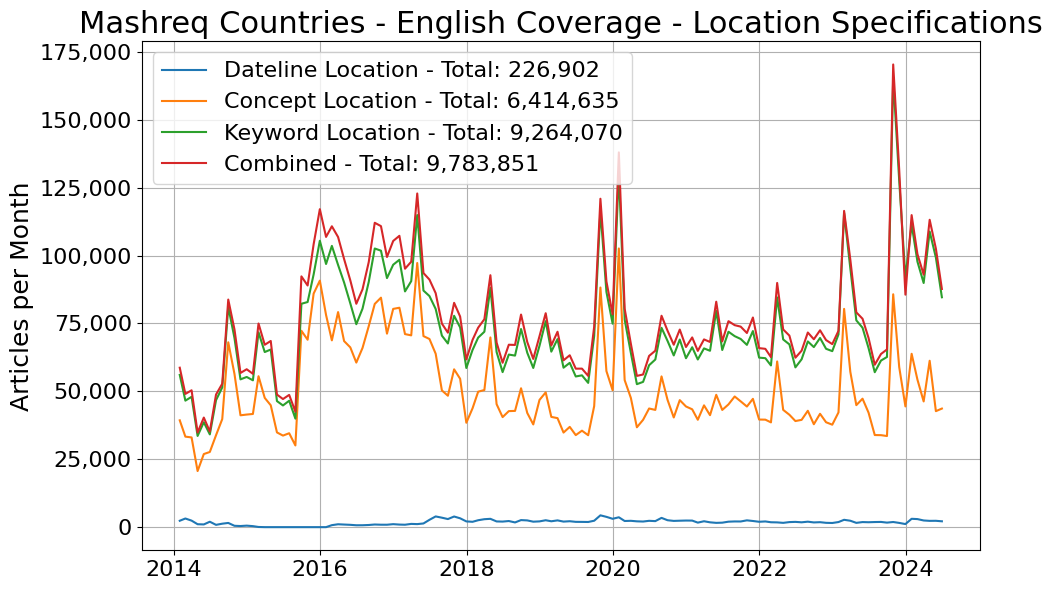

In [220]:
# Plotting
fig, ax = plt.subplots(figsize=(10, 6))  # Set the figure size
ax.plot(df_monthly["date"], df_monthly["count_loc_eng"], linestyle='-', label=f"Dateline Location - Total: {round(df_total['count_loc_eng'].sum()):,}")
ax.plot(df_monthly["date"], df_monthly["count_con_eng"], linestyle='-', label=f"Concept Location - Total: {round(df_total['count_con_eng'].sum()):,}")
ax.plot(df_monthly["date"], df_monthly["count_key_eng"], linestyle='-', label=f"Keyword Location - Total: {round(df_total['count_key_eng'].sum()):,}")
ax.plot(df_monthly["date"], df_monthly["count_clk_eng"], linestyle='-', label=f"Combined - Total: {round(df_total['count_clk_eng'].sum()):,}")

# Adding title and labels
ax.set_title(f'Mashreq Countries - English Coverage - Location Specifications', fontsize=22)
#ax.set_xlabel('Date', fontsize=18)
ax.set_ylabel('Articles per Month', fontsize=18)

# Adding grid
ax.grid(True)

# Formatting the y-axis ticks with commas
def format_with_commas(x, pos):
    return '{:,}'.format(int(x))

ax.yaxis.set_major_formatter(ticker.FuncFormatter(format_with_commas))

# Adjusting the font size of the axis ticks
ax.tick_params(axis='both', which='major', labelsize=16)

# Adding a tight layout
plt.tight_layout()
plt.legend(fontsize=16)

# Saving the plot
plt.savefig(f"{plot_path}monthly-articles/Mashreq_NewsAPI_monthly_articles_2014_2024_eng_locspecifications.png")
plt.show()

In [54]:
# Specify the query string
query_string = """{
  "$query": {
    "$and": [
                {
            "$or": [
                        {
                            "conceptUri": "%s"
                        },
                        {
                            "locationUri": "%s"
                        }
                ]
      },  
      {
        "dateStart": "%s-01-01",
        "dateEnd": "%s-12-31",
        "lang": "%s"
      }
    ]
  },
  "$filter": {
    "isDuplicate": "skipDuplicates"
  }
}"""

In [8]:
# Select the country for which the results should be queried
country = mashreq_countries[0]
print(country)

# Specify the years for which the data should be queried
years = list(range(2024,2013,-1))

Iraq


In [332]:
# Execute the query for each year based on the query_string and the specified parameters
df_list = []
for year in years:
    print(f"Country: {country}, Year: {year}")
    year_string = str(year)
    query = query_string % (er.getConceptUri(country),er.getLocationUri(country), year_string, year_string, language)
    q = QueryArticlesIter.initWithComplexQuery(query)

    # Set requested result to get the source aggregation
    q.setRequestedResult(RequestArticlesTimeAggr())
    res = er.execQuery(q)
    
    totalResults = res['timeAggr']["totalResults"]
    usedResults = res['timeAggr']['usedResults']
    
    print(f"totalResults == usedResults: {totalResults==usedResults}")
    
    if usedResults == 0:
        print(f"No results for {country} in {year}")
        break
    
    # Create a dataframe for the query results of per location for the specified year
    df = pd.DataFrame(res['timeAggr']['results'])
    df["country"] = country
    df_list.append(df)

# Join the yearly dataframes to create one dataframe with query results per location for all years
df_all = pd.concat(df_list)
    

Country: Syria, Year: 2024
totalResults == usedResults: True
Country: Syria, Year: 2023
totalResults == usedResults: True
Country: Syria, Year: 2022
totalResults == usedResults: True
Country: Syria, Year: 2021
totalResults == usedResults: True
Country: Syria, Year: 2020
totalResults == usedResults: True
Country: Syria, Year: 2019
totalResults == usedResults: True
Country: Syria, Year: 2018
totalResults == usedResults: True
Country: Syria, Year: 2017
totalResults == usedResults: True
Country: Syria, Year: 2016
totalResults == usedResults: True
Country: Syria, Year: 2015
totalResults == usedResults: True
Country: Syria, Year: 2014
totalResults == usedResults: True


In [333]:
# save the query results to a csv file
file_name = f"{country.lower()}_2014_2024_daily_articles.csv"
df_all.to_csv(data_path_newsapi_daily + file_name, index = False)

### 3.2 Create plots of the article count for each location

In [68]:
# Select the country for which the results should be loaded
country = mashreq_countries[4]
print(country)

# Load the query results from the csv file
file_name = f"{country.lower()}_2014_2024_daily_articles.csv"
df_all = pd.read_csv(data_path_newsapi_daily + file_name)

Syria


In [69]:
df_all["date"] = pd.to_datetime(df_all["date"])

# Define the cutoff date
cutoff_date = pd.to_datetime('2024-07-01')

# Filter the DataFrame
df_all = df_all[df_all['date'] < cutoff_date]

# Aggregate to a monthly level
df_all_monthly = df_all.groupby(pd.Grouper(key='date', freq='M')).sum().reset_index()
df_all_monthly.drop(columns="country", inplace=True)

/tmp/ipykernel_9145/3537970190.py:10: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_all_monthly = df_all.groupby(pd.Grouper(key='date', freq='M')).sum().reset_index()


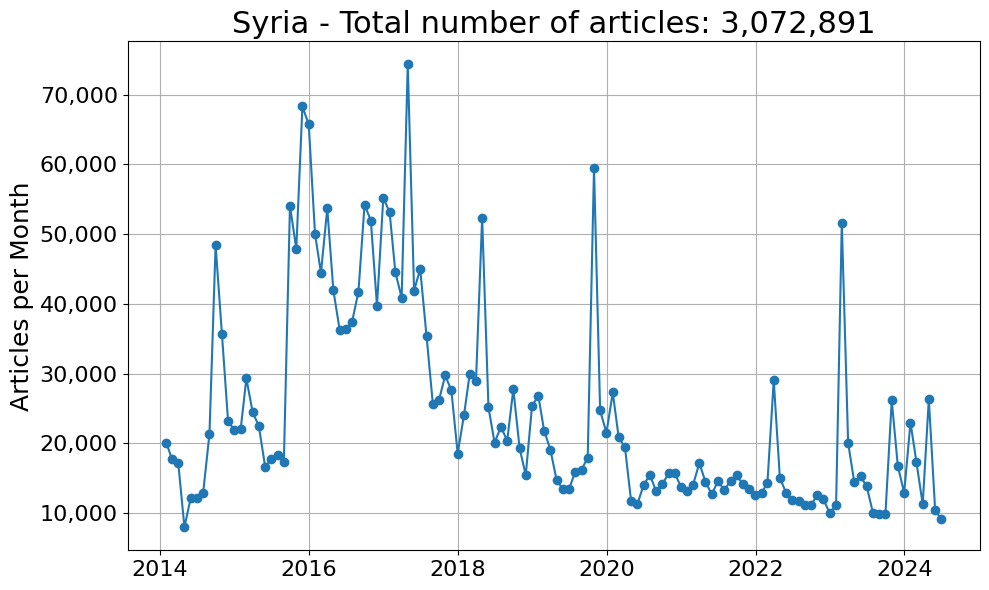

In [70]:
# Plotting
fig, ax = plt.subplots(figsize=(10, 6))  # Set the figure size
ax.plot(df_all_monthly["date"], df_all_monthly["count"], marker='o', linestyle='-')

total_number_of_articles = f"{df_all['count'].sum():,}"

# Adding title and labels
ax.set_title(f'{country} - Total number of articles: {total_number_of_articles}', fontsize=22)
#ax.set_xlabel('Date', fontsize=18)
ax.set_ylabel('Articles per Month', fontsize=18)

# Adding grid
ax.grid(True)

# Formatting the y-axis ticks with commas
def format_with_commas(x, pos):
    return '{:,}'.format(int(x))

ax.yaxis.set_major_formatter(ticker.FuncFormatter(format_with_commas))

# Adjusting the font size of the axis ticks
ax.tick_params(axis='both', which='major', labelsize=16)

# Adding a tight layout
plt.tight_layout()

# Saving the plot
plt.savefig(f"{plot_path}monthly-articles/{country}_NewsAPI_monthly_articles_2014_2024_{df_all['count'].sum()}.png")
plt.show()

### 3.3 Querying IDA countries

In [17]:
ida_countries = pd.read_csv(data_path + "ida_countries.csv")

In [18]:
ida_countries["conceptUri"] = ""
ida_countries["locationUri"] = ""

ida_countries["conceptUri"] = ida_countries["country_name"].apply(lambda x: er.getConceptUri(x))
ida_countries["locationUri"] = ida_countries["country_name"].apply(lambda x: er.getLocationUri(x))

In [20]:
ida_countries["Uri"] = np.nan
ida_countries.loc[ida_countries["conceptUri"] == ida_countries["locationUri"], "Uri"] = ida_countries["conceptUri"]

/tmp/ipykernel_40433/1133292396.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['http://en.wikipedia.org/wiki/Afghanistan'
 'http://en.wikipedia.org/wiki/Bangladesh'
 'http://en.wikipedia.org/wiki/Benin'
 'http://en.wikipedia.org/wiki/Bhutan'
 'http://en.wikipedia.org/wiki/Burkina_Faso'
 'http://en.wikipedia.org/wiki/Burundi'
 'http://en.wikipedia.org/wiki/Cambodia'
 'http://en.wikipedia.org/wiki/Cameroon'
 'http://en.wikipedia.org/wiki/Central_African_Republic'
 'http://en.wikipedia.org/wiki/Chad'
 'http://en.wikipedia.org/wiki/Comoros'
 'http://en.wikipedia.org/wiki/Democratic_Republic_of_the_Congo'
 'http://en.wikipedia.org/wiki/Democratic_Republic_of_the_Congo'
 'http://en.wikipedia.org/wiki/Djibouti'
 'http://en.wikipedia.org/wiki/Dominican_Republic'
 'http://en.wikipedia.org/wiki/Eritrea'
 'http://en.wikipedia.org/wiki/Ethiopia'
 'http://en.wikipedia.org/wiki/Fiji'
 'http://en.wikipedia.org/wi

In [21]:
ida_countries.loc[ida_countries["Uri"].isna()]

,country_name,conceptUri,locationUri,Uri
6,Cabo Verde,http://en.wikipedia.org/wiki/Cabo_Verde_Airlines,"http://en.wikipedia.org/wiki/Cabo_Verde,_Minas...",NaN
14,Côte d'Ivoire,http://en.wikipedia.org/wiki/Ivory_Coast,"http://en.wikipedia.org/wiki/Issia,_Côte_d'Ivoire",NaN
38,Mali,http://en.wikipedia.org/wiki/Cancer,http://en.wikipedia.org/wiki/Mali,NaN
41,Micronesia,http://en.wikipedia.org/wiki/Micronesia,http://en.wikipedia.org/wiki/Federated_States_...,NaN
53,Samoa,http://en.wikipedia.org/wiki/Samoa,http://en.wikipedia.org/wiki/Samoan_Islands,NaN
65,Timor-Leste,http://en.wikipedia.org/wiki/Timor_Leste_Defen...,None,NaN


In [22]:
# Set in these cases the URI manually

ida_countries.loc[ida_countries["country_name"] == "Cabo Verde", "Uri"] = 'http://en.wikipedia.org/wiki/Cape_Verde'
ida_countries.loc[ida_countries["country_name"] == "Côte d'Ivoire", "Uri"] = 'http://en.wikipedia.org/wiki/Ivory_Coast'
ida_countries.loc[ida_countries["country_name"] == "Mali", "Uri"] = 'http://en.wikipedia.org/wiki/Mali'
ida_countries.loc[ida_countries["country_name"] == "Micronesia", "Uri"] = 'https://en.wikipedia.org/wiki/Federated_States_of_Micronesia'
ida_countries.loc[ida_countries["country_name"] == "Samoa", "Uri"] = 'http://en.wikipedia.org/wiki/Samoa'
ida_countries.loc[ida_countries["country_name"] == "Timor-Leste", "Uri"] = 'http://en.wikipedia.org/wiki/East_Timor'

ida_countries.loc[ida_countries["country_name"] == "Republic of Congo", "Uri"] = 'https://en.wikipedia.org/wiki/Republic_of_the_Congo'
ida_countries.loc[ida_countries["country_name"] == "Niger", "Uri"] = 'https://en.wikipedia.org/wiki/Niger'

In [24]:
ida_countries["Uri"]

,country_name,conceptUri,locationUri,Uri
0,Afghanistan,http://en.wikipedia.org/wiki/Afghanistan,http://en.wikipedia.org/wiki/Afghanistan,http://en.wikipedia.org/wiki/Afghanistan
1,Bangladesh,http://en.wikipedia.org/wiki/Bangladesh,http://en.wikipedia.org/wiki/Bangladesh,http://en.wikipedia.org/wiki/Bangladesh
2,Benin,http://en.wikipedia.org/wiki/Benin,http://en.wikipedia.org/wiki/Benin,http://en.wikipedia.org/wiki/Benin
3,Bhutan,http://en.wikipedia.org/wiki/Bhutan,http://en.wikipedia.org/wiki/Bhutan,http://en.wikipedia.org/wiki/Bhutan
4,Burkina Faso,http://en.wikipedia.org/wiki/Burkina_Faso,http://en.wikipedia.org/wiki/Burkina_Faso,http://en.wikipedia.org/wiki/Burkina_Faso
...,...,...,...,...
70,Uzbekistan,http://en.wikipedia.org/wiki/Uzbekistan,http://en.wikipedia.org/wiki/Uzbekistan,http://en.wikipedia.org/wiki/Uzbekistan
71,Vanuatu,http://en.wikipedia.org/wiki/Vanuatu,http://en.wikipedia.org/wiki/Vanuatu,http://en.wikipedia.org/wiki/Vanuatu
72,Yemen,http://en.wikipedia.org/wiki/Yemen,http://en.wikipedia.org/wiki/Yemen,http://en.wikipedia.org/wiki/Yemen
73,Zambia,http://en.wikipedia.org/wiki/Zambia,http://en.wikipedia.org/wiki/Zambia,http://en.wikipedia.org/wiki/Zambia


Query based on conceptURI, locationURI and keywords.

In [25]:
# Template string for the middle part
middle_part_template = """{{
                            "conceptUri": "{0}"
                        }},
                        {{
                            "locationUri": "{0}"
                        }}
                        """
middle_part_template_concept = """{{
                                    "conceptUri": "{0}"
                                    }}
                            """
                            
middle_part_template_location = """{{
                                    "locationUri": "{0}"
                                    }}
                                """
                                
keyword_template = """{{
                        "keyword": "{0}",
                        "keywordLoc": "body"
                        }},
                        {{
                        "keyword": "{0}",
                        "keywordLoc": "title"
                        }}
                        """

In [32]:
ida_countries_total = ida_countries

In [43]:
year = 2024
language = "eng"

In [44]:
df_list = []
for i in range(1, 9):
    # Construct the repeated middle part
    countries_keywords = ",\n                        ".join([keyword_template.format((country)) for country in ida_countries.iloc[((i-1)*10):(i*10)]["country_name"].values])
    countries_uri = ",\n                        ".join([middle_part_template.format((country)) for country in ida_countries.iloc[((i-1)*10):(i*10)]["Uri"].values])


    print(f"IDA countries, Year: {year}, Language: {language}")
    year_string = str(year)
    query = f"""{{
            "$query": {{
                "$and": [
                            {{
                        "$or": [
                                    {countries_uri}
                            ]
                }},  
                {{
                    "dateStart": "{year_string}-01-01",
                    "dateEnd": "{year_string}-12-31",
                    "lang": "{language}"
                }}
                ]
            }},
            "$filter": {{
                "isDuplicate": "skipDuplicates"
            }}
            }}"""
    q = QueryArticlesIter.initWithComplexQuery(query)

    # Set requested result to get the source aggregation
    q.setRequestedResult(RequestArticlesTimeAggr())
    res = er.execQuery(q)

    totalResults = res['timeAggr']["totalResults"]
    usedResults = res['timeAggr']['usedResults']

    if totalResults!=usedResults:
        print(f"totalResults != usedResults: {totalResults!=usedResults}")

    df = pd.DataFrame(res['timeAggr']['results'])
    df["location"] = "IDA" + str(i)
    df_list.append(df)

IDA countries, Year: 2024, Language: eng
IDA countries, Year: 2024, Language: eng
IDA countries, Year: 2024, Language: eng
IDA countries, Year: 2024, Language: eng
IDA countries, Year: 2024, Language: eng
IDA countries, Year: 2024, Language: eng
IDA countries, Year: 2024, Language: eng
IDA countries, Year: 2024, Language: eng


In [47]:
df_ida_count = pd.concat(df_list)

In [52]:
df_ida_count_sum = df_ida_count.drop(columns="location").groupby("date").sum().reset_index()

In [53]:
df_ida_count_sum.rename(columns = {"count":"ida_clk_eng"}, inplace = True)

In [56]:
file_name = f"IDA_daily_2024_clk.csv"
df_ida_count_sum.to_csv(data_path_newsapi_daily + file_name, index = False)

In [57]:
df_ida_count_sum.sum()

date           2024-07-012024-07-022024-07-032024-07-042024-0...
ida_clk_eng                                               370520
dtype: object

Query based on conceptURI and locationURI

In [23]:
ida_countries_uris = ida_countries["Uri"].values

In [433]:
# Template string for the middle part
middle_part_template = """{{
                            "conceptUri": "{0}"
                        }}
                        """

In [444]:
# Construct the repeated middle part
middle_parts_1 = ",\n                        ".join([middle_part_template.format((country)) for country in ida_countries_uris[:50]])
middle_parts_2 = ",\n                        ".join([middle_part_template.format((country)) for country in ida_countries_uris[50:]])

In [445]:
years = list(range(2024,2013,-1))

In [446]:
df_list = []
for year in years:
    print(f"IDA countries, Year: {year}")
    year_string = str(year)
    query = f"""{{
            "$query": {{
                "$and": [
                            {{
                        "$or": [
                                    {middle_parts_2}
                            ]
                }},  
                {{
                    "dateStart": "{year_string}-01-01",
                    "dateEnd": "{year_string}-12-31",
                    "lang": "{language}"
                }}
                ]
            }},
            "$filter": {{
                "isDuplicate": "skipDuplicates"
            }}
            }}"""
    
    q = QueryArticlesIter.initWithComplexQuery(query)

    # Set requested result to get the source aggregation
    q.setRequestedResult(RequestArticlesTimeAggr())
    res = er.execQuery(q)
    
    totalResults = res['timeAggr']["totalResults"]
    usedResults = res['timeAggr']['usedResults']
    
    print(f"totalResults == usedResults: {totalResults==usedResults}")
    
    if usedResults == 0:
        print(f"No results for IDA countries, something went wrong")
        break
    
    df = pd.DataFrame(res['timeAggr']['results'])
    df["location"] = "IDA"
    df_list.append(df)

df_all = pd.concat(df_list)

IDA countries, Year: 2024
totalResults == usedResults: True
IDA countries, Year: 2023
totalResults == usedResults: True
IDA countries, Year: 2022
totalResults == usedResults: True
IDA countries, Year: 2021
totalResults == usedResults: True
IDA countries, Year: 2020
totalResults == usedResults: True
IDA countries, Year: 2019
totalResults == usedResults: True
IDA countries, Year: 2018
totalResults == usedResults: True
IDA countries, Year: 2017
totalResults == usedResults: True
IDA countries, Year: 2016
totalResults == usedResults: True
IDA countries, Year: 2015
totalResults == usedResults: True
IDA countries, Year: 2014
totalResults == usedResults: True


In [447]:
file_name = f"IDA_part2_2014_2024_daily_articles.csv"
df_all.to_csv(data_path_newsapi_daily + file_name, index = False)

In [448]:
ida_part1 = pd.read_csv(data_path_newsapi_daily + "IDA_part1_2014_2024_daily_articles.csv")
ida_part2 = pd.read_csv(data_path_newsapi_daily + "IDA_part2_2014_2024_daily_articles.csv")

In [450]:
ida = ida_part1.merge(ida_part2, on = "date", how="outer")

ida["count"] = ida["count_x"] + ida["count_y"]
ida.drop(columns = ["count_x", "count_y"], inplace = True)

ida["location"] = "IDA"
ida.drop(columns = ["location_x", "location_y"], inplace = True)

file_name = f"IDA_2014_2024_daily_articles.csv"
ida.to_csv(data_path_newsapi_daily + file_name, index = False)

### 3.4 Plotting IDA countries

In [71]:
file_name = f"IDA_2014_2024_daily_articles.csv"
ida = pd.read_csv(data_path_newsapi_daily + file_name)

In [73]:
ida["date"] = pd.to_datetime(ida["date"])

# Define the cutoff date
cutoff_date = pd.to_datetime('2024-07-01')

# Filter the DataFrame
ida = ida[ida['date'] < cutoff_date]

ida_monthly = ida.groupby(pd.Grouper(key='date', freq='M')).sum().reset_index()
ida_monthly.drop(columns="location", inplace=True)

/tmp/ipykernel_9145/4061415103.py:9: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  ida_monthly = ida.groupby(pd.Grouper(key='date', freq='M')).sum().reset_index()


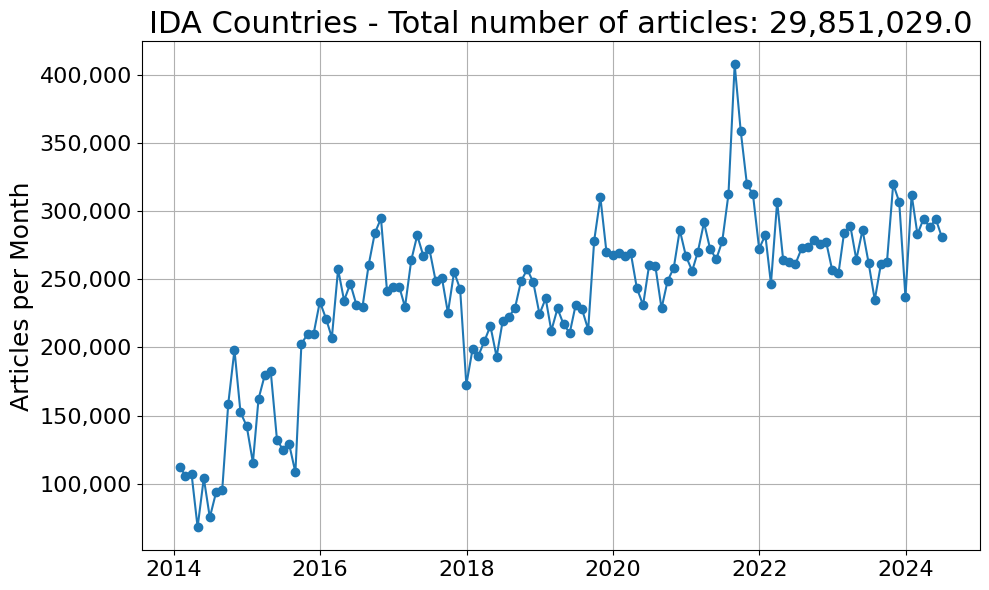

In [74]:
# Plotting
fig, ax = plt.subplots(figsize=(10, 6))  # Set the figure size
ax.plot(df_all_monthly["date"], ida_monthly["count"], marker='o', linestyle='-')

total_number_of_articles = f"{ida['count'].sum():,}"

# Adding title and labels
ax.set_title(f'IDA Countries - Total number of articles: {total_number_of_articles}', fontsize=22)
#ax.set_xlabel('Date', fontsize=18)
ax.set_ylabel('Articles per Month', fontsize=18)

# Adding grid
ax.grid(True)

# Formatting the y-axis ticks with commas
def format_with_commas(x, pos):
    return '{:,}'.format(int(x))

ax.yaxis.set_major_formatter(ticker.FuncFormatter(format_with_commas))

# Adjusting the font size of the axis ticks
ax.tick_params(axis='both', which='major', labelsize=16)

# Adding a tight layout
plt.tight_layout()

# Saving the plot
plt.savefig(f"{plot_path}monthly-articles/IDA_NewsAPI_monthly_articles_2014_2024_{ida['count'].sum()}.png")
plt.show()

## 4. Analyzing Articles - Headlines and Bodies 

### 4.1 Downloading the data

#### 4.1.1 Factiva - Read rtf files and save header

In [ ]:
import pandas as pd
import re
from striprtf.striprtf import rtf_to_text

In [ ]:
def extract_text_from_rtf(rtf_file_path):
    with open(rtf_file_path, 'r') as file:
        rtf_content = file.read()
    text = rtf_to_text(rtf_content)
    return text

In [ ]:
file_path = data_path_factiva_headlines + "raw/bahrain/"
file_names = os.listdir(file_path)

In [ ]:
dfs = []
for file_name in file_names:

    text = extract_text_from_rtf(file_path + file_name)
    lines_list = text.split("\n")
    headlines = [elem for elem in lines_list if "https://global.factiva.com" in elem]
    headlines = [elem.split('("')[0] for elem in headlines]
    headlines = [elem.strip(' ') for elem in headlines]

    meta = [elem for elem in lines_list if "June 2024" in elem]

    dates = []
    sources = []
    for elem in meta:
        if len(elem.split(",")) == 5:
            date = elem.split(",")[2]
            source = elem.split(",")[0]
        elif len(elem.split(",")) == 4:
            date = elem.split(",")[2]
            source = elem.split(",")[0]
        else:
            date = np.nan
            source = np.nan
        dates.append(date)
        sources.append(source)

    df = pd.DataFrame({"source": source, "date": date, "headline": headlines})
    dfs.append(df)
df = pd.concat(dfs).reset_index(drop = True)
df.to_csv(data_path_factiva_headlines + "clean/bahrain/bahrain_article_headers.csv", index = False)

#### 4.1.2 NewsAPI

Query all articles having as concept at least one country of the Mashreq region.

In [140]:
News_API_key_dominik = '7ce3fa46-3bab-4460-a552-e3046d565492'
News_API_key_dominik_wb = '34b2eba6-04d7-4ad0-9aad-06a4bb50fae6'
News_API_key_philipp = '9200e557-062b-411a-8b58-0592c0fac183'
News_API_key = News_API_key_dominik_wb
er = EventRegistry(apiKey = News_API_key)

In [180]:
query_string = """{
  "$query": {
    "$and": [
      {
            "locationUri": "%s"
      },
      {
        "dateStart": "%s",
        "dateEnd": "%s",
        "lang": "%s"
      }
    ]
  },
  "$filter": {
    "isDuplicate": "skipDuplicates"
  }
}"""

In [181]:
query_string = """{
  "$query": {
    "$and": [
                {
            "$or": [
                        {
                            "conceptUri": "%s"
                        },
                        {
                            "locationUri": "%s"
                        }
                ]
      },  
      {
        "dateStart": "%s",
        "dateEnd": "%s",
        "lang": "%s"
      }
    ]
  },
  "$filter": {
    "isDuplicate": "skipDuplicates"
  }
}"""

In [182]:
query = query_string % (er.getConceptUri(region), er.getConceptUri(region), start_date_query_format, end_date_query_format, language)
q = QueryArticlesIter.initWithComplexQuery(query)
q.setRequestedResult(RequestArticlesInfo())
res = q.execQuery(er, maxItems=1000000)

In [183]:
article_list = [article for article in res]
iraq_location = pd.DataFrame(article_list)

In [184]:
article_name = os.listdir(data_path_newsapi_articles)[4]

In [185]:
iraq_concept = pd.read_csv(data_path_newsapi_articles + article_name)

In [195]:
iraq_concept.columns

Index(['uri', 'lang', 'isDuplicate', 'date', 'time', 'dateTime', 'dateTimePub',
       'dataType', 'sim', 'url', 'title', 'body', 'source', 'authors', 'image',
       'eventUri', 'sentiment', 'wgt', 'relevance'],
      dtype='object')

In [196]:
iraq_concept['date'] = pd.to_datetime(iraq_concept['date'])

In [206]:
cutoff_date = pd.Timestamp('2024-06-17')
filtered_df = iraq_concept[iraq_concept['date'] >= cutoff_date]

In [208]:
filtered_df.shape

(6251, 19)

In [209]:
iraq_location.shape

(6326, 19)

In [126]:
for region in mashreq_countries:
    print(region)
    # Create query by filling the query string with the region, start date, end date, and language
    query = query_string % (er.getConceptUri(region), start_date_query_format, end_date_query_format, language)
    q = QueryArticlesIter.initWithComplexQuery(query)
    q.setRequestedResult(RequestArticlesInfo())
    res = q.execQuery(er, maxItems=1000000)

    article_list = [article for article in res]
    article_df = pd.DataFrame(article_list)

    no_articles = article_df.shape[0]

    region = region.lower().replace(" ", "_")

    file_name_newsapi = f"{region}_{start_date_filename_format}_{end_date_filename_format}_{language}_{no_articles}_articles_newsapi.csv"

    article_df.to_csv(data_path_newsapi_articles + file_name_newsapi, index = False)

    print(f"{file_name_newsapi} \n")

Bahrain
bahrain_06162024_06302024_eng_1889_articles_newsapi.csv 

Egypt
egypt_06162024_06302024_eng_10094_articles_newsapi.csv 

Iraq
iraq_06162024_06302024_eng_6497_articles_newsapi.csv 

Israel
israel_06162024_06302024_eng_33179_articles_newsapi.csv 

Jordan
jordan_06162024_06302024_eng_7500_articles_newsapi.csv 

Kuwait
kuwait_06162024_06302024_eng_1937_articles_newsapi.csv 

Lebanon
lebanon_06162024_06302024_eng_7897_articles_newsapi.csv 

Libya
libya_06162024_06302024_eng_1250_articles_newsapi.csv 

Oman
oman_06162024_06302024_eng_2114_articles_newsapi.csv 

Qatar
qatar_06162024_06302024_eng_5955_articles_newsapi.csv 

Saudi Arabia
saudi_arabia_06162024_06302024_eng_13562_articles_newsapi.csv 

Sudan
sudan_06162024_06302024_eng_2691_articles_newsapi.csv 

Palestine
palestine_06162024_06302024_eng_1952_articles_newsapi.csv 

Syria
syria_06162024_06302024_eng_4276_articles_newsapi.csv 

United Arab Emirates
united_arab_emirates_06162024_06302024_eng_10831_articles_newsapi.csv 

Yeme

### 4.2 Analyzing if paywalls are an issue in NewsAPI data

In [ ]:
News_API_key = '7ce3fa46-3bab-4460-a552-e3046d565492'
er = EventRegistry(apiKey = News_API_key)

#### 4.2.1 Paywalls over time for common news sources

The idea of this section was to look for the most common news sources in the entire Mashreq region and to check manually on their homepage if they use paywalls and what the paywalls look like. However, it seems that most of the most frequently used news sources do not have paywalls on their homepages.

Note that the free version only allowed to filter for 15 concepts. 
I excluded Bahrain as it is the second country with the least articles and likely not very relevant for World Bank activities.

In [ ]:
query_string = """{
  "$query": {
    "$and": [
                {
            "$or": [
                        {
                            "conceptUri": "http://en.wikipedia.org/wiki/Egypt"
                        },
                        {
                            "conceptUri": "http://en.wikipedia.org/wiki/Iraq"
                        },
                        {
                            "conceptUri": "http://en.wikipedia.org/wiki/Israel"
                        },
                        {
                            "conceptUri": "http://en.wikipedia.org/wiki/Jordan"
                        },
                        {
                            "conceptUri": "http://en.wikipedia.org/wiki/Kuwait"
                        },
                        {
                            "conceptUri": "http://en.wikipedia.org/wiki/Lebanon"
                        },
                        {
                            "conceptUri": "http://en.wikipedia.org/wiki/Libya"
                        },
                        {
                            "conceptUri": "http://en.wikipedia.org/wiki/Oman"
                        },
                        {
                            "conceptUri": "http://en.wikipedia.org/wiki/Palestine"
                        },
                        {
                            "conceptUri": "http://en.wikipedia.org/wiki/Qatar"
                        },
                        {
                            "conceptUri": "http://en.wikipedia.org/wiki/Saudi_Arabia"
                        },
                        {
                            "conceptUri": "http://en.wikipedia.org/wiki/Sudan"
                        },
                        {
                            "conceptUri": "http://en.wikipedia.org/wiki/Syria"
                        },
                        {
                            "conceptUri": "http://en.wikipedia.org/wiki/United_Arab_Emirates"
                        },
                        {
                            "conceptUri": "http://en.wikipedia.org/wiki/Yemen"
                        }
                ]
      },  
      {
        "dateStart": "%s",
        "dateEnd": "%s",
        "lang": "%s"
      }
    ]
  },
  "$filter": {
    "isDuplicate": "skipDuplicates"
  }
}"""

In [ ]:
# Create query by filling the query string with the country, start date, end date, and language
query = query_string % (start_date_query_format, end_date_query_format, language)
q = QueryArticlesIter.initWithComplexQuery(query)

# Set requested result to get the source aggregation
q.setRequestedResult(RequestArticlesSourceAggr(sourceCount = 100))
res = er.execQuery(q)

In [ ]:
# Create a list of dictionaries to save the results for different sources
dict_list = []
for i in range(len(res["sourceAggr"]["countsPerSource"])):
    dict_list.append(res["sourceAggr"]["countsPerSource"][i]["source"] | res["sourceAggr"]["countsPerSource"][i]["counts"])

# Create a filename for the csv file to save the results    
region = country.lower().replace(" ", "_")
no_results = res["sourceAggr"]["totalResults"]
file_name_newsapi = f"{region}_{start_date_filename_format}_{end_date_filename_format}_{language}_{no_results}_newsapi.csv"

In [ ]:
pd.DataFrame(dict_list).head(20)

In [ ]:
# Create a list of dictionaries to save the results for different sources
dict_list = []
for i in range(len(res["sourceAggr"]["countsPerSource"])):
    dict_list.append(res["sourceAggr"]["countsPerSource"][i]["source"] | res["sourceAggr"]["countsPerSource"][i]["counts"])

# Create a filename for the csv file to save the results    
region = country.lower().replace(" ", "_")
no_results = res["sourceAggr"]["totalResults"]
file_name_newsapi = f"{region}_{start_date_filename_format}_{end_date_filename_format}_{language}_{no_results}_newsapi.csv"
pd.DataFrame(dict_list).to_csv(data_path_newsapi_sources + file_name_newsapi, index = False)

#### 4.2.2 Searching for paywalls in article bodies

In [116]:
# Defining a list of words likely to appear in paywalls
paywall_keywords = [
    "subscribe",
    "subscription",
    "sign up",
    "subscribe now",
    "register",
    "register now",
    "become a subscriber",
    "exclusive content",
    "member",
    "membership",
    "paywall",
    "pay",
    "payment",
    "purchase",
    "paid content",
    "buy now",
    "access to",
    "read more",
    "continue reading",
    "read the full article",
    "log in to read more",
    "unlock",
    "get access",
    "full access",
    "free trial",
    "start your free trial",
    "trial period",
    "login",
    "log in",
    "already a subscriber?",
    "only available to subscribers",
    "upgrade",
    "upgrade your plan",
    "sign in",
    "sign in to continue",
    "premium",
    "join now",
    "create an account",
    "limited access",
    "exclusive access",
    "premium content",
    "exclusive articles",
    "limited content",
    "subscription required"
]

In [117]:
# Function to count keyword occurrences in an article
def count_keywords(article):
    return sum(article.lower().count(keyword) for keyword in paywall_keywords)

In [6]:
article_file_names = os.listdir(data_path_newsapi_articles)

In [119]:
articles = pd.read_csv(data_path_newsapi_articles + article_file_names[0])

In [120]:
# Apply the function to the DataFrame
articles['paywall_keyword_count'] = articles['body'].apply(count_keywords)
articles["article_length"] = articles['body'].apply(lambda x: len(x.split(" ")))
articles["paywall_probability"] = articles["paywall_keyword_count"] / articles["article_length"]

In [121]:
articles.sort_values("paywall_probability", ascending = True).head(20)["body"].values

array(['Asaduddin Owaisi, the leader of the All India Majlis-e-Ittehadul Muslimeen (AIMIM), has once again demonstrated his proclivity for controversial and divisive rhetoric by invoking Palestine during a sensitive oath-taking ceremony. Owaisi\'s call for Prime Minister Modi to stand with Palestinians and his inflammatory label of Israeli Prime Minister Netanyahu as a "devil" exemplifies his disregard for India\'s diplomatic stance and highlights his agenda of stoking communal sentiments for political gain.\n\nOwaisi\'s statements not only undermine India\'s balanced diplomatic relations but also expose his intent to polarize communities. His rhetoric suggests a prioritization of international Islamic solidarity over India\'s national interests. This is particularly problematic given that Owaisi has built his political career on an anti-Hindu narrative, often positioning himself as the defender of Muslim interests against a perceived Hindu majority oppression.\n\nFurthermore, Owaisi\'

In [98]:
article_list['paywall_probability'].describe()

count    6497.000000
mean        0.001712
std         0.003162
min         0.000000
25%         0.000000
50%         0.000455
75%         0.002392
max         0.085714
Name: paywall_probability, dtype: float64

### 4.3 Compare the headlines

In [29]:
from thefuzz import process
from thefuzz import fuzz

In [ ]:
country = "bahrain"

In [30]:
factiva_header = pd.read_csv(data_path_factiva_headlines + f"clean/{country}/{country}_article_headers.csv")
factiva_header["headline"] = factiva_header["headline"].apply(lambda x: x.lower())

newsapi_headers = pd.read_csv(data_path_newsapi_articles + "bahrain_06162024_06302024_eng_1889_articles_newsapi.csv")
newsapi_headers["title"] = newsapi_headers["title"].apply(lambda x: x.lower())

In [34]:
no_factiva_articles = factiva_header.shape[0]
no_exact_matches_with_newsapi = factiva_header["headline"].apply(lambda x: x in newsapi_headers["title"].values).sum()

no_newsapi_articles = newsapi_headers.shape[0]
no_exact_matches_with_factiva = newsapi_headers["title"].apply(lambda x: x in factiva_header["headline"].values).sum()

print(country)
print(f"Out of {no_factiva_articles} on Factiva, {no_exact_matches_with_newsapi} are exact matches with NewsAPI")
print(f"Out of {no_newsapi_articles} on NewsAPI, {no_exact_matches_with_factiva} are exact matches with Factiva")

NameError: name 'country' is not defined

In [22]:
factiva_header["source"].value_counts()

source
DT News                                400
City AM Online                         100
Islamic Finance News - Contify         100
PR Newswire Asia                       100
ZAWYA by Refinitiv - Press Releases    100
The Manila Times                        63
Name: count, dtype: int64

In [32]:
# Matching Newsapi article titles with Factiva article titles
newsapi_headers["matched_title"] = newsapi_headers["title"].apply(lambda x: process.extract(x, factiva_header["headline"].values, scorer=fuzz.ratio)[0][0])
newsapi_headers["matched_proba"] = newsapi_headers["title"].apply(lambda x: process.extract(x, factiva_header["headline"].values, scorer=fuzz.ratio)[0][1])

# Matching Factiva article titles with NewsAPI article titles
factiva_header["matched_title"] = factiva_header["headline"].apply(lambda x: process.extract(x, newsapi_headers["title"].values, scorer=fuzz.ratio)[0][0])
factiva_header["matched_proba"] = factiva_header["headline"].apply(lambda x: process.extract(x, newsapi_headers["title"].values, scorer=fuzz.ratio)[0][1])

In [37]:
import seaborn as sns

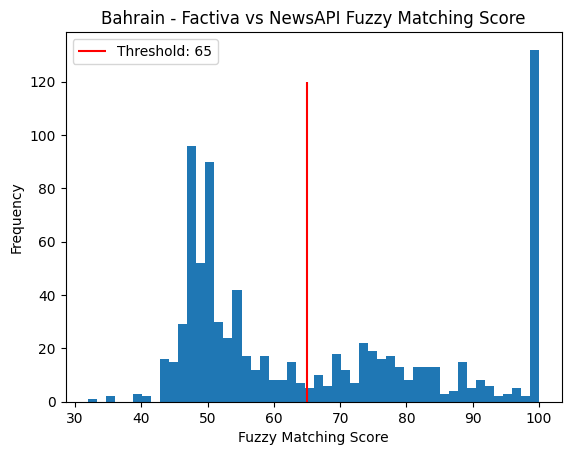

In [88]:
plt.hist(factiva_header["matched_proba"], bins=50)
plt.title("Bahrain - Factiva vs NewsAPI Fuzzy Matching Score")
plt.ylabel("Frequency")
plt.xlabel("Fuzzy Matching Score")
plt.vlines(x = 65,ymin=0, ymax=120, color = "red")
plt.legend(["Threshold: 65"])
plt.show()

In [77]:
matched_factiva_articles = factiva_header.loc[factiva_header["matched_proba"] > 65, ["headline", "matched_title", "matched_proba"]].sort_values("matched_proba", ascending = True).reset_index(drop = True)

In [120]:
score_min = 0
for score_max in range(10, 110,10):
    matched_factiva_articles = factiva_header.loc[(factiva_header["matched_proba"] <= score_max) & (factiva_header["matched_proba"] > score_min), ["headline", "matched_title", "matched_proba"]].sort_values("matched_proba", ascending = True).reset_index(drop = True)
    if matched_factiva_articles.shape[0] > 0:
        matched_factiva_articles = matched_factiva_articles.sample(n=5)
        print(f"Score range: {score_min} - {score_max}")
        for row in matched_factiva_articles.iterrows():
            print(row[1]["headline"])
            print(row[1]["matched_title"])
            print(row[1]["matched_proba"])
            print("\n")
    score_min = score_max


Score range: 30 - 40
hres1102
mclaren's
35


suspect held
discovery sets the pace
40


school books plan
poyer ai book
40


bkic - مجلس الادارة يجتمع في 12 أغسطس 2024م
morning briefing: june 25, 2024
32


thyssenkrupp ag
poyer ai book
36


Score range: 40 - 50
pylontech launches new generation of residential storage solution at intersolar europe 2024
gig gulf launches region's first cashback promotion with personal insurance products
49


nass asphalt - the organizational chart displays its 8 executives, including shawqi al hashimi and sameer abdulla nass
south korea is surging the travel industry with new visa-free entry policy for 103 countries, including usa, thailand and schengen nations - travel and tour world
47


mideast mystery
nissan mideast sales surge 6pc
49


call to spread love and peace
sabre to offer etihad ndc content
48


work on hidd project road on track
gulf markets show mixed performance amid holiday trade
48


Score range: 50 - 60
prime minister shehbaz sharif and

In [40]:
import ast

In [97]:
ast.literal_eval(newsapi_headers["source"][0])["uri"]

'arab.news'

In [103]:
newsapi_headers["source"].apply(lambda x: ast.literal_eval(x)["uri"]).value_counts()[:100].sum()

np.int64(1209)

In [104]:
438+770

1208

## 5. Event studies

In [211]:
News_API_key_dominik = '7ce3fa46-3bab-4460-a552-e3046d565492'
News_API_key_philipp = '9200e557-062b-411a-8b58-0592c0fac183'
News_API_key = News_API_key_philipp
er = EventRegistry(apiKey = News_API_key)

In [212]:
# Template string for the middle part
keyword_concept_template = """{{
                            "conceptUri": "{0}"
                        }}
                        """
                        
keyword_template = """{{
                        "keyword": "{0}",
                        "keywordLoc": "body"
                        }}
                        """

In [213]:
def return_query_string(keywords_df, country_uri, year_string, language, concept=False):
    if concept:
        keyword_template_filled = ",\n                        ".join([keyword_concept_template.format(keywordUri) for keywordUri in keywords_df["conceptUri"].values])
    else:
        keyword_template_filled = ",\n                        ".join([keyword_template.format(keyword) for keyword in keywords_df["keyword"].values])
    
    query = f"""{{
            "$query": {{
                "$and": [
                            {{
                            "$or": [
                                        {keyword_template_filled}
                                    ]
                            }},  
                            {{
                            "$or": [
                                    {{
                                        "conceptUri": "{country_uri}"
                                    }},
                                    {{
                                        "locationUri": "{country_uri}"
                                    }}
                                ]
                            }},   
                            {{
                                "dateStart": "{year_string}-01-01",
                                "dateEnd": "{year_string}-12-31",
                                "lang": "{language}"
                            }}
                        ]
            }},
            "$filter": {{
                "isDuplicate": "skipDuplicates"
            }}
            }}"""
    return query

In [214]:
def plot_df(df, column, title, path, filename=None):

    # Plotting
    fig, ax = plt.subplots(figsize=(10, 6))  # Set the figure size
    ax.plot(df["date"], df[column], marker='o', linestyle='-')

    # Adding title and labels
    ax.set_title(f'{title}', fontsize=22)
    ax.set_ylabel('Percent of Articles', fontsize=18)

    # Adding grid
    ax.grid(True)

    # Formatting the y-axis ticks with commas
    def format_with_commas(x, pos):
        return '{:,}'.format(int(x))

    ax.yaxis.set_major_formatter(ticker.FuncFormatter(format_with_commas))

    # Adjusting the font size of the axis ticks
    ax.tick_params(axis='both', which='major', labelsize=16)

    # Formatting the x-axis to show only month and day
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))
    
    # Adding a tight layout
    plt.tight_layout()

    # Saving the plot
    if filename:
        plt.savefig(path + filename)
    
    plt.show()

### 5.1 Southern Syria protests (2023–present)

Where: As-Suwayda and Daraa regions

- Case 1: Concepts - "food prices", "protest", "fuel", "subsidies", "cost", "prices", "inflation", "strike"
- Case 2: Keywords - "food prices", "protest", "fuel", "subsidies", "cost", "prices", "inflation", "strike"
- Case 3: Concepts - "protest", "strike"
- Case 4: Keywords - "protest", "strike"
- Case 5: Keywords - "food prices", "protest", "fuel", "subsidies", "cost", "prices", "inflation"
- Case 6: Keywords - "أسعار المواد الغذائية"، "الاحتجاج"، "الوقود"، "الدعم"، "التكلفة"، "الأسعار"، "التضخم"، "الإضراب"



Start date: 17 August 2023

Info: https://en.wikipedia.org/wiki/Southern_Syria_protests_(2023%E2%80%93present)

In [225]:
data_path_newsapi_daily_ssp = data_path_newsapi_daily + "southern-syrian-protest/"

#### 5.1.1 Query

In [227]:
language = "ara"

In [228]:
country = mashreq_countries[4]
country_uri = er.getLocationUri(country)
print(f"Country URI: {country_uri}")

# Possibly add location
#location1_uri = 'https://en.wikipedia.org/wiki/As-Suwayda_Governorate'
#location2_uri = 'https://en.wikipedia.org/wiki/Daraa_Governorate'

year = 2023
year_string = str(year)
print(f"Year: {year_string}")

Country URI: http://en.wikipedia.org/wiki/Syria
Year: 2023


In [230]:
keywords_case_1 = ["food prices", "protest", "fuel", "subsidies", "cost", "prices", "inflation", "strike"]
keywords_case_3 = ["protest", "strike"]
keywords_case_5 = ["food prices", "protest", "fuel", "subsidies", "cost", "prices", "inflation", "strike"]
keywords_case_6 = ["أسعار المواد الغذائية", "الاحتجاج", "الوقود", "الدعم", "التكلفة", "الأسعار", "التضخم", "الإضراب"]

keywords = keywords_case_6
keywords_df = pd.DataFrame({"keyword": keywords, "conceptUri": [er.getConceptUri(keyword) for keyword in keywords]})

In [231]:
keywords_df.loc[keywords_df["keyword"] == "subsidies", "conceptUri"] = "https://en.wikipedia.org/wiki/Subsidy"
keywords_df.loc[keywords_df["keyword"] == "cost", "conceptUri"] = "https://en.wikipedia.org/wiki/Cost"
keywords_df.loc[keywords_df["keyword"] == "prices", "conceptUri"] = "https://en.wikipedia.org/wiki/Price"
keywords_df

,keyword,conceptUri
0,أسعار المواد الغذائية,None
1,الاحتجاج,http://ar.wikipedia.org/wiki/الاحتجاجات_السودا...
2,الوقود,http://ar.wikipedia.org/wiki/معدل_استهلاك_الوقود
3,الدعم,http://ar.wikipedia.org/wiki/قوات_الدعم_السريع...
4,التكلفة,None
5,الأسعار,None
6,التضخم,None
7,الإضراب,None


In [232]:
query = return_query_string(keywords_df, country_uri, year_string, language, concept=False)

In [233]:
query

'{\n            "$query": {\n                "$and": [\n                            {\n                            "$or": [\n                                        {\n                        "keyword": "أسعار المواد الغذائية",\n                        "keywordLoc": "body"\n                        }\n                        ,\n                        {\n                        "keyword": "الاحتجاج",\n                        "keywordLoc": "body"\n                        }\n                        ,\n                        {\n                        "keyword": "الوقود",\n                        "keywordLoc": "body"\n                        }\n                        ,\n                        {\n                        "keyword": "الدعم",\n                        "keywordLoc": "body"\n                        }\n                        ,\n                        {\n                        "keyword": "التكلفة",\n                        "keywordLoc": "body"\n                        }\n    

In [234]:
# execute_query
q = QueryArticlesIter.initWithComplexQuery(query)
# Set requested result to get the source aggregation
q.setRequestedResult(RequestArticlesTimeAggr())
res = er.execQuery(q)

totalResults = res['timeAggr']["totalResults"]
usedResults = res['timeAggr']['usedResults']

print(f"totalResults == usedResults: {totalResults==usedResults}")

if usedResults == 0:
    print(f"No results, something went wrong")

df = pd.DataFrame(res['timeAggr']['results'])

totalResults == usedResults: True


In [237]:
def extract_digit(input_string):
    match = re.search(r'\d', input_string)
    return int(match.group()) if match else None

# List all items in the directory
all_items = os.listdir(data_path_newsapi_daily_ssp)

# Filter out only the directories
folders = [item for item in all_items if os.path.isdir(os.path.join(data_path_newsapi_daily_ssp, item))]

try:
    highest_case = sorted(folders)[-1]
    case_id = extract_digit(highest_case) + 1
except:  
    case_id = 1
print(f"Case ID: {case_id}")

os.mkdir(data_path_newsapi_daily_ssp + f"case_{case_id}")
print(f"Directory created: {data_path_newsapi_daily_ssp}case_{case_id}")

Case ID: 6
Directory created: ../../data/newsapi/articles-daily/southern-syrian-protest/case_6


In [238]:
os.listdir(data_path_newsapi_daily_ssp)

['case_2',
 'case_5',
 '.~lock.factiva_case4.csv#',
 'case_4',
 'factiva_case4.csv',
 'case_3',
 'case_6',
 'case_1']

In [239]:
# Load the query results from the csv file
file_name = f"{country.lower()}_2023_daily_articles_case{case_id}.csv"
df.to_csv(f"{data_path_newsapi_daily_ssp}case_{case_id}/{file_name}", index=False)

# Save the query specification
file_path = f"{data_path_newsapi_daily_ssp}case_{case_id}/query.txt"
# Open the file in write mode and write the string to it
with open(file_path, 'w') as file:
    file.write(query)

#### 5.1.2 Create plot

- Case 1: Concepts - "food prices", "protest", "fuel", "subsidies", "cost", "prices", "inflation", "strike"
- Case 2: Keywords - "food prices", "protest", "fuel", "subsidies", "cost", "prices", "inflation", "strike"
- Case 3: Concepts - "protest", "strike"
- Case 4: Keywords - "protest", "strike"
- Case 5: Keywords - "food prices", "protest", "fuel", "subsidies", "cost", "prices", "inflation"
- Case 6: Keywords - "أسعار المواد الغذائية"، "الاحتجاج"، "الوقود"، "الدعم"، "التكلفة"، "الأسعار"، "التضخم"، "الإضراب"



In [240]:
plot_path_ssp = plot_path+"event-studies/southern-syrian-protest/"
year = 2023

In [241]:
country = "Syria"
case_id = 6

In [242]:
# Load the query results from the csv file
file_name = f"{country.lower()}_{year}_daily_articles_case{case_id}.csv"
df = pd.read_csv(f"{data_path_newsapi_daily_ssp}case_{case_id}/{file_name}")
df["date"] = pd.to_datetime(df["date"])

# Load the count for the entire country without keywords
df_total = pd.read_csv(data_path_newsapi_daily + "syria_2014_2024_daily_articles.csv")
df_total["date"] = pd.to_datetime(df_total["date"])

In [243]:
# Define the cutoff date
cutoff_date_start = pd.to_datetime(f'{year}-07-01')
cutoff_date_end = pd.to_datetime(f'{year}-09-30')

# Filter the DataFrame
df = df[(df['date'] >= cutoff_date_start) & (df['date'] <= cutoff_date_end)]
df_total = df_total[(df_total['date'] >= cutoff_date_start) & (df_total['date'] <= cutoff_date_end)]

In [244]:
df_total = df_total.merge(df, on = "date", how = "inner", suffixes=('_total', '_case'))
df_total["share"] = df_total["count_case"] / df_total["count_total"] * 100

In [137]:
# Convert 'date' column to datetime
df_total['date'] = pd.to_datetime(df_total['date'])

# Set the 'date' column as the index
df_total.set_index('date', inplace=True)

# Resample by week and aggregate
weekly_df = df_total.resample('W').agg({
    'count_total': 'sum',
    'country': 'first',  # Assuming the country remains the same
    'count_case': 'sum',
    'share': 'mean'
})

weekly_df.reset_index(inplace=True)
df_total.reset_index(inplace=True)

if df_total.loc[(df_total["date"] <= weekly_df["date"].values[0]),].shape[0] != 7:
    weekly_df = weekly_df[1:]
    
if df_total.loc[(df_total["date"] > weekly_df["date"].values[-2]),].shape[0] != 7:
    weekly_df = weekly_df[:-2]

In [139]:
weekly_df

,date,count_total,country,count_case,share
1,2023-07-09,2382,Syria,604,25.390760
2,2023-07-16,2418,Syria,654,26.848004
3,2023-07-23,2252,Syria,580,26.154360
4,2023-07-30,2104,Syria,547,27.183196
5,2023-08-06,2013,Syria,469,23.967573
6,2023-08-13,2112,Syria,531,24.784343
7,2023-08-20,1731,Syria,451,25.854320
8,2023-08-27,2801,Syria,636,23.094134
9,2023-09-03,2264,Syria,619,27.387685
10,2023-09-10,2262,Syria,502,22.387967


In [138]:
df_total.loc[(df_total["date"] <= weekly_df["date"].values[0]),]

,date,count_total,country,count_case,share
0,2023-07-01,232,Syria,42,18.103448
1,2023-07-02,359,Syria,88,24.512535
2,2023-07-03,274,Syria,74,27.007299
3,2023-07-04,203,Syria,42,20.689655
4,2023-07-05,315,Syria,77,24.444444
5,2023-07-06,547,Syria,112,20.475320
6,2023-07-07,434,Syria,105,24.193548
7,2023-07-08,276,Syria,43,15.579710
8,2023-07-09,333,Syria,151,45.345345


from 2023-07-03 to 2023-07-09

from 2023-07-10 to 2023-07-16

...

In [224]:
df_total

,date,count_total,country,count_case,share
0,2023-07-02,359,Syria,1,0.278552
1,2023-07-03,274,Syria,1,0.364964
2,2023-07-07,434,Syria,1,0.230415
3,2023-07-08,276,Syria,1,0.362319
4,2023-07-09,333,Syria,3,0.900901
5,2023-07-11,385,Syria,1,0.259740
6,2023-07-13,375,Syria,1,0.266667
7,2023-07-28,327,Syria,6,1.834862
8,2023-07-29,188,Syria,23,12.234043
9,2023-08-13,212,Syria,1,0.471698


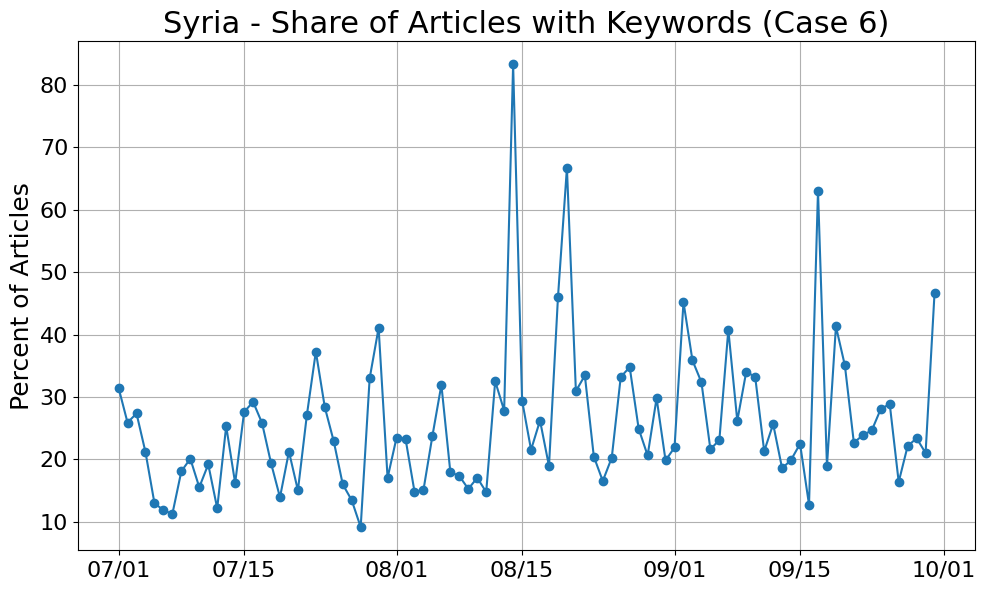

In [245]:
title = f"{country} - Share of Articles with Keywords (Case {case_id})"
plot_filename = f"{country.lower()}_2023_daily_articles_case{case_id}.png"
plot_df(df = df_total, column = "share", title=title, path=plot_path_ssp, filename=plot_filename)

### 5.2 2018 Jordanian protests


Case 1: Concepts - "fuel prices", "protest", "electricity prices", "trade union", "strike"

Case 2: Keywords - "fuel prices", "protest", "electricity prices", "trade union", "strike"


30 May 2018 - 7 June 2018

Info: https://en.wikipedia.org/wiki/2018_Jordanian_protests

In [275]:
data_path_newsapi_daily_ssp = data_path_newsapi_daily + "jordanian-protest-2018/"

#### 5.2.1 Query

In [416]:
country = mashreq_countries[1]
country_uri = er.getLocationUri(country)
print(f"Country URI: {country_uri}")

year = 2018
year_string = str(year)
print(f"Year: {year_string}")

Country URI: http://en.wikipedia.org/wiki/Jordan
Year: 2018


In [418]:
keywords_case_1 = ["fuel prices", "protest", "electricity prices", "trade union", "strike"]

keywords = keywords_case_1
keywords_df = pd.DataFrame({"keyword": keywords, "conceptUri": [er.getConceptUri(keyword) for keyword in keywords]})

In [419]:
keywords_df.loc[keywords_df["keyword"] == "fuel prices", "conceptUri"] = "https://en.wikipedia.org/wiki/Gasoline_and_diesel_usage_and_pricing"
keywords_df.loc[keywords_df["keyword"] == "electricity prices", "conceptUri"] = "https://en.wikipedia.org/wiki/Electricity_pricing"

keywords_df

,keyword,conceptUri
0,fuel prices,https://en.wikipedia.org/wiki/Gasoline_and_die...
1,protest,http://en.wikipedia.org/wiki/Demonstration
2,electricity prices,https://en.wikipedia.org/wiki/Electricity_pricing
3,trade union,http://en.wikipedia.org/wiki/Trade_union
4,strike,http://en.wikipedia.org/wiki/Strike_action


In [420]:
query = return_query_string(keywords_df, country_uri, year_string, language, concept=False)

In [422]:
# execute_query
q = QueryArticlesIter.initWithComplexQuery(query)
# Set requested result to get the source aggregation
q.setRequestedResult(RequestArticlesTimeAggr())
res = er.execQuery(q)

totalResults = res['timeAggr']["totalResults"]
usedResults = res['timeAggr']['usedResults']

print(f"totalResults == usedResults: {totalResults==usedResults}")

if usedResults == 0:
    print(f"No results, something went wrong")

df = pd.DataFrame(res['timeAggr']['results'])

totalResults == usedResults: True


In [423]:
def extract_digit(input_string):
    match = re.search(r'\d', input_string)
    return int(match.group()) if match else None

try:
    highest_case = sorted(os.listdir(data_path_newsapi_daily_ssp))[-1]
    case_id = extract_digit(highest_case) + 1
except:  
    case_id = 1
print(f"Case ID: {case_id}")

os.mkdir(data_path_newsapi_daily_ssp + f"case_{case_id}")
print(f"Directory created: {data_path_newsapi_daily_ssp}case_{case_id}")

Case ID: 2
Directory created: ../../data/newsapi/articles-daily/jordanian-protest-2018/case_2


In [424]:
# Load the query results from the csv file
file_name = f"{country.lower()}_{year}_daily_articles_case{case_id}.csv"
df.to_csv(f"{data_path_newsapi_daily_ssp}case_{case_id}/{file_name}", index=False)

# Save the query specification
file_path = f"{data_path_newsapi_daily_ssp}case_{case_id}/query.txt"
# Open the file in write mode and write the string to it
with open(file_path, 'w') as file:
    file.write(query)

#### 5.2.2 Create plot

- Case 1: Concepts - "fuel prices", "protest", "electricity prices", "trade union", "strike"
- Case 2: Keywords - "fuel prices", "protest", "electricity prices", "trade union", "strike"

In [276]:
country = "Jordan"
case_id = 2
year = 2018

In [277]:
# Load the query results from the csv file
file_name = f"{country.lower()}_{year}_daily_articles_case{case_id}.csv"
df = pd.read_csv(f"{data_path_newsapi_daily_ssp}case_{case_id}/{file_name}")
df["date"] = pd.to_datetime(df["date"])

# Load the count for the entire country without keywords
df_total = pd.read_csv(data_path_newsapi_daily + "jordan_2014_2024_daily_articles.csv")
df_total["date"] = pd.to_datetime(df_total["date"])

In [278]:
# Define the cutoff date
cutoff_date_start = pd.to_datetime(f'{year}-05-20')
cutoff_date_end = pd.to_datetime(f'{year}-06-15')

# Filter the DataFrame
df = df[(df['date'] >= cutoff_date_start) & (df['date'] <= cutoff_date_end)]
df_total = df_total[(df_total['date'] >= cutoff_date_start) & (df_total['date'] <= cutoff_date_end)]

In [279]:
df_total = df_total.merge(df, on = "date", how = "inner", suffixes=('_total', '_case'))
df_total["share"] = df_total["count_case"] / df_total["count_total"] * 100

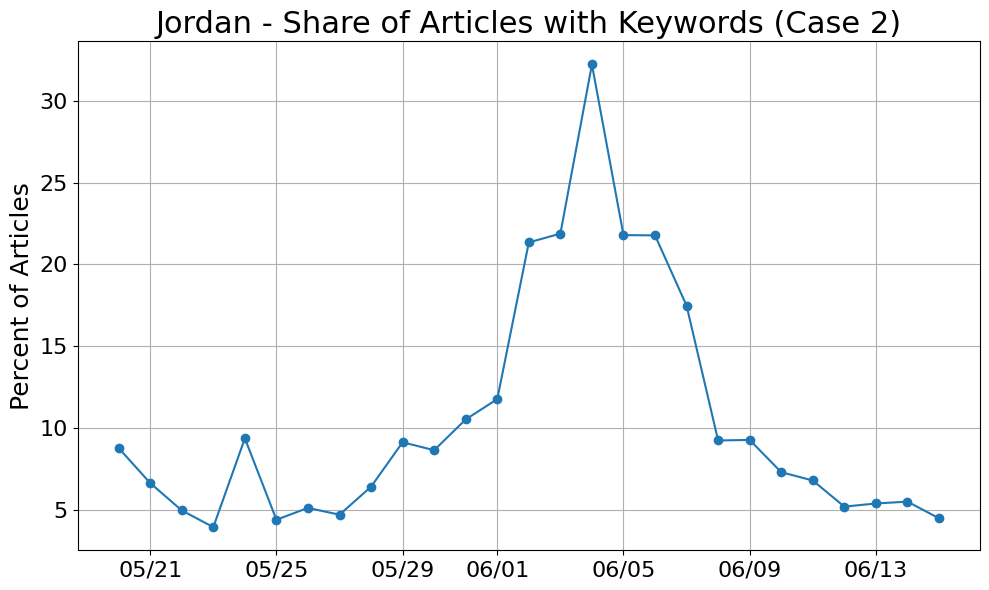

In [280]:
title = f"{country} - Share of Articles with Keywords (Case {case_id})"
plot_filename = f"{country.lower()}_2018_daily_articles_case{case_id}.png"
plot_df(df = df_total, column = "share", title=title, path=plot_path_ssp, filename=plot_filename)

Compare with Factiva

In [281]:
plot_path_ssp = plot_path+"event-studies/jordanian-protest-2018/"
factiva = pd.read_csv(data_path_newsapi_daily_ssp + 'factiva.csv')

factiva["share"] = factiva["keywords"] / factiva["total"] * 100
factiva["date"] = pd.to_datetime(factiva["date"])

/tmp/ipykernel_105926/2284639877.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  factiva["date"] = pd.to_datetime(factiva["date"])


In [283]:
df_total

,date,count_total,country,count_case,share
0,2018-05-20,194,Jordan,17,8.762887
1,2018-05-21,302,Jordan,20,6.622517
2,2018-05-22,384,Jordan,19,4.947917
3,2018-05-23,382,Jordan,15,3.926702
4,2018-05-24,342,Jordan,32,9.356725
5,2018-05-25,274,Jordan,12,4.379562
6,2018-05-26,196,Jordan,10,5.102041
7,2018-05-27,128,Jordan,6,4.687500
8,2018-05-28,250,Jordan,16,6.400000
9,2018-05-29,351,Jordan,32,9.116809


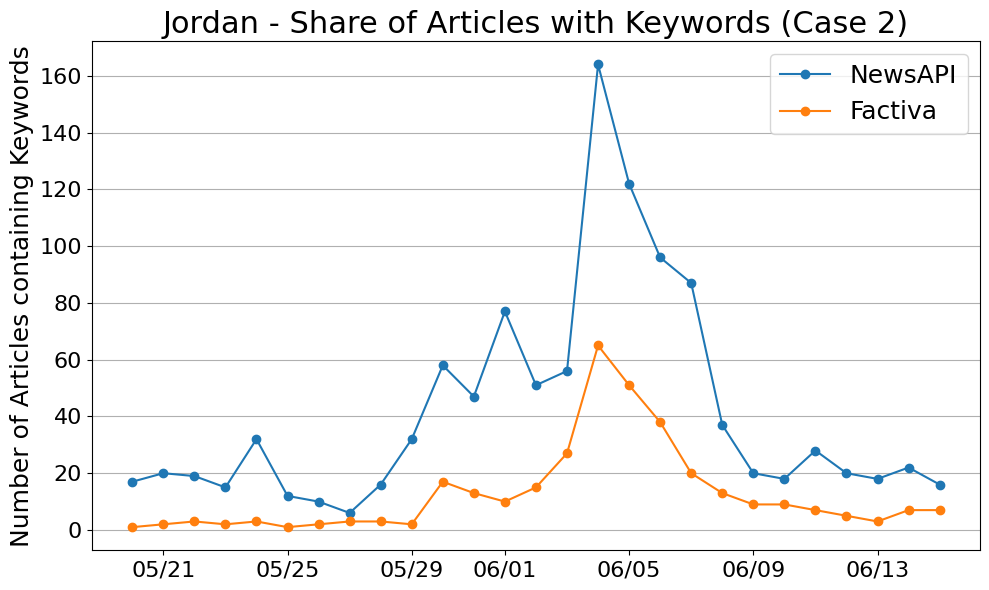

In [284]:
# Plotting
fig, ax = plt.subplots(figsize=(10, 6))  # Set the figure size
ax.plot(df_total["date"], df_total["count_case"], marker='o', linestyle='-', label="NewsAPI")

ax.plot(factiva["date"], factiva["keywords"], marker='o', linestyle='-', label="Factiva")

# Adding title and labels
ax.set_title(f'{title}', fontsize=22)
ax.set_ylabel('Number of Articles containing Keywords', fontsize=18)

# Adding grid
ax.grid(axis='y')

# Formatting the y-axis ticks with commas
def format_with_commas(x, pos):
    return '{:,}'.format(int(x))

ax.yaxis.set_major_formatter(ticker.FuncFormatter(format_with_commas))

# Adjusting the font size of the axis ticks
ax.tick_params(axis='both', which='major', labelsize=16)

# Formatting the x-axis to show only month and day
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))

# Adding a tight layout
plt.tight_layout()
plt.legend(fontsize=18)
# Saving the plot

plot_filename = f"{country.lower()}_2018_daily_articles_case{case_id}_vs_factiva_count.png"
plt.savefig(plot_path_ssp + plot_filename)

plt.show()

### 5.3 2022 cholera outbreak in Lebanon

Case 1: Concepts - "cholera", "diarrhea", "vomiting", "dehydration", "clean water",  "vaccine"

Case 2: Keywords - "cholera", "diarrhea", "vomiting", "dehydration", "clean water",  "vaccine"


Start date: October 2022

Info: https://en.wikipedia.org/wiki/2022_cholera_outbreak_in_Lebanon

In [1]:
data_path_newsapi_daily_ssp = data_path_newsapi_daily + "libanon-cholera-2022/"

NameError: name 'data_path_newsapi_daily' is not defined

#### 5.3.1 Query

In [478]:
country = mashreq_countries[2]
country_uri = er.getLocationUri(country)
print(f"Country URI: {country_uri}")

year = 2022
year_string = str(year)
print(f"Year: {year_string}")

Country URI: http://en.wikipedia.org/wiki/Lebanon
Year: 2022


In [479]:
keywords_case_1 = ["cholera", "diarrhea", "vomiting", "dehydration", "clean water",  "vaccine"]

keywords = keywords_case_1
keywords_df = pd.DataFrame({"keyword": keywords, "conceptUri": [er.getConceptUri(keyword) for keyword in keywords]})

In [480]:
keywords_df.loc[keywords_df["keyword"] == "clean water", "conceptUri"] = "https://en.wikipedia.org/wiki/Water_pollution"
keywords_df

,keyword,conceptUri
0,cholera,http://en.wikipedia.org/wiki/Cholera
1,diarrhea,http://en.wikipedia.org/wiki/Diarrhea
2,vomiting,http://en.wikipedia.org/wiki/Vomiting
3,dehydration,http://en.wikipedia.org/wiki/Dehydration
4,clean water,https://en.wikipedia.org/wiki/Water_pollution
5,vaccine,http://en.wikipedia.org/wiki/Vaccine


In [481]:
query = return_query_string(keywords_df, country_uri, year_string, language, concept=False)

In [482]:
# execute_query
q = QueryArticlesIter.initWithComplexQuery(query)
# Set requested result to get the source aggregation
q.setRequestedResult(RequestArticlesTimeAggr())
res = er.execQuery(q)

totalResults = res['timeAggr']["totalResults"]
usedResults = res['timeAggr']['usedResults']

print(f"totalResults == usedResults: {totalResults==usedResults}")

if usedResults == 0:
    print(f"No results, something went wrong")

df = pd.DataFrame(res['timeAggr']['results'])

totalResults == usedResults: True


In [483]:
def extract_digit(input_string):
    match = re.search(r'\d', input_string)
    return int(match.group()) if match else None

try:
    highest_case = sorted(os.listdir(data_path_newsapi_daily_ssp))[-1]
    case_id = extract_digit(highest_case) + 1
except:  
    case_id = 1
print(f"Case ID: {case_id}")

os.mkdir(data_path_newsapi_daily_ssp + f"case_{case_id}")
print(f"Directory created: {data_path_newsapi_daily_ssp}case_{case_id}")

Case ID: 2
Directory created: ../../data/newsapi/articles-daily/libanon-cholera-2022/case_2


In [484]:
# Load the query results from the csv file
file_name = f"{country.lower()}_{year}_daily_articles_case{case_id}.csv"
df.to_csv(f"{data_path_newsapi_daily_ssp}case_{case_id}/{file_name}", index=False)

# Save the query specification
file_path = f"{data_path_newsapi_daily_ssp}case_{case_id}/query.txt"
# Open the file in write mode and write the string to it
with open(file_path, 'w') as file:
    file.write(query)

#### 5.3.2 Create plot

- Case 1: Concepts - "cholera", "diarrhea", "vomiting", "dehydration", "clean water",  "vaccine"
- Case 2: Keywords - "cholera", "diarrhea", "vomiting", "dehydration", "clean water",  "vaccine"

In [250]:
plot_path_ssp = plot_path+"event-studies/libanon-cholera-2022/"
year = 2022

In [251]:
country = "Lebanon"
case_id = 2

In [252]:
# Load the query results from the csv file
file_name = f"{country.lower()}_{year}_daily_articles_case{case_id}.csv"
df = pd.read_csv(f"{data_path_newsapi_daily_ssp}case_{case_id}/{file_name}")
df["date"] = pd.to_datetime(df["date"])

# Load the count for the entire country without keywords
df_total = pd.read_csv(data_path_newsapi_daily + "lebanon_2014_2024_daily_articles.csv")
df_total["date"] = pd.to_datetime(df_total["date"])

In [253]:
# Define the cutoff date
cutoff_date_start = pd.to_datetime(f'{year}-08-01')
cutoff_date_end = pd.to_datetime(f'{year}-12-31')

# Filter the DataFrame
df = df[(df['date'] >= cutoff_date_start) & (df['date'] <= cutoff_date_end)]
df_total = df_total[(df_total['date'] >= cutoff_date_start) & (df_total['date'] <= cutoff_date_end)]

In [254]:
df_total = df_total.merge(df, on = "date", how = "inner", suffixes=('_total', '_case'))
df_total["share"] = df_total["count_case"] / df_total["count_total"] * 100

In [255]:
# Convert 'date' column to datetime
df_total['date'] = pd.to_datetime(df_total['date'])

# Set the 'date' column as the index
df_total.set_index('date', inplace=True)

# Resample by week and aggregate
weekly_df = df_total.resample('W').agg({
    'count_total': 'sum',
    'country': 'first',  # Assuming the country remains the same
    'count_case': 'sum',
    'share': 'mean'
})

weekly_df.reset_index(inplace=True)
df_total.reset_index(inplace=True)

if df_total.loc[(df_total["date"] <= weekly_df["date"].values[0]),].shape[0] != 7:
    weekly_df = weekly_df[1:]
    
if df_total.loc[(df_total["date"] > weekly_df["date"].values[-2]),].shape[0] != 7:
    weekly_df = weekly_df[:-2]

In [256]:
df_total.loc[(df_total["date"] <= weekly_df["date"].values[0]),]

,date,count_total,country,count_case,share
0,2022-08-01,783,Lebanon,6,0.766284
1,2022-08-02,528,Lebanon,3,0.568182
2,2022-08-03,758,Lebanon,10,1.319261
3,2022-08-04,573,Lebanon,21,3.664921
4,2022-08-05,427,Lebanon,10,2.341920
5,2022-08-06,245,Lebanon,1,0.408163
6,2022-08-07,262,Lebanon,2,0.763359


In [257]:
weekly_df

,date,count_total,country,count_case,share
0,2022-08-07,3576,Lebanon,53,1.404584
1,2022-08-14,1859,Lebanon,24,1.319631
2,2022-08-21,1536,Lebanon,25,1.868450
3,2022-08-28,1582,Lebanon,22,1.414976
4,2022-09-04,1175,Lebanon,14,1.158862
5,2022-09-11,1163,Lebanon,25,2.136606
6,2022-09-18,1884,Lebanon,35,1.867145
7,2022-09-25,1944,Lebanon,28,1.417285
8,2022-10-02,1302,Lebanon,16,1.182369
9,2022-10-09,1754,Lebanon,65,3.950827


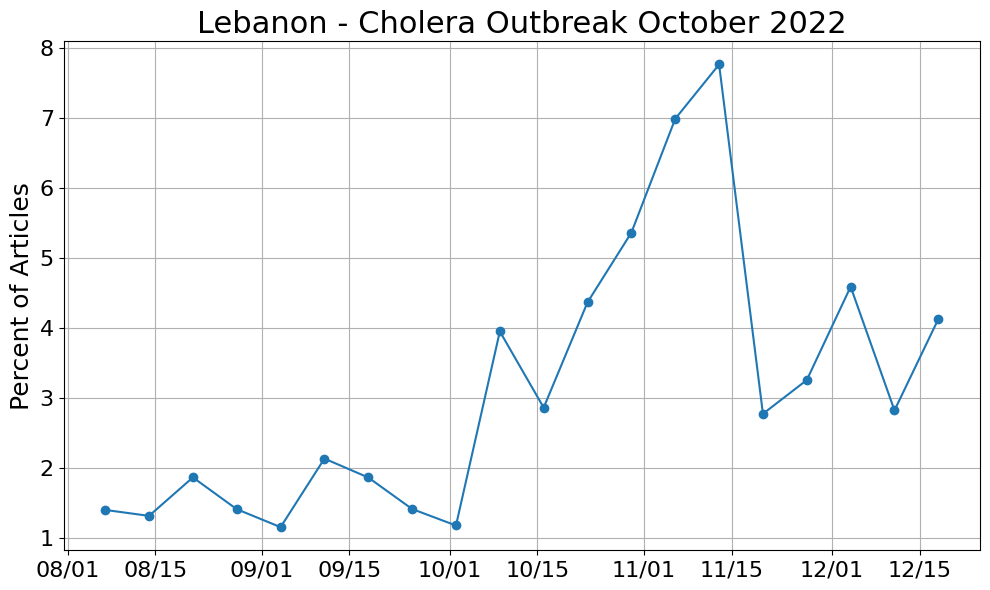

In [258]:
title = f"{country} - Cholera Outbreak October 2022"
plot_filename = f"{country.lower()}_{year}_daily_articles_case{case_id}.png"
plot_df(df = weekly_df, column = "share", title=title, path=plot_path_ssp, filename=plot_filename)

Compare to Factiva

In [261]:
factiva = pd.read_csv(data_path_newsapi_daily_ssp + 'factiva_case2.csv')

factiva["share"] = factiva["keywords"] / factiva["total"] * 100


In [263]:
factiva["date"] = factiva["to"]

In [268]:
factiva["date"] = pd.to_datetime(factiva["date"])

/tmp/ipykernel_105926/542733000.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  factiva["date"] = pd.to_datetime(factiva["date"])


In [272]:
factiva

,from,to,total,keywords,share,date
0,08/01/22,08/07/22,1196,51,4.264214,2022-08-07
1,08/08/22,08/14/22,850,33,3.882353,2022-08-14
2,08/15/22,08/21/22,655,33,5.038168,2022-08-21
3,08/22/22,08/28/22,672,34,5.059524,2022-08-28
4,08/29/22,09/04/22,675,3,0.444444,2022-09-04
5,09/05/22,09/11/22,707,13,1.838755,2022-09-11
6,09/12/22,09/18/22,909,5,0.550055,2022-09-18
7,09/19/22,09/25/22,1083,4,0.369344,2022-09-25
8,09/26/22,10/02/22,901,6,0.665927,2022-10-02
9,10/03/22,10/09/22,935,35,3.743316,2022-10-09


In [269]:
weekly_df["count_case"]

,date,count_total,country,count_case,share
0,2022-08-07,3576,Lebanon,53,1.404584
1,2022-08-14,1859,Lebanon,24,1.319631
2,2022-08-21,1536,Lebanon,25,1.868450
3,2022-08-28,1582,Lebanon,22,1.414976
4,2022-09-04,1175,Lebanon,14,1.158862
5,2022-09-11,1163,Lebanon,25,2.136606
6,2022-09-18,1884,Lebanon,35,1.867145
7,2022-09-25,1944,Lebanon,28,1.417285
8,2022-10-02,1302,Lebanon,16,1.182369
9,2022-10-09,1754,Lebanon,65,3.950827


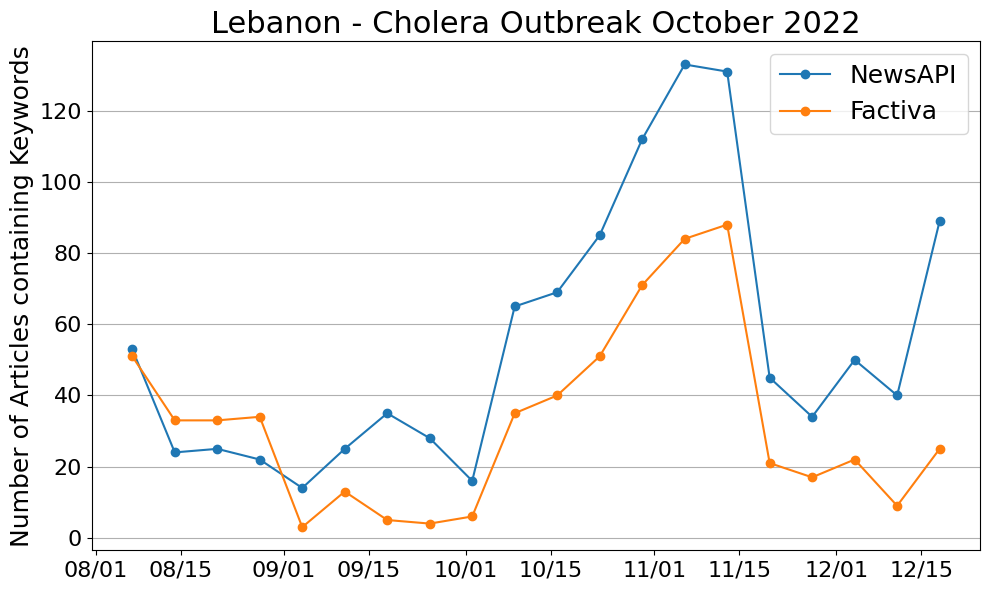

In [274]:
# Plotting
fig, ax = plt.subplots(figsize=(10, 6))  # Set the figure size
ax.plot(weekly_df["date"], weekly_df["count_case"], marker='o', linestyle='-', label="NewsAPI")

ax.plot(factiva["date"], factiva["keywords"], marker='o', linestyle='-', label="Factiva")

# Adding title and labels
ax.set_title(f'{title}', fontsize=22)
ax.set_ylabel('Number of Articles containing Keywords', fontsize=18)

# Adding grid
ax.grid(axis='y')

# Formatting the y-axis ticks with commas
def format_with_commas(x, pos):
    return '{:,}'.format(int(x))

ax.yaxis.set_major_formatter(ticker.FuncFormatter(format_with_commas))

# Adjusting the font size of the axis ticks
ax.tick_params(axis='both', which='major', labelsize=16)

# Formatting the x-axis to show only month and day
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))

# Adding a tight layout
plt.tight_layout()
plt.legend(fontsize=18)
# Saving the plot

plot_filename = f"{country.lower()}_2022_daily_articles_case{case_id}_vs_factiva_count.png"
plt.savefig(plot_path_ssp + plot_filename)

plt.show()

### 5.4 2024 flood in Iraq

- Case 1: Concepts - "rain", "water", "flood", "weather", "river"
- Case 2: Keywords - "rain", "water", "flood", "weather", "river"


Start date: 03/19/2024

Info: https://go.ifrc.org/field-reports/16954

#### 5.4.1 Query

In [492]:
data_path_newsapi_daily_ssp = data_path_newsapi_daily + "iraq-floods-2024/"

In [493]:
country = mashreq_countries[0]
country_uri = er.getLocationUri(country)
print(f"Country URI: {country_uri}")

year = 2024
year_string = str(year)
print(f"Year: {year_string}")

Country URI: http://en.wikipedia.org/wiki/Iraq
Year: 2024


In [494]:
keywords_case_1 = ["rain", "water", "flood", "weather", "river"]

keywords = keywords_case_1
keywords_df = pd.DataFrame({"keyword": keywords, "conceptUri": [er.getConceptUri(keyword) for keyword in keywords]})

In [496]:
query = return_query_string(keywords_df, country_uri, year_string, language, concept=True)

In [497]:
# execute_query
q = QueryArticlesIter.initWithComplexQuery(query)
# Set requested result to get the source aggregation
q.setRequestedResult(RequestArticlesTimeAggr())
res = er.execQuery(q)

totalResults = res['timeAggr']["totalResults"]
usedResults = res['timeAggr']['usedResults']

print(f"totalResults == usedResults: {totalResults==usedResults}")

if usedResults == 0:
    print(f"No results, something went wrong")

df = pd.DataFrame(res['timeAggr']['results'])

totalResults == usedResults: True


In [498]:
def extract_digit(input_string):
    match = re.search(r'\d', input_string)
    return int(match.group()) if match else None

try:
    highest_case = sorted(os.listdir(data_path_newsapi_daily_ssp))[-1]
    case_id = extract_digit(highest_case) + 1
except:  
    case_id = 1
print(f"Case ID: {case_id}")

os.mkdir(data_path_newsapi_daily_ssp + f"case_{case_id}")
print(f"Directory created: {data_path_newsapi_daily_ssp}case_{case_id}")

Case ID: 1
Directory created: ../../data/newsapi/articles-daily/iraq-floods-2024/case_1


In [499]:
# Load the query results from the csv file
file_name = f"{country.lower()}_{year}_daily_articles_case{case_id}.csv"
df.to_csv(f"{data_path_newsapi_daily_ssp}case_{case_id}/{file_name}", index=False)

# Save the query specification
file_path = f"{data_path_newsapi_daily_ssp}case_{case_id}/query.txt"
# Open the file in write mode and write the string to it
with open(file_path, 'w') as file:
    file.write(query)

#### 5.4.2 Create plot

- Case 1: Concepts - "rain", "water", "flood", "weather", "river"
- Case 2: Keywords - "rain", "water", "flood", "weather", "river"

In [ ]:
plot_path_ssp = plot_path+"event-studies/iraq-floods-2024/"

In [500]:
country = "Iraq"
case_id = 1

In [506]:
# Load the query results from the csv file
file_name = f"{country.lower()}_{year}_daily_articles_case{case_id}.csv"
df = pd.read_csv(f"{data_path_newsapi_daily_ssp}case_{case_id}/{file_name}")
df["date"] = pd.to_datetime(df["date"])

# Load the count for the entire country without keywords
df_total = pd.read_csv(data_path_newsapi_daily + "iraq_2014_2024_daily_articles.csv")
df_total["date"] = pd.to_datetime(df_total["date"])

In [507]:
# Define the cutoff date
cutoff_date_start = pd.to_datetime('2024-02-01')
cutoff_date_end = pd.to_datetime('2024-05-30')

# Filter the DataFrame
df = df[(df['date'] >= cutoff_date_start) & (df['date'] <= cutoff_date_end)]
df_total = df_total[(df_total['date'] >= cutoff_date_start) & (df_total['date'] <= cutoff_date_end)]

In [508]:
df_total = df_total.merge(df, on = "date", how = "inner", suffixes=('_total', '_case'))
df_total["share"] = df_total["count_case"] / df_total["count_total"] * 100

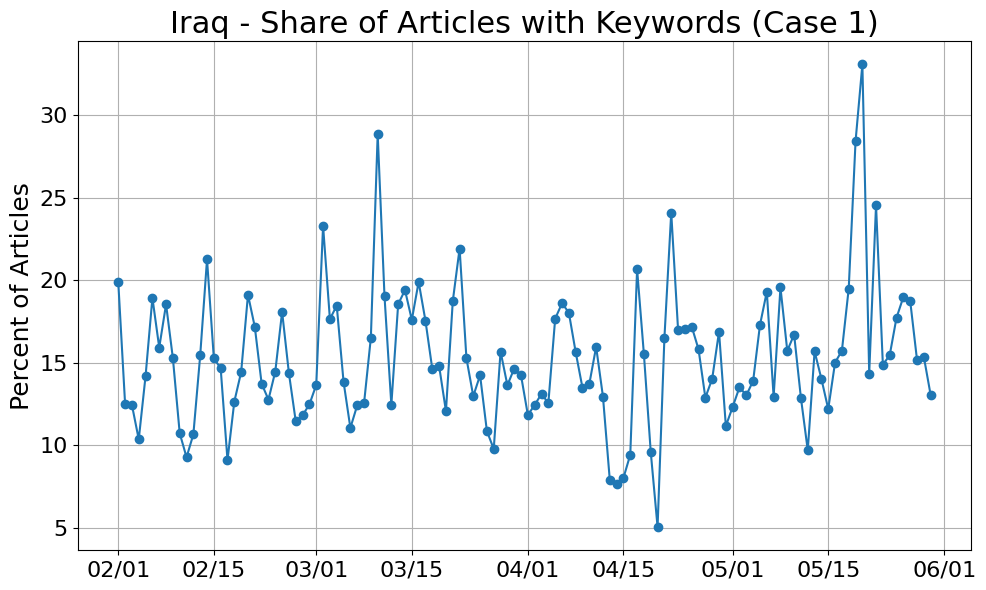

In [509]:
title = f"{country} - Share of Articles with Keywords (Case {case_id})"
plot_filename = f"{country.lower()}_{year}_daily_articles_case{case_id}.png"
plot_df(df = df_total, column = "share", title=title, path=plot_path_ssp, filename=plot_filename)

## 6. Download data

### 6.1 Get the article count

In [9]:
News_API_key_dominik = '7ce3fa46-3bab-4460-a552-e3046d565492'
News_API_key_dominik_wb = '34b2eba6-04d7-4ad0-9aad-06a4bb50fae6'
News_API_key_philipp = '9200e557-062b-411a-8b58-0592c0fac183'
News_API_key = News_API_key_dominik_wb
er = EventRegistry(apiKey = News_API_key)

In [10]:
language = "eng"
#language = "ara"

,country,concept_uri,location_uri,country_ara
0,Iraq,http://en.wikipedia.org/wiki/Iraq,http://en.wikipedia.org/wiki/Iraq,العراق
1,Jordan,http://en.wikipedia.org/wiki/Jordan,http://en.wikipedia.org/wiki/Jordan,الأردن
2,Lebanon,http://en.wikipedia.org/wiki/Lebanon,http://en.wikipedia.org/wiki/Lebanon,لبنان
3,Palestine,https://en.wikipedia.org/wiki/State_of_Palestine,https://en.wikipedia.org/wiki/State_of_Palestine,فلسطين
4,Syria,http://en.wikipedia.org/wiki/Syria,http://en.wikipedia.org/wiki/Syria,سوريا


In [152]:
# Template string for the middle part
concept_location_template = """{{
                            "conceptUri": "{0}"
                        }},
                        {{
                            "locationUri": "{0}"
                        }}
                        """
concept_template = """{{
                                    "conceptUri": "{0}"
                                    }}
                            """
                            
location_template = """{{
                                    "locationUri": "{0}"
                                    }}
                                """
                                
keyword_template = """{{
                        "keyword": "{0}",
                        "keywordLoc": "body"
                        }},
                        {{
                        "keyword": "{0}",
                        "keywordLoc": "title"
                        }}
                        """

In [189]:
# Construct the repeated middle part
countries_keywords = ",\n                        ".join([keyword_template.format((country)) for country in mashreq_countries_df["country_ara"].values])
countries_uri = ",\n                        ".join([concept_location_template.format((country)) for country in mashreq_countries_df["concept_uri"].values])

In [190]:
years = list(range(2024,2013,-1))
start_date = '2024-06-23'
end_date = '2024-07-24'
year=2024

In [194]:
print(f"Mashreq countries, from: {start_date} to {end_date}, Language: {language}")

query = f"""{{
        "$query": {{
            "$and": [
                        {{
                    "$or": [
                                {countries_uri}
                            ,
                                {countries_keywords}
                            ]
            }},  
            {{
                "dateStart": "{year}-06-23",
                "dateEnd": "{year}-07-24",
                "lang": "{language}"
            }}
            ]
        }},
        "$filter": {{
            "isDuplicate": "skipDuplicates"
        }}
        }}"""
q = QueryArticlesIter.initWithComplexQuery(query)

# Set requested result to get the source aggregation
q.setRequestedResult(RequestArticlesTimeAggr())
res = er.execQuery(q)

totalResults = res['timeAggr']["totalResults"]
usedResults = res['timeAggr']['usedResults']

if totalResults!=usedResults:
    print(f"totalResults != usedResults: {totalResults!=usedResults}")

if usedResults == 0:
    print(f"No results, something went wrong")

df = pd.DataFrame(res['timeAggr']['results'])
df["location"] = "Mashreq"

Mashreq countries, from: 2024-06-23 to 2024-07-24, Language: ara


In [195]:
download_path = data_path_newsapi + f"downloads/{language}/"
file_name = f"Mashreq_{start_date}_{end_date}_daily_article_count_{language}.csv"
df.to_csv(download_path + file_name, index = False)

In [198]:
os.listdir(download_path)

['Mashreq_2024-06-23_2024-07-24_daily_article_count_ara.csv']

In [196]:
df["count"].sum()

np.int64(85513)

### 6.2 Download articles

In [200]:
download_path = data_path_newsapi + f"downloads/{language}/"

In [174]:
85991/100

859.91

In [201]:
query = f"""{{
        "$query": {{
            "$and": [
                        {{
                    "$or": [
                                {countries_uri}
                            ,
                                {countries_keywords}
                            ]
            }},  
            {{
                "dateStart": "{year}-06-23",
                "dateEnd": "{year}-07-24",
                "lang": "{language}"
            }}
            ]
        }},
        "$filter": {{
            "isDuplicate": "skipDuplicates"
        }}
        }}"""

In [202]:
q = QueryArticlesIter.initWithComplexQuery(query)
res = q.execQuery(er, maxItems=1000000)
article_list = [article for article in res]
mashreq_query = pd.DataFrame(article_list)

In [203]:
file_name = f"Mashreq_{start_date}_{end_date}_daily_article_{language}.csv"
mashreq_query.to_csv(download_path + file_name, index = False)

In [204]:
mashreq_query

,uri,lang,isDuplicate,date,time,dateTime,dateTimePub,dataType,sim,url,title,body,source,authors,image,eventUri,sentiment,wgt,relevance
0,8221345226,ara,False,2024-07-12,00:55:33,2024-07-12T00:55:33Z,2024-07-12T00:55:00Z,news,0.615686,https://www.almanar.com.lb/12211949,الصحافة اليوم: 12-7-2024,‫‫ محمد الهندي: من يرى فيديوهات المقاومين يجب ...,"{'uri': 'almanar.com.lb', 'dataType': 'news', ...",[],https://www.almanar.com.lb/framework/includes/...,ara-1673095,None,533,533
1,8202585568,ara,False,2024-06-30,10:00:50,2024-06-30T10:00:50Z,2024-06-30T10:00:18Z,news,0.000000,https://www.enabbaladi.net/706124/انفجار-جنوبي...,انفجار جنوبي لبنان.. الأسد حاضر دون أدوات,حسام المحمود | يامن المغربي | حسن إبراهيم\n\nأ...,"{'uri': 'enabbaladi.net', 'dataType': 'news', ...",[],https://cdn.enabbaladi.net/arabic/wp-content/u...,None,None,516,516
2,8203455578,ara,False,2024-07-01,02:22:38,2024-07-01T02:22:38Z,2024-07-01T02:22:23Z,news,0.000000,https://www.almanar.com.lb/12164385,الصحافة اليوم: 1-7-2024,‫‫الحزب الديمقراطي اللبناني في ذكرى تأسيسه الـ...,"{'uri': 'almanar.com.lb', 'dataType': 'news', ...",[],https://www.almanar.com.lb/framework/includes/...,None,None,458,458
3,8201361178,ara,False,2024-06-29,10:09:34,2024-06-29T10:09:34Z,2024-06-29T10:09:15Z,news,0.000000,https://www.shorouknews.com/news/view.aspx?cda...,الكاتب الفلسطيني ربعي المدهون في حوار مطوّل: ا...,الفارق بين حرب غزة والهولوكوست هو أن الحرب تُب...,"{'uri': 'shorouknews.com', 'dataType': 'news',...",[],https://www.shorouknews.com/uploadedimages/Gal...,None,None,455,455
4,8201914853,ara,False,2024-06-29,19:34:06,2024-06-29T19:34:06Z,2024-06-29T19:33:54Z,news,0.000000,https://www.maghress.com/lakome/348309,"""طوفان الأقصى"": الحاجة إلى الحرب.. مرحلة ما بع...","""إذا أراد الله أحداثا عظيمة هيأ أسبابها، تخطئ ...","{'uri': 'maghress.com', 'dataType': 'news', 't...",[],https://images2.maghress.com/lakome/lakome,None,None,452,452
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85506,8190800198,ara,False,2024-06-23,00:50:53,2024-06-23T00:50:53Z,2024-06-23T00:49:57Z,news,0.000000,https://www.arabstoday.net/w-2737/002658-%D8%A...,الإعلام الجديد... جنود لم نرها,أتفق مع القول بأنَّ الرأي العام العالمي تغير ل...,"{'uri': 'arabstoday.net', 'dataType': 'news', ...",[],https://img.arabstoday.net//SusanShaer.jpg,None,None,1,1
85507,8190795913,ara,False,2024-06-23,00:44:04,2024-06-23T00:44:04Z,2024-06-23T00:42:22Z,news,0.905882,https://www.almamlakatv.com//news/145045,أجواء صيفية في معظم المناطق اليوم,منظر عام لمبانٍ في مدينة عمّان ويظهر معها علم ...,"{'uri': 'almamlakatv.com', 'dataType': 'news',...",[],https://www.almamlakatv.com//images/articles/b...,ara-1665868,None,1,1
85508,8190781913,ara,False,2024-06-23,00:18:10,2024-06-23T00:18:10Z,2024-06-23T00:17:13Z,news,0.000000,https://www.albawabhnews.com/5025005,فلسطين.. استشهاد طفلين بقصف إسرائيلي على مخيم ...,تابع أحدث الأخبار عبر تطبيق\n\nأفادت قناة القا...,"{'uri': 'albawabhnews.com', 'dataType': 'news'...","[{'uri': 'عبد_الله_جمال@albawabhnews.com', 'na...",https://www.albawabhnews.com/UploadCache/libfi...,None,None,1,1
85509,8190775962,ara,False,2024-06-23,00:08:37,2024-06-23T00:08:37Z,2024-06-23T00:06:34Z,news,0.000000,https://www.alaraby.co.uk/opinion/%D8%A7%D9%84...,السُّودان: دبلوماسية الصمت خيرٌ من الانفعال,ضاعفتِ المواجهات العسكرية، وقتل المدنيين بصورة...,"{'uri': 'alaraby.co.uk', 'dataType': 'news', '...",[],https://www.alaraby.co.uk/sites/default/files/...,None,None,1,1
